In [ ]:
from google.colab import drive
import os
import datetime

MOUNTPOINT = '/content/drive'

drive.mount(MOUNTPOINT, force_remount=True)

# Fail early if Google Drive did not actually mount
DRIVE_ROOT = os.path.join(MOUNTPOINT, 'MyDrive')
if not os.path.isdir(DRIVE_ROOT):
    raise RuntimeError(
        f"Google Drive is not mounted correctly at {DRIVE_ROOT}"
    )

BASE = os.path.join(DRIVE_ROOT, 'PCM_Study')

for sub in [
    'data/raw',
    'data/clean',
    'data/processed',
    'tables',
    'figures',
    'models',
    'predictions',
    'logs',
    'backup'
]:
    os.makedirs(os.path.join(BASE, sub), exist_ok=True)

RNG = 42

def plog(cell, note):
    os.makedirs(os.path.join(BASE, 'logs'), exist_ok=True)
    with open(
        os.path.join(BASE, 'logs', 'pipeline_log.txt'),
        'a',
        encoding='utf-8'
    ) as f:
        f.write(
            f"{datetime.datetime.now().isoformat()} | "
            f"{cell} | {note}\n"
        )

plog('CELL 1', 'setup complete')

print('Setup OK — BASE:', BASE)
print(
    'Folders ready:',
    'data/raw, data/clean, data/processed, tables, models, '
    'predictions, figures, logs, backup'
)

Mounted at /content/drive
Setup OK — BASE: /content/drive/MyDrive/PCM_Study
Folders ready: data/raw, data/clean, data/processed, tables, models, predictions, figures, logs, backup


In [ ]:
# ============================================================
# CELL 2+3 — UPLOAD + SAVE + INSPECT THE 8 CITY CSVs
# ============================================================

import os
import glob
import pandas as pd
from google.colab import files

# ------------------------------------------------------------
# 1. Set raw-data folder
# ------------------------------------------------------------
RAW = BASE + '/data/raw'
os.makedirs(RAW, exist_ok=True)

# ------------------------------------------------------------
# 2. Upload CSV files
# ------------------------------------------------------------
print('Select your 8 CSV files:')
uploaded = files.upload()

saved_files = []

for name, content in uploaded.items():

    if not name.lower().endswith('.csv'):
        print(f'SKIPPED (not CSV): {name}')
        continue

    out_path = os.path.join(RAW, name)

    with open(out_path, 'wb') as fh:
        fh.write(content)

    saved_files.append(out_path)
    print(f'Saved: {name} -> {out_path}')

print(f'\nSaved {len(saved_files)} CSV file(s).')

# ------------------------------------------------------------
# 3. Expected columns
# ------------------------------------------------------------
INPUTS = [
    'PCM_type_Wall',
    'Thickness_Wall',
    'Melting_Point_Wall',
    'wall_PCM_Position',
    'PCM_type_Roof',
    'Thickness_Roof',
    'Melting_Point_Roof',
    'Roof_PCM_Position'
]

TARGETS = ['EUI', 'IDD', 'TL']

# ------------------------------------------------------------
# 4. Find CSV files
# ------------------------------------------------------------
files_found = sorted(
    glob.glob(os.path.join(RAW, '**', '*.csv'), recursive=True)
)

print('\n' + '=' * 78)
print(f'Found {len(files_found)} CSV file(s)')
print('=' * 78)

# ------------------------------------------------------------
# 5. Inspect CSV files
# ------------------------------------------------------------
for f in files_found:

    print('\n' + '=' * 78)
    print('FILE:', os.path.basename(f))
    print('=' * 78)

    try:
        df = pd.read_csv(f)
    except UnicodeDecodeError:
        df = pd.read_csv(f, encoding='utf-8-sig')

    # Clean column names
    df.columns = [
        c.strip().split('.')[-1].strip()
        for c in df.columns
    ]

    # Check required columns
    missing = [
        c for c in INPUTS + TARGETS
        if c not in df.columns
    ]

    if missing:
        print('!! MISSING COLUMNS:', missing)
        continue

    print(f'shape: {df.shape[0]} rows x {df.shape[1]} cols')

    print('\nunique values per input column:')

    for c in INPUTS:
        values = sorted(
            df[c].dropna().unique().tolist(),
            key=lambda x: str(x)
        )

        print(
            f'  {c:22s} '
            f'n={df[c].nunique():3d} -> {values}'
        )

    print('\ntarget stats (min / mean / max / std):')

    for c in TARGETS:
        s = pd.to_numeric(df[c], errors='coerce')

        print(
            f'  {c:8s} '
            f'min={s.min():10.3f}  '
            f'mean={s.mean():10.3f}  '
            f'max={s.max():10.3f}  '
            f'std={s.std():10.3f}'
        )

    missing_total = int(df.isna().sum().sum())

    dup = int(
        df.duplicated(
            subset=INPUTS + TARGETS
        ).sum()
    )

    eui = pd.to_numeric(df['EUI'], errors='coerce')
    idd = pd.to_numeric(df['IDD'], errors='coerce')
    tl = pd.to_numeric(df['TL'], errors='coerce')

    wire = int(
        ((idd - eui).abs() < 1e-6).sum()
    )

    imp = int(
        ((tl > 24) | (idd < 0.5)).sum()
    )

    print('\nmissing values:', missing_total)

    print(
        f'health: '
        f'duplicate log rows={dup} | '
        f'IDD==EUI rows={wire} | '
        f'impossible rows={imp}'
    )

# ------------------------------------------------------------
# 6. Finish
# ------------------------------------------------------------
plog(
    'CELL 2+3',
    f'uploaded and inspected {len(files_found)} CSV files'
)

print('\n' + '=' * 78)
print('DONE — upload + inspection completed.')
print('=' * 78)

Select your 8 CSV files:


Saving LHS_Ardebial .csv to LHS_Ardebial  (1).csv
Saving LHS_Bandarabbas.csv to LHS_Bandarabbas (1).csv
Saving LHS_Bushhr .csv to LHS_Bushhr  (1).csv
Saving LHS_Hamedan.csv to LHS_Hamedan (1).csv
Saving LHS_Kashan .csv to LHS_Kashan  (1).csv
Saving LHS_rasht.csv to LHS_rasht (1).csv
Saving LHS_tabriz.csv to LHS_tabriz (1).csv
Saving LHS_Tehran.csv to LHS_Tehran (1).csv
Saved: LHS_Ardebial  (1).csv -> /content/drive/MyDrive/PCM_Study/data/raw/LHS_Ardebial  (1).csv
Saved: LHS_Bandarabbas (1).csv -> /content/drive/MyDrive/PCM_Study/data/raw/LHS_Bandarabbas (1).csv
Saved: LHS_Bushhr  (1).csv -> /content/drive/MyDrive/PCM_Study/data/raw/LHS_Bushhr  (1).csv
Saved: LHS_Hamedan (1).csv -> /content/drive/MyDrive/PCM_Study/data/raw/LHS_Hamedan (1).csv
Saved: LHS_Kashan  (1).csv -> /content/drive/MyDrive/PCM_Study/data/raw/LHS_Kashan  (1).csv
Saved: LHS_rasht (1).csv -> /content/drive/MyDrive/PCM_Study/data/raw/LHS_rasht (1).csv
Saved: LHS_tabriz (1).csv -> /content/drive/MyDrive/PCM_Study/data/r

In [ ]:
# CELL 4 — CLEAN + AUDIT

import os
import glob
import pandas as pd
import datetime

BASE = '/content/drive/MyDrive/PCM_Study'
RAW = BASE + '/data/raw'
CLEAN = BASE + '/data/clean'

os.makedirs(CLEAN, exist_ok=True)

INPUTS = [
    'PCM_type_Wall',
    'Thickness_Wall',
    'Melting_Point_Wall',
    'wall_PCM_Position',
    'PCM_type_Roof',
    'Thickness_Roof',
    'Melting_Point_Roof',
    'Roof_PCM_Position'
]

TARGETS = ['EUI', 'IDD', 'TL']

# ------------------------------------------------------------
# FIND THE 8 CITY FILES
# ------------------------------------------------------------

files = sorted(
    glob.glob(os.path.join(RAW, '*.csv'))
)

print('=' * 75)
print('CELL 4 — CLEANING DATA')
print('=' * 75)

print(f'\nFound {len(files)} CSV files.')

if len(files) != 8:
    raise SystemExit(
        f'\nSTOP: Expected 8 CSV files, but found {len(files)}.\n'
        f'Please check: {RAW}'
    )

for f in files:
    print('  ', os.path.basename(f))

# ------------------------------------------------------------
# READ FILES
# ------------------------------------------------------------

all_dfs = []

for f in files:

    filename = os.path.basename(f)

    try:
        df = pd.read_csv(f)
    except UnicodeDecodeError:
        df = pd.read_csv(f, encoding='utf-8-sig')

    # Clean column names
    df.columns = [
        c.strip().split('.')[-1].strip()
        for c in df.columns
    ]

    # Check columns
    missing = [
        c for c in INPUTS + TARGETS
        if c not in df.columns
    ]

    if missing:
        raise SystemExit(
            f'\nSTOP: {filename} is missing columns:\n{missing}'
        )

    # --------------------------------------------------------
    # CITY NAME FROM FILENAME
    # --------------------------------------------------------

    city = filename

    if city.startswith('LHS_'):
        city = city[4:]

    if city.lower().endswith('.csv'):
        city = city[:-4]

    city = city.replace('(1)', '').strip()

    # Normalize city names
    city_lower = city.lower()

    city_names = {
        'ardebial': 'Ardebial',
        'bandarabbas': 'Bandarabbas',
        'bushhr': 'Bushhr',
        'hamedan': 'Hamedan',
        'kashan': 'Kashan',
        'rasht': 'Rasht',
        'tabriz': 'Tabriz',
        'tehran': 'Tehran'
    }

    city = city_names.get(
        city_lower,
        city.capitalize()
    )

    df['city'] = city

    all_dfs.append(df)

    print(
        f'Read {city:15s}: {len(df):4d} rows'
    )

# ------------------------------------------------------------
# COMBINE ALL CITIES
# ------------------------------------------------------------

full = pd.concat(
    all_dfs,
    ignore_index=True
)

before = len(full)

print('\n' + '=' * 75)
print(f'TOTAL ROWS BEFORE CLEANING: {before}')
print('=' * 75)

# ------------------------------------------------------------
# 1. REMOVE DUPLICATE LOG ROWS
# ------------------------------------------------------------

d1 = full.duplicated(
    subset=INPUTS + TARGETS,
    keep='first'
)

n_dup = int(d1.sum())

print(
    f'\n[1] Duplicate log rows removed: {n_dup}'
)

# ------------------------------------------------------------
# 2. REMOVE IDD == EUI WIRING GLITCH
# ------------------------------------------------------------

eui = pd.to_numeric(
    full['EUI'],
    errors='coerce'
)

idd = pd.to_numeric(
    full['IDD'],
    errors='coerce'
)

tl = pd.to_numeric(
    full['TL'],
    errors='coerce'
)

d2 = (
    (idd - eui).abs() < 1e-6
)

n_wire = int(d2.sum())

print(
    f'[2] IDD == EUI wiring-glitch rows removed: {n_wire}'
)

if n_wire > 0:

    cols = [
        'city',
        'EUI',
        'IDD',
        'TL'
    ]

    if 'time' in full.columns:
        cols.insert(1, 'time')

    print('\nWiring-glitch rows:')
    print(
        full.loc[d2, cols].to_string(index=False)
    )

# ------------------------------------------------------------
# 3. REMOVE IMPOSSIBLE PHYSICS
# ------------------------------------------------------------

d3 = (
    (tl.abs() > 24) |
    (idd < 0.5)
)

n_imp = int(d3.sum())

print(
    f'\n[3] Impossible rows removed '
    f'(|TL| > 24 OR IDD < 0.5): {n_imp}'
)

if n_imp > 0:

    cols = [
        'city',
        'EUI',
        'IDD',
        'TL'
    ]

    if 'time' in full.columns:
        cols.insert(1, 'time')

    print('\nImpossible rows:')
    print(
        full.loc[d3, cols].to_string(index=False)
    )

# ------------------------------------------------------------
# FINAL CLEANING
# ------------------------------------------------------------

remove = d1 | d2 | d3

clean = full.loc[
    ~remove
].copy()

# ------------------------------------------------------------
# PER-CITY COUNTS
# ------------------------------------------------------------

print('\n' + '=' * 75)
print('PER-CITY COUNTS AFTER CLEANING')
print('=' * 75)

for city in sorted(clean['city'].unique()):

    n = int(
        (clean['city'] == city).sum()
    )

    print(
        f'{city:15s}: {n:4d}'
    )

# ------------------------------------------------------------
# TOTAL
# ------------------------------------------------------------

removed = before - len(clean)

print('\n' + '=' * 75)
print('CLEANING SUMMARY')
print('=' * 75)

print(
    f'Rows before cleaning : {before}'
)

print(
    f'Duplicate rows       : {n_dup}'
)

print(
    f'Wiring-glitch rows   : {n_wire}'
)

print(
    f'Impossible rows      : {n_imp}'
)

print(
    f'Total rows removed   : {removed}'
)

print(
    f'Rows after cleaning  : {len(clean)}'
)

# ------------------------------------------------------------
# POST-CLEAN CHECK
# ------------------------------------------------------------

print('\n' + '=' * 75)
print('POST-CLEAN TARGET CHECK')
print('=' * 75)

for city in sorted(clean['city'].unique()):

    g = clean[
        clean['city'] == city
    ]

    print(f'\n{city}  (n={len(g)})')

    print(
        f'  EUI: {g["EUI"].min():.3f} '
        f'-> {g["EUI"].max():.3f}'
    )

    print(
        f'  IDD: {g["IDD"].min():.3f} '
        f'-> {g["IDD"].max():.3f}'
    )

    print(
        f'  TL : {g["TL"].min():.3f} '
        f'-> {g["TL"].max():.3f}'
    )

# ------------------------------------------------------------
# SAVE CLEAN DATASET
# ------------------------------------------------------------

output_file = os.path.join(
    CLEAN,
    'all_cities_CLEANED.csv'
)

clean.to_csv(
    output_file,
    index=False
)

# ------------------------------------------------------------
# SAVE LOG
# ------------------------------------------------------------

os.makedirs(
    BASE + '/logs',
    exist_ok=True
)

log_file = BASE + '/logs/pipeline_log.txt'

with open(log_file, 'a') as f:

    f.write(
        f'{datetime.datetime.now().isoformat()} | '
        f'CELL 4 | '
        f'before={before} | '
        f'duplicates={n_dup} | '
        f'wiring={n_wire} | '
        f'impossible={n_imp} | '
        f'after={len(clean)}\n'
    )

# ------------------------------------------------------------
# FINISHED
# ------------------------------------------------------------

print('\n' + '=' * 75)
print('DONE')
print('=' * 75)

print(
    '\nCleaned file saved to:'
)

print(
    output_file
)

print(
    f'\nFinal dataset: {len(clean)} rows x {len(clean.columns)} columns'
)

CELL 4 — CLEANING DATA

Found 8 CSV files.
   LHS_Ardebial  (1).csv
   LHS_Bandarabbas (1).csv
   LHS_Bushhr  (1).csv
   LHS_Hamedan (1).csv
   LHS_Kashan  (1).csv
   LHS_Tehran (1).csv
   LHS_rasht (1).csv
   LHS_tabriz (1).csv
Read Ardebial       : 1500 rows
Read Bandarabbas    : 1499 rows
Read Bushhr         : 1496 rows
Read Hamedan        : 1500 rows
Read Kashan         : 1500 rows
Read Tehran         : 1500 rows
Read Rasht          : 1499 rows
Read Tabriz         : 1494 rows

TOTAL ROWS BEFORE CLEANING: 11988

[1] Duplicate log rows removed: 8116
[2] IDD == EUI wiring-glitch rows removed: 18

Wiring-glitch rows:
       city              time       EUI       IDD    TL
Bandarabbas 19/09/26 19:20:32 13.580721 13.580721   8.0
Bandarabbas 19/09/26 19:20:32 13.580721 13.580721   8.0
     Bushhr 20/09/26 18:59:07 11.818508 11.818508 -16.0
     Bushhr 20/09/26 18:59:07 11.818508 11.818508 -16.0
      Rasht 20/09/26 10:19:18  4.812702  4.812702  12.0
      Rasht 20/09/26 10:19:19  4.812702

In [ ]:
# ============================================================
# CELL 5 — CANONICAL DATASET
# Creates:
# data/processed/pcm_dataset_final.csv
# Expected: 3,861 rows x 14 columns
# ============================================================

import os
import datetime
import pandas as pd

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

BASE = '/content/drive/MyDrive/PCM_Study'

CLEAN_FILE = BASE + '/data/clean/all_cities_CLEANED.csv'
OUT_DIR = BASE + '/data/processed'
OUT = OUT_DIR + '/pcm_dataset_final.csv'

os.makedirs(OUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# CITY METADATA
# ------------------------------------------------------------

META = {
    'ardebial':    ('08', '5C', 'Ardebil'),
    'bandarabbas': ('01', '0B', 'BandarAbbas'),
    'bushhr':      ('02', '1B', 'Bushehr'),
    'hamedan':     ('07', '4A', 'Hamedan'),
    'kashan':      ('03', '2B', 'Kashan'),
    'rasht':       ('06', '3A', 'Rasht'),
    'tabriz':      ('05', '4B', 'Tabriz'),
    'tehran':      ('04', '3B', 'Tehran'),
}

EXPECTED = {
    'Ardebil': 479,
    'BandarAbbas': 482,
    'Bushehr': 486,
    'Hamedan': 484,
    'Kashan': 489,
    'Rasht': 475,
    'Tabriz': 482,
    'Tehran': 484
}

# ------------------------------------------------------------
# COLUMN RENAMING
# ------------------------------------------------------------

RENAME = {
    'PCM_type_Wall': 'pcm_type_wall',
    'Thickness_Wall': 'thickness_wall_level',
    'Melting_Point_Wall': 'melting_point_wall_level',
    'wall_PCM_Position': 'position_wall',

    'PCM_type_Roof': 'pcm_type_roof',
    'Thickness_Roof': 'thickness_roof_level',
    'Melting_Point_Roof': 'melting_point_roof_level',
    'Roof_PCM_Position': 'position_roof',

    'EUI': 'eui_kwh_m2',
    'IDD': 'idd_deg_h',
    'TL': 'tl_h'
}

COLS = [
    'case_id',
    'city',
    'climate_zone',

    'pcm_type_wall',
    'thickness_wall_level',
    'melting_point_wall_level',
    'position_wall',

    'pcm_type_roof',
    'thickness_roof_level',
    'melting_point_roof_level',
    'position_roof',

    'eui_kwh_m2',
    'idd_deg_h',
    'tl_h'
]

PARAMS8 = [
    'pcm_type_wall',
    'thickness_wall_level',
    'melting_point_wall_level',
    'position_wall',
    'pcm_type_roof',
    'thickness_roof_level',
    'melting_point_roof_level',
    'position_roof'
]

# ------------------------------------------------------------
# CHECK CLEAN FILE
# ------------------------------------------------------------

if not os.path.exists(CLEAN_FILE):
    raise SystemExit(
        f'STOP: Clean file not found:\n{CLEAN_FILE}\n'
        'Run Cell 4 first.'
    )

# ------------------------------------------------------------
# LOAD CLEAN DATA
# ------------------------------------------------------------

clean = pd.read_csv(CLEAN_FILE)

print('=' * 75)
print('CELL 5 — CANONICAL DATASET')
print('=' * 75)

print(
    f'\nLoaded cleaned dataset: '
    f'{clean.shape[0]} rows x {clean.shape[1]} columns'
)

# ------------------------------------------------------------
# CLEAN COLUMN NAMES
# ------------------------------------------------------------

clean.columns = clean.columns.str.strip()

# ------------------------------------------------------------
# RENAME COLUMNS
# ------------------------------------------------------------

clean = clean.rename(columns=RENAME)

# ------------------------------------------------------------
# CREATE NORMALIZED CITY KEY
# ------------------------------------------------------------

clean['city_key'] = (
    clean['city']
    .astype(str)
    .str.replace(r'\.csv$', '', regex=True)
    .str.replace(r'^lhs[_ ]*', '', case=False, regex=True)
    .str.replace(r'\(1\)', '', regex=True)
    .str.strip()
    .str.lower()
)

# ------------------------------------------------------------
# CHECK CITY NAMES
# ------------------------------------------------------------

unknown = set(clean['city_key'].unique()) - set(META.keys())

if unknown:
    raise SystemExit(
        f'Unrecognized city key(s): {unknown}\n'
        f'Expected keys: {sorted(META.keys())}'
    )

# ------------------------------------------------------------
# BUILD CANONICAL DATASET
# ------------------------------------------------------------

frames = []

for key, (code, zone, display) in META.items():

    g = clean[
        clean['city_key'] == key
    ].copy()

    if len(g) == 0:
        raise SystemExit(
            f'STOP: No rows found for city: {key}'
        )

    # Create stable hash from the 8 PCM design parameters
    g['_hash'] = pd.util.hash_pandas_object(
        g[PARAMS8],
        index=False
    )

    # Sort consistently
    g = g.sort_values(
        ['eui_kwh_m2', 'idd_deg_h']
    ).reset_index(drop=True)

    # Create case IDs
    g['case_id'] = [
        f'{code}-{r:04d}'
        for r in g['_hash']
        .rank(method='first')
        .astype(int)
    ]

    g['city'] = display
    g['climate_zone'] = zone

    frames.append(
        g.drop(columns='_hash')
    )

# ------------------------------------------------------------
# COMBINE
# ------------------------------------------------------------

df = pd.concat(
    frames,
    ignore_index=True
)

# Keep exactly the canonical columns
df = df[COLS]

# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

print('\nRows per city:')
print(
    df.groupby('city')
      .size()
      .to_string()
)

got = df.groupby('city').size().to_dict()

if got != EXPECTED:
    raise SystemExit(
        f'\nSTOP — COUNT MISMATCH:\n'
        f'Got:      {got}\n'
        f'Expected: {EXPECTED}'
    )

# Check missing values
missing = int(
    df.isna().sum().sum()
)

if missing != 0:
    raise SystemExit(
        f'STOP — dataset contains {missing} missing values.'
    )

# Check dimensions
if df.shape != (3861, 14):
    raise SystemExit(
        f'STOP — unexpected dataset shape: {df.shape}. '
        f'Expected (3861, 14).'
    )

# Check duplicate case IDs
duplicate_ids = int(
    df['case_id'].duplicated().sum()
)

if duplicate_ids != 0:
    raise SystemExit(
        f'STOP — found {duplicate_ids} duplicate case IDs.'
    )

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

df.to_csv(
    OUT,
    index=False
)

# ------------------------------------------------------------
# LOG
# ------------------------------------------------------------

os.makedirs(
    BASE + '/logs',
    exist_ok=True
)

with open(
    BASE + '/logs/pipeline_log.txt',
    'a'
) as f:

    f.write(
        f'{datetime.datetime.now().isoformat()} | '
        f'CELL 5 | '
        f'pcm_dataset_final.csv '
        f'created/verified '
        f'({len(df)} rows x {len(df.columns)} cols)\n'
    )

# ------------------------------------------------------------
# FINAL REPORT
# ------------------------------------------------------------

print('\n' + '=' * 75)
print('CANONICAL DATASET READY')
print('=' * 75)

print(
    f'Rows    : {df.shape[0]}'
)

print(
    f'Columns : {df.shape[1]}'
)

print(
    f'Missing : {missing}'
)

print(
    f'Dup IDs : {duplicate_ids}'
)

print(
    '\nSaved to:'
)

print(OUT)

print('\nDONE — paste the output back here.')

CELL 5 — CANONICAL DATASET

Loaded cleaned dataset: 3861 rows x 13 columns

Rows per city:
city
Ardebil        479
BandarAbbas    482
Bushehr        486
Hamedan        484
Kashan         489
Rasht          475
Tabriz         482
Tehran         484

CANONICAL DATASET READY
Rows    : 3861
Columns : 14
Missing : 0
Dup IDs : 0

Saved to:
/content/drive/MyDrive/PCM_Study/data/processed/pcm_dataset_final.csv

DONE — paste the output back here.


In [ ]:
# ============================================================
# CELL 6 — EDA SUMMARY
# Checks:
# 1. Rows per city
# 2. EUI variation and TL regimes
# 3. Input-input Spearman correlation
# 4. eta² drivers for EUI, IDD, and TL
# ============================================================

import os
import datetime
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

BASE = '/content/drive/MyDrive/PCM_Study'
DATA_FILE = BASE + '/data/processed/pcm_dataset_final.csv'

# ------------------------------------------------------------
# CHECK DATASET
# ------------------------------------------------------------

if not os.path.exists(DATA_FILE):
    raise SystemExit(
        f'STOP: canonical dataset not found:\n{DATA_FILE}\n'
        'Run Cell 5 first.'
    )

df = pd.read_csv(DATA_FILE)

print('=' * 75)
print('CELL 6 — EDA SUMMARY')
print('=' * 75)

print(
    f'\nLoaded canonical dataset: '
    f'{df.shape[0]} rows x {df.shape[1]} columns'
)

# ------------------------------------------------------------
# VARIABLES
# ------------------------------------------------------------

INPUTS = [
    'pcm_type_wall',
    'thickness_wall_level',
    'melting_point_wall_level',
    'position_wall',
    'pcm_type_roof',
    'thickness_roof_level',
    'melting_point_roof_level',
    'position_roof'
]

TARGETS = [
    'eui_kwh_m2',
    'idd_deg_h',
    'tl_h'
]

# ------------------------------------------------------------
# BASIC VALIDATION
# ------------------------------------------------------------

required = (
    ['case_id', 'city', 'climate_zone']
    + INPUTS
    + TARGETS
)

missing_columns = [
    c for c in required
    if c not in df.columns
]

if missing_columns:
    raise SystemExit(
        f'STOP: missing required columns: {missing_columns}'
    )

missing_values = int(df[required].isna().sum().sum())

if missing_values != 0:
    raise SystemExit(
        f'STOP: dataset contains {missing_values} missing values.'
    )

# ------------------------------------------------------------
# 1. ROWS PER CITY
# ------------------------------------------------------------

print('\n' + '-' * 75)
print('1. ROWS PER CITY')
print('-' * 75)

city_counts = df.groupby('city').size()

print(city_counts.to_string())

# ------------------------------------------------------------
# 2. TARGET VARIATION BY CITY
# ------------------------------------------------------------

print('\n' + '-' * 75)
print('2. TARGET RANGES BY CITY')
print('-' * 75)

for city, g in df.groupby('city'):

    print(
        f'  {city:12s} | '
        f'EUI {g["eui_kwh_m2"].min():8.2f} - '
        f'{g["eui_kwh_m2"].max():8.2f} | '
        f'IDD {g["idd_deg_h"].min():6.2f} - '
        f'{g["idd_deg_h"].max():6.2f} | '
        f'TL {g["tl_h"].min():6.2f} - '
        f'{g["tl_h"].max():6.2f}'
    )

# ------------------------------------------------------------
# 3. TL REGIMES
# ------------------------------------------------------------

print('\n' + '-' * 75)
print('3. TL REGIMES BY CITY')
print('-' * 75)

for city, g in df.groupby('city'):

    unique_tl = sorted(
        g['tl_h']
        .dropna()
        .unique()
        .tolist()
    )

    print(
        f'  {city:12s} | '
        f'n_unique={len(unique_tl):3d} | '
        f'TL values={unique_tl}'
    )

# ------------------------------------------------------------
# 4. INPUT-INPUT SPEARMAN CORRELATION
# ------------------------------------------------------------

print('\n' + '-' * 75)
print('4. INPUT-INPUT SPEARMAN CORRELATION')
print('-' * 75)

print(
    'Screening rule: |r| > 0.30 is flagged for inspection.'
)

corr = df[INPUTS].corr(
    method='spearman'
).abs()

upper = corr.where(
    np.triu(
        np.ones(corr.shape),
        k=1
    ).astype(bool)
)

strong_corr = (
    upper
    .stack()
    .sort_values(ascending=False)
)

strong_corr = strong_corr[
    strong_corr > 0.30
]

if len(strong_corr) == 0:

    print(
        '\n  No input pairs have |Spearman r| > 0.30.'
    )

else:

    print(
        '\n  Input pairs with |Spearman r| > 0.30:'
    )

    for (v1, v2), r in strong_corr.items():

        print(
            f'  {v1:30s} <-> {v2:30s} | '
            f'|r| = {r:.3f}'
        )

# ------------------------------------------------------------
# 5. ETA-SQUARED FUNCTION
# ------------------------------------------------------------

def eta2(x, y):

    x = pd.Categorical(x)
    y = np.asarray(y, dtype=float)

    grand_mean = y.mean()

    ss_between = 0.0

    for level in x.categories:

        mask = (x == level)

        if mask.sum() == 0:
            continue

        group_mean = y[mask].mean()

        ss_between += (
            mask.sum()
            * (group_mean - grand_mean) ** 2
        )

    ss_total = (
        (y - grand_mean) ** 2
    ).sum()

    if ss_total == 0:
        return np.nan

    return ss_between / ss_total

# ------------------------------------------------------------
# 6. ETA² DRIVERS
# ------------------------------------------------------------

print('\n' + '-' * 75)
print('5. ETA² — INPUT EFFECT SIZE BY TARGET')
print('-' * 75)

print(
    'Values are calculated separately by city, '
    'then averaged across cities.'
)

eta_results = {}

for target in TARGETS:

    city_results = []

    for city, g in df.groupby('city'):

        row = {}

        for variable in INPUTS:

            row[variable] = eta2(
                g[variable],
                g[target]
            )

        city_results.append(row)

    eta_df = pd.DataFrame(city_results)

    mean_eta = (
        eta_df
        .mean(skipna=True)
        .sort_values(ascending=False)
    )

    eta_results[target] = mean_eta

    print(f'\n{target}:')

    for variable, value in mean_eta.items():

        if pd.isna(value):
            print(
                f'  {variable:30s} = NaN'
            )
        else:
            print(
                f'  {variable:30s} = {value:.4f}'
            )

# ------------------------------------------------------------
# 7. CONSTANT TARGET CHECK
# ------------------------------------------------------------

print('\n' + '-' * 75)
print('6. CONSTANT TARGET CHECK')
print('-' * 75)

for target in TARGETS:

    constant_cities = []

    for city, g in df.groupby('city'):

        if g[target].nunique() <= 1:
            constant_cities.append(city)

    if constant_cities:

        print(
            f'  {target}: constant in '
            f'{constant_cities}'
        )

    else:

        print(
            f'  {target}: no city has a constant value'
        )

# ------------------------------------------------------------
# 8. INPUT LEVEL COUNTS
# ------------------------------------------------------------

print('\n' + '-' * 75)
print('7. INPUT LEVEL COUNTS')
print('-' * 75)

for variable in INPUTS:

    n_levels = df[variable].nunique()

    print(
        f'\n{variable} '
        f'({n_levels} levels):'
    )

    print(
        df[variable]
        .value_counts(dropna=False)
        .sort_index()
        .to_string()
    )

# ------------------------------------------------------------
# 9. FINAL CHECK
# ------------------------------------------------------------

print('\n' + '=' * 75)
print('CELL 6 COMPLETE')
print('=' * 75)

print(
    f'Rows checked : {len(df)}'
)

print(
    f'Cities       : {df["city"].nunique()}'
)

print(
    f'Inputs       : {len(INPUTS)}'
)

print(
    f'Targets      : {len(TARGETS)}'
)

# ------------------------------------------------------------
# LOG
# ------------------------------------------------------------

os.makedirs(
    BASE + '/logs',
    exist_ok=True
)

with open(
    BASE + '/logs/pipeline_log.txt',
    'a'
) as f:

    f.write(
        f'{datetime.datetime.now().isoformat()} | '
        f'CELL 6 | EDA summary complete '
        f'({len(df)} rows)\n'
    )

print('\nDONE — paste the complete output back here.')

CELL 6 — EDA SUMMARY

Loaded canonical dataset: 3861 rows x 14 columns

---------------------------------------------------------------------------
1. ROWS PER CITY
---------------------------------------------------------------------------
city
Ardebil        479
BandarAbbas    482
Bushehr        486
Hamedan        484
Kashan         489
Rasht          475
Tabriz         482
Tehran         484

---------------------------------------------------------------------------
2. TARGET RANGES BY CITY
---------------------------------------------------------------------------
  Ardebil      | EUI    45.59 -    47.97 | IDD   4.85 -   5.14 | TL   0.00 -   1.00
  BandarAbbas  | EUI   220.44 -   241.52 | IDD  11.02 -  13.75 | TL  -2.00 -   8.00
  Bushehr      | EUI   166.57 -   173.16 | IDD  11.75 -  12.04 | TL -16.00 -   1.00
  Hamedan      | EUI    48.66 -    49.95 | IDD   6.00 -   6.31 | TL  -1.00 -   1.00
  Kashan       | EUI    78.77 -    82.24 | IDD   7.80 -   8.17 | TL  -3.00 -   7.00
  Ra

In [ ]:
# ============================================================
# CELL 7 — PHASE 3: BENCHMARK 5 FAMILIES -> BEST PER (ZONE, KPI)
#          + TABLE A11 (full CV statistics, all 24 zone-KPI combos)
# Saves: tables/model_benchmarks.csv (R2+RMSE, mean+-SD per family)
#        models/cat_{zone}_{KPI}.joblib
#        tables/table_A11_cv_statistics.csv (120 rows = 24 combos x 5 families)
# NOTE:  Tabriz TL is EXCLUDED from modeling (constant target -> R2 undefined;
#        predicting a constant gives artifact R2 = 1.0). Expected: 23 modeled
#        cells; the A11 table keeps the 24th row marked "excluded".
#        Winner claims come from THIS run only - no hardcoded numbers.
# ============================================================
import os, time, joblib, datetime
import numpy as np
import pandas as pd

try:
    import xgboost, lightgbm, catboost
except ImportError:
    !pip install lightgbm catboost -q
    import xgboost, lightgbm, catboost

from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

BASE = '/content/drive/MyDrive/PCM_Study'
os.makedirs(BASE + '/tables', exist_ok=True)
os.makedirs(BASE + '/models', exist_ok=True)
df = pd.read_csv(BASE + '/data/processed/pcm_dataset_final.csv')

INPUTS = ['pcm_type_wall', 'thickness_wall_level', 'melting_point_wall_level', 'position_wall',
          'pcm_type_roof', 'thickness_roof_level', 'melting_point_roof_level', 'position_roof']
TARGETS = ['eui_kwh_m2', 'idd_deg_h', 'tl_h']
SHORT = {'eui_kwh_m2': 'EUI', 'idd_deg_h': 'IDD', 'tl_h': 'TL'}
FAMILIES = ['xgb_default', 'xgb_regularized', 'lgbm_default', 'catboost_default', 'mlp']
RNG = 42
OUTER = 5

def cv_stats(model_fn, X, y):
    """5-fold CV -> fold-level R2 and RMSE arrays (kept for Table A11)."""
    kf = KFold(OUTER, shuffle=True, random_state=RNG)
    r2s, rmses = [], []
    for tr, te in kf.split(X):
        m = model_fn()
        m.fit(X.iloc[tr], y.iloc[tr])
        p = m.predict(X.iloc[te])
        r2s.append(r2_score(y.iloc[te], p))
        rmses.append(np.sqrt(mean_squared_error(y.iloc[te], p)))
    return np.array(r2s), np.array(rmses)

MODELS = {
    'xgb_default':      lambda: xgboost.XGBRegressor(random_state=RNG, n_jobs=-1),
    'xgb_regularized':  lambda: xgboost.XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.7,
        colsample_bytree=0.7, min_child_weight=5, reg_lambda=5.0, reg_alpha=1.0,
        gamma=0.5, random_state=RNG, n_jobs=-1),
    'lgbm_default':     lambda: lightgbm.LGBMRegressor(random_state=RNG, n_jobs=-1, verbose=-1),
    'catboost_default': lambda: catboost.CatBoostRegressor(iterations=500,
                                                           random_seed=RNG, verbose=False),
    'mlp':              lambda: make_pipeline(StandardScaler(),
                                              MLPRegressor(hidden_layer_sizes=(32, 16),
                                                           max_iter=2000, random_state=RNG)),
}

# ════════════════════════ PART 1 - BENCHMARK ════════════════════════
rows = []
t0 = time.time()
for zone, g in df.groupby('climate_zone'):
    city = g['city'].iloc[0]
    X = g[INPUTS].reset_index(drop=True)
    for t in TARGETS:
        if city == 'Tabriz' and t == 'tl_h':          # constant target -> R2 meaningless
            print(f'{zone} {city:11s} TL : EXCLUDED (constant tl_h = -1)')
            continue
        y = g[t].reset_index(drop=True)

        r2m, r2s_, rmm, rms_ = {}, {}, {}, {}
        for name, fn in MODELS.items():
            r2s, rmses = cv_stats(fn, X, y)
            r2m[name], r2s_[name] = r2s.mean(), r2s.std()
            rmm[name], rms_[name] = rmses.mean(), rmses.std()

        best_name = max(r2m, key=r2m.get)
        if r2m[best_name] < 0:
            print(f'  !! {city} {SHORT[t]}: best R2 is NEGATIVE ({r2m[best_name]:.3f}) '
                  f'- target barely learnable, check outlier designs')

        winner = MODELS[best_name]()
        winner.fit(X, y)
        joblib.dump(winner, f'{BASE}/models/cat_{zone}_{SHORT[t]}.joblib')

        rows.append({'zone': zone, 'city': city, 'kpi': SHORT[t], 'best_model': best_name,
                     **{f'r2_{k}': round(v, 4) for k, v in r2m.items()},
                     **{f'r2std_{k}': round(v, 4) for k, v in r2s_.items()},
                     **{f'rmse_{k}': round(v, 4) for k, v in rmm.items()},
                     **{f'rmsestd_{k}': round(v, 4) for k, v in rms_.items()}})
        pd.DataFrame(rows).to_csv(f'{BASE}/tables/model_benchmarks.csv', index=False)
        print(f'{zone} {city:11s} {SHORT[t]}: best={best_name} R2={r2m[best_name]:.3f}'
              f'+-{r2s_[best_name]:.3f} RMSE={rmm[best_name]:.3f} ({time.time()-t0:.0f}s)', flush=True)

res = pd.DataFrame(rows)
res.to_csv(f'{BASE}/tables/model_benchmarks.csv', index=False)
print('\n' + '=' * 70)
print(f'PHASE 3 - FINAL RESULTS ({len(res)} modeled cells; Tabriz TL excluded)')
print('=' * 70)
model_cols = [c for c in res.columns if c.startswith('r2_') and not c.startswith('r2std')]
print('\nmean R2 per family (over all modeled cells):')
print(res[model_cols].mean().round(3).to_string())
rmse_cols = [c for c in res.columns if c.startswith('rmse_') and not c.startswith('rmsestd')]
print('\nmean RMSE per family (native units, not comparable across KPIs):')
print(res[rmse_cols].mean().round(3).to_string())
print('\nBEST MODEL PER (ZONE, KPI):')
print(res.pivot(index=['zone', 'city'], columns='kpi', values='best_model').to_string())
print('\nwinner counts:')
print(res.best_model.value_counts().to_string())

# ════════════════════════ PART 2 - TABLE A11 (appendix) ════════════════════════
rows_a11 = []
for _, r in res.iterrows():
    for m in FAMILIES:
        rows_a11.append({'zone': r.zone, 'city': r.city, 'kpi': r.kpi, 'model': m,
                         'r2_mean': r[f'r2_{m}'], 'r2_std': r[f'r2std_{m}'],
                         'rmse_mean': r[f'rmse_{m}'], 'rmse_std': r[f'rmsestd_{m}']})
a11 = pd.DataFrame(rows_a11)

# reinsert the excluded combination so the appendix shows all 24 rows honestly
if res[(res.city == 'Tabriz') & (res.kpi == 'TL')].empty:
    a11 = pd.concat([a11, pd.DataFrame(
        [{'zone': '4B', 'city': 'Tabriz', 'kpi': 'TL', 'model': m,
          'r2_mean': None, 'r2_std': None, 'rmse_mean': None, 'rmse_std': None}
         for m in FAMILIES])], ignore_index=True)
a11['note'] = np.where(a11.kpi.eq('TL') & a11.city.eq('Tabriz'),
                       'excluded: constant target (TL = -1 h)', '')
a11.to_csv(f'{BASE}/tables/table_A11_cv_statistics.csv', index=False)
print(f'\nTable A11 saved: {len(a11)} rows '
      f'({a11.zone.nunique()} zones x 3 KPI x {len(FAMILIES)} families)')
excluded = a11[a11.note != '']
if len(excluded):
    print('excluded rows kept for honesty:', len(excluded))

print('\nA11 preview - best mean R2 per (zone, KPI):')
print(a11.dropna(subset=['r2_mean']).pivot_table(index=['zone', 'city'], columns='kpi',
                                                 values='r2_mean', aggfunc='max').round(3).to_string())

# ════════════════════════ LOG + DONE ════════════════════════
with open(BASE + '/logs/pipeline_log.txt', 'a') as f:
    f.write(f"{datetime.datetime.now().isoformat()} | CELL 7 | benchmark + Table A11 done, "
            f"{len(res)} modeled cells, winner={res.best_model.mode()[0]}\n")
print(f'\nTotal: {time.time()-t0:.0f}s | saved tables/model_benchmarks.csv, '
      f'tables/table_A11_cv_statistics.csv, models/cat_*.joblib')
print('DONE - paste this output back.')

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perce

0B BandarAbbas EUI: best=catboost_default R2=0.723+-0.049 RMSE=3.027 (22s)
0B BandarAbbas IDD: best=lgbm_default R2=0.275+-0.371 RMSE=0.084 (34s)


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perce

0B BandarAbbas TL: best=catboost_default R2=0.861+-0.044 RMSE=1.783 (58s)


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perce

...

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


4B Tabriz      IDD: best=xgb_default R2=0.963+-0.021 RMSE=0.007 (313s)
4B Tabriz      TL : EXCLUDED (constant tl_h = -1)


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perce

5C Ardebil     EUI: best=catboost_default R2=0.958+-0.005 RMSE=0.114 (332s)
5C Ardebil     IDD: best=catboost_default R2=0.958+-0.010 RMSE=0.013 (338s)
5C Ardebil     TL: best=xgb_default R2=0.843+-0.036 RMSE=0.189 (342s)

PHASE 3 - FINAL RESULTS (23 modeled cells; Tabriz TL excluded)

mean R2 per family (over all modeled cells):
r2_xgb_default          0.247
r2_xgb_regularized      0.179
r2_lgbm_default         0.444
r2_catboost_default     0.469
r2_mlp                -16.438

mean RMSE per family (native units, not comparable across KPIs):
rmse_xgb_default         0.628
rmse_xgb_regularized     0.745
rmse_lgbm_default        0.713
rmse_catboost_default    0.565
rmse_mlp                 1.523

BEST MODEL PER (ZONE, KPI):
kpi                            EUI               IDD                TL
zone city                                                             
0B   BandarAbbas  catboost_default      lgbm_default  catboost_default
1B   Bushehr      catboost_default  catboost_default  c

/tmp/ipykernel_1782/104603584.py:130: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  a11 = pd.concat([a11, pd.DataFrame(


In [ ]:
# ============================================================
# CELL 7c — FIG 5 rebuilt from tables/model_benchmarks.csv (no re-training)
# (a) CV R2 of adopted surrogate per cell  (b) RMSE (log, native units)
# Red border = weakest modeled cell (computed, not chosen).
# Saves: figures/published/fig5_surrogate_fidelity.{png,pdf}
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm
from matplotlib.patches import Rectangle

BASE = '/content/drive/MyDrive/PCM_Study'
bm = pd.read_csv(BASE + '/tables/model_benchmarks.csv')

ZONES = ['0B', '1B', '2B', '3A', '3B', '4A', '4B', '5C']
CITY  = {'0B': 'Bandar Abbas', '1B': 'Bushehr', '2B': 'Kashan', '3A': 'Rasht',
         '3B': 'Tehran', '4A': 'Hamedan', '4B': 'Tabriz', '5C': 'Ardebil'}
KPIS  = ['EUI', 'IDD', 'TL']
UNITS = {'EUI': 'kWh/m2.yr', 'IDD': 'degC.h', 'TL': 'h'}

r2_mat, rmse_mat = np.full((3, 8), np.nan), np.full((3, 8), np.nan)
for _, r in bm.iterrows():
    i, j = KPIS.index(r.kpi), ZONES.index(r.zone)
    r2_mat[i, j] = r[f"r2_{r.best_model}"]
    rmse_mat[i, j] = r[f"rmse_{r.best_model}"]

wi, wj = np.unravel_index(np.nanargmin(r2_mat), r2_mat.shape)
print(f"weakest modeled cell: {CITY[ZONES[wj]]} {KPIS[wi]} R2={r2_mat[wi, wj]:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5), gridspec_kw={'wspace': 0.35})

# color scale clipped at -1 so the degenerate cell (-4.65) does not squash
# the contrast of the 0.7-0.97 band; printed numbers are unaffected.
im1 = ax1.imshow(r2_mat, cmap=plt.cm.RdYlGn,
                 norm=Normalize(vmin=-1.0, vmax=1.0), aspect='auto')
for i in range(3):
    for j in range(8):
        if np.isnan(r2_mat[i, j]):
            ax1.text(j, i, 'excluded', ha='center', va='center', fontsize=8,
                     color='gray', style='italic')
            continue
        v = r2_mat[i, j]
        ax1.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=9,
                 color='white' if v < 0.50 or v > 0.93 else 'black',
                 fontweight='bold' if (i, j) == (wi, wj) else 'normal')
ax1.add_patch(Rectangle((wj - .5, wi - .5), 1, 1, linewidth=2.5, edgecolor='red',
                        facecolor='none', zorder=10))
ax1.set_xticks(range(8))
ax1.set_xticklabels([f'{z}\n{CITY[z]}' for z in ZONES], fontsize=8,
                    rotation=20, ha='right', rotation_mode='anchor')
ax1.set_yticks(range(3))
ax1.set_yticklabels([f'{k}  ({UNITS[k]})' for k in KPIS], fontsize=10, fontweight='bold')
ax1.set_xlabel('Climate zone', fontsize=10)
ax1.set_title('A · Cross-validated $R^2$\n(adopted surrogate per cell)', fontsize=11, pad=8)
cb1 = fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
cb1.set_label('CV $R^2$', fontsize=9)
cb1.ax.tick_params(labelsize=8)

im2 = ax2.imshow(rmse_mat, cmap=plt.cm.YlOrRd,
                 norm=LogNorm(vmin=max(1e-3, float(np.nanmin(rmse_mat))),
                              vmax=max(100, float(np.nanmax(rmse_mat)))), aspect='auto')
for i in range(3):
    for j in range(8):
        if np.isnan(rmse_mat[i, j]):
            ax2.text(j, i, 'excluded', ha='center', va='center', fontsize=8,
                     color='gray', style='italic')
            continue
        v = rmse_mat[i, j]
        ax2.text(j, i, f'{v:.2f}' if v >= 0.01 else f'{v:.3f}', ha='center', va='center',
                 fontsize=8.5, color='white' if v > 20 else 'black')
ax2.set_xticks(range(8))
ax2.set_xticklabels([f'{z}\n{CITY[z]}' for z in ZONES], fontsize=8,
                    rotation=20, ha='right', rotation_mode='anchor')
ax2.set_yticks(range(3))
ax2.set_yticklabels([f'{k}  ({UNITS[k]})' for k in KPIS], fontsize=10, fontweight='bold')
ax2.set_xlabel('Climate zone', fontsize=10)
ax2.set_title('B · RMSE (log scale, native units)', fontsize=11, pad=8)
cb2 = fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cb2.set_label('RMSE (native units, log)', fontsize=9)

fig.suptitle('Cross-validated surrogate fidelity by climate zone and performance indicator',
             fontsize=13, y=1.02)
fig.tight_layout(rect=[0, 0, 1, 0.97])
os.makedirs(BASE + '/figures/published', exist_ok=True)
for ext in ['png', 'pdf']:
    fig.savefig(f'{BASE}/figures/published/fig5_surrogate_fidelity.{ext}', dpi=300,
                bbox_inches='tight')
plt.close()

import datetime
with open(BASE + '/logs/pipeline_log.txt', 'a') as f:
    f.write(f"{datetime.datetime.now().isoformat()} | CELL 7c | fig5 rebuilt from model_benchmarks.csv\n")
print('saved:', BASE + '/figures/published/fig5_surrogate_fidelity.png + .pdf')
print('DONE - paste this output back.')

weakest modeled cell: Kashan TL R2=-4.653


/tmp/ipykernel_1782/1098611741.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.97])


saved: /content/drive/MyDrive/PCM_Study/figures/published/fig5_surrogate_fidelity.png + .pdf
DONE - paste this output back.


In [ ]:
# ============================================================
# CELL 8 — PHASE 3.5: HOLD-OUT VALIDATION OF ADOPTED SURROGATES
# Refits each ADOPTED model (from Cell 7) on 80%, scores once on an
# untouched 20% set. Independent check behind the §3.1 claim and the
# entry gate for §3.2 (Sobol/SHAP inherit these models).
# Saves: tables/holdout_validation.csv + tables/holdout_predictions.csv
# NOTE:  single 80/20 split on ~480 designs -> hold-out scores are noisier
#        than 5-fold CV; drops up to ~0.1 R2 are expected, not alarming.
#        Degenerate cells (BandarAbbas IDD, Kashan TL - see §3.1) are
#        scored for completeness but excluded from the pass judgment.
# ============================================================
import os, time, joblib, datetime
import numpy as np
import pandas as pd

try:
    import xgboost, lightgbm, catboost
except ImportError:
    !pip install lightgbm catboost -q
    import xgboost, lightgbm, catboost

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

BASE = '/content/drive/MyDrive/PCM_Study'
df = pd.read_csv(BASE + '/data/processed/pcm_dataset_final.csv')
bm = pd.read_csv(BASE + '/tables/model_benchmarks.csv')

INPUTS = ['pcm_type_wall', 'thickness_wall_level', 'melting_point_wall_level', 'position_wall',
          'pcm_type_roof', 'thickness_roof_level', 'melting_point_roof_level', 'position_roof']
TARGETS = {'EUI': 'eui_kwh_m2', 'IDD': 'idd_deg_h', 'TL': 'tl_h'}
RNG = 42
DEGENERATE = {('BandarAbbas', 'IDD'), ('Kashan', 'TL')}   # §3.1: target-geometry limited

MODELS = {
    'xgb_default':      lambda: xgboost.XGBRegressor(random_state=RNG, n_jobs=-1),
    'xgb_regularized':  lambda: xgboost.XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.7,
        colsample_bytree=0.7, min_child_weight=5, reg_lambda=5.0, reg_alpha=1.0,
        gamma=0.5, random_state=RNG, n_jobs=-1),
    'lgbm_default':     lambda: lightgbm.LGBMRegressor(random_state=RNG, n_jobs=-1, verbose=-1),
    'catboost_default': lambda: catboost.CatBoostRegressor(iterations=500,
                                                           random_seed=RNG, verbose=False),
    'mlp':              lambda: make_pipeline(StandardScaler(),
                                              MLPRegressor(hidden_layer_sizes=(32, 16),
                                                           max_iter=2000, random_state=RNG)),
}

rows, preds = [], []
t0 = time.time()
for zone, g in df.groupby('climate_zone'):
    city = g['city'].iloc[0]
    X = g[INPUTS].reset_index(drop=True)
    for kpi, t in TARGETS.items():
        if city == 'Tabriz' and kpi == 'TL':
            continue
        b = bm[(bm.zone == zone) & (bm.kpi == kpi)].iloc[0]
        adopted, cv_r2 = b.best_model, float(b[f'r2_{b.best_model}'])
        y = g[t].reset_index(drop=True)

        Xtr, Xho, ytr, yho = train_test_split(X, y, test_size=0.2, random_state=RNG)
        m = MODELS[adopted]()                       # refit adopted family on the 80%
        m.fit(Xtr, ytr)
        p = m.predict(Xho)
        ho_r2 = r2_score(yho, p)
        ho_rmse = float(np.sqrt(mean_squared_error(yho, p)))
        delta = ho_r2 - cv_r2

        degenerate = (city, kpi) in DEGENERATE
        flag = 'degenerate (see 3.1)' if degenerate else ('review: drop > 0.15' if delta < -0.15 else 'OK')
        rows.append({'zone': zone, 'city': city, 'kpi': kpi, 'adopted': adopted,
                     'cv_r2': round(cv_r2, 4), 'holdout_r2': round(ho_r2, 4),
                     'delta': round(delta, 4), 'holdout_rmse': round(ho_rmse, 4),
                     'n_test': len(yho), 'flag': flag})
        preds.append(pd.DataFrame({'zone': zone, 'city': city, 'kpi': kpi,
                                   'y_true': yho.values, 'y_pred': p}))
        print(f'{zone} {city:11s} {kpi:3s}: CV={cv_r2:.3f}  hold-out={ho_r2:.3f}  '
              f'delta={delta:+.3f}  [{flag}] ({time.time()-t0:.0f}s)', flush=True)

h = pd.DataFrame(rows)
h.to_csv(BASE + '/tables/holdout_validation.csv', index=False)
pd.concat(preds, ignore_index=True).to_csv(BASE + '/tables/holdout_predictions.csv', index=False)

ok = h[(h.flag == 'OK')]
print('\n' + '=' * 70)
print(f'HOLD-OUT SUMMARY ({len(ok)} healthy cells judged; degenerate cells scored but not judged)')
print('=' * 70)
print(f'mean delta (hold-out - CV): {ok.delta.mean():+.3f}   worst drop: {ok.delta.min():+.3f} '
      f'({ok.loc[ok.delta.idxmin(), "city"]} {ok.loc[ok.delta.idxmin(), "kpi"]})')
print(f'healthy cells with hold-out R2 >= CV - 0.15: {(ok.delta >= -0.15).sum()}/{len(ok)}')
print(h.to_string(index=False))

with open(BASE + '/logs/pipeline_log.txt', 'a') as f:
    f.write(f"{datetime.datetime.now().isoformat()} | CELL 8 | hold-out validation done, "
            f"mean delta={ok.delta.mean():+.3f}, worst={ok.delta.min():+.3f}\n")
print('\nsaved: tables/holdout_validation.csv + tables/holdout_predictions.csv')
print('DONE - paste this output back.')

0B BandarAbbas EUI: CV=0.723  hold-out=0.768  delta=+0.045  [OK] (0s)
0B BandarAbbas IDD: CV=0.275  hold-out=-0.267  delta=-0.542  [degenerate (see 3.1)] (0s)
0B BandarAbbas TL : CV=0.861  hold-out=0.774  delta=-0.088  [OK] (0s)
1B Bushehr     EUI: CV=0.847  hold-out=0.889  delta=+0.043  [OK] (1s)
1B Bushehr     IDD: CV=0.949  hold-out=0.947  delta=-0.001  [OK] (1s)
1B Bushehr     TL : CV=0.862  hold-out=0.854  delta=-0.008  [OK] (1s)
2B Kashan      EUI: CV=0.948  hold-out=0.936  delta=-0.012  [OK] (1s)
2B Kashan      IDD: CV=0.967  hold-out=0.955  delta=-0.012  [OK] (1s)
2B Kashan      TL : CV=-4.653  hold-out=-4.905  delta=-0.252  [degenerate (see 3.1)] (2s)
3A Rasht       EUI: CV=0.917  hold-out=0.940  delta=+0.023  [OK] (2s)
3A Rasht       IDD: CV=0.930  hold-out=0.941  delta=+0.011  [OK] (3s)
3A Rasht       TL : CV=0.836  hold-out=0.922  delta=+0.086  [OK] (3s)
3B Tehran      EUI: CV=0.795  hold-out=0.814  delta=+0.019  [OK] (3s)
3B Tehran      IDD: CV=0.808  hold-out=0.898  delta

In [ ]:
# ============================================================
# CELL 9 — PHASE 4: GLOBAL SENSITIVITY (Morris -> Sobol -> D(Yk))
# FIXED - runs on the ADOPTED surrogate per (zone, KPI) from Cell 7;
# skips the degenerate cells excluded in 3.1. Expected: 21 cells.
# Saves: tables/sobol_indices.csv (incremental, resume-safe)
# Fixes: [1] *_level column names  [2] adopted model loaded per cell
#        [3] degenerate skips      [4] row-bootstrap (not seed-only)
#        [5] no model writing here
# Runtime ~1.5-3 h on Colab CPU. Resume-safe: disconnect costs nothing.
# ============================================================
import os, time, datetime, joblib
import numpy as np
import pandas as pd

try:
    import xgboost, lightgbm, catboost
except ImportError:
    !pip install xgboost lightgbm catboost -q
    import xgboost, lightgbm, catboost
try:
    from SALib.sample import sobol as sobol_sample
    from SALib.analyze import sobol
    from SALib.sample import morris as morris_sample
    from SALib.analyze import morris as morris_analyze
except ImportError:
    !pip install SALib -q
    from SALib.sample import sobol as sobol_sample
    from SALib.analyze import sobol
    from SALib.sample import morris as morris_sample
    from SALib.analyze import morris as morris_analyze

from joblib import Parallel, delayed

BASE = '/content/drive/MyDrive/PCM_Study'
df = pd.read_csv(BASE + '/data/processed/pcm_dataset_final.csv')
bm = pd.read_csv(BASE + '/tables/model_benchmarks.csv')

INPUTS = ['pcm_type_wall', 'thickness_wall_level', 'melting_point_wall_level', 'position_wall',
          'pcm_type_roof', 'thickness_roof_level', 'melting_point_roof_level', 'position_roof']
TARGETS = ['eui_kwh_m2', 'idd_deg_h', 'tl_h']
SHORT = {'eui_kwh_m2': 'EUI', 'idd_deg_h': 'IDD', 'tl_h': 'TL'}

LEVELS = {'pcm_type_wall': [0, 1], 'thickness_wall_level': [0, 1, 2, 3],
          'melting_point_wall_level': [0, 1, 2, 3, 4], 'position_wall': [0, 1, 2],
          'pcm_type_roof': [0, 1], 'thickness_roof_level': [0, 1, 2, 3],
          'melting_point_roof_level': [0, 1, 2, 3, 4], 'position_roof': [0, 1, 2]}

GROUPS = {'wall': ['pcm_type_wall', 'thickness_wall_level', 'melting_point_wall_level', 'position_wall'],
          'roof': ['pcm_type_roof', 'thickness_roof_level', 'melting_point_roof_level', 'position_roof']}

SKIP = {('Tabriz', 'TL'): 'no surrogate (constant target)',
        ('BandarAbbas', 'IDD'): 'degenerate target (3.1)',
        ('Kashan', 'TL'): 'degenerate target (3.1)'}

N_SAMPLE = 2048          # Saltelli base sample (point estimate)
N_BOOT = 500             # row-bootstrap resamples (methodology number)
N_CHUNK = 50             # progress/save chunk for bootstrap
N_MORRIS_TRAJ = 50       # Morris trajectories
RNG = 42

problem = {'num_vars': len(INPUTS), 'names': INPUTS,
           'bounds': [[min(LEVELS[c]), max(LEVELS[c])] for c in INPUTS]}

def to_levels(X):
    Xl = np.round(X).astype(int)
    for j, c in enumerate(INPUTS):
        lv = LEVELS[c]
        Xl[:, j] = np.clip(Xl[:, j], lv[0], lv[-1])
    return pd.DataFrame(Xl, columns=INPUTS)

BUILDERS = {
    'xgb_default':      lambda: xgboost.XGBRegressor(random_state=RNG, n_jobs=-1),
    'xgb_regularized':  lambda: xgboost.XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.7,
        colsample_bytree=0.7, min_child_weight=5, reg_lambda=5.0, reg_alpha=1.0,
        gamma=0.5, random_state=RNG, n_jobs=-1),
    'lgbm_default':     lambda: lightgbm.LGBMRegressor(random_state=RNG, n_jobs=-1, verbose=-1),
    'catboost_default': lambda: catboost.CatBoostRegressor(iterations=500,
                                                           random_seed=RNG, verbose=False),
    'mlp':              lambda: None,   # MLP cells are skipped below; never reaches bootstrap
}

def boot_sti(b, Xv, yv, Xl_eval):
    """ROW-bootstrap: refit adopted family on resampled designs, recompute
    ST on the SAME fixed Saltelli design. Fixed model seed - variability
    comes from the data resample, not the seed."""
    rng_b = np.random.default_rng(RNG + b)          # reproducible resample
    take = rng_b.choice(len(Xv), size=len(Xv), replace=True)
    m = BUILDERS[ADOPTED]()
    m.fit(Xv.iloc[take], yv.iloc[take])
    return sobol.analyze(problem, m.predict(Xl_eval),
                         calc_second_order=True)['ST']

# ---- resume support: keep previously saved rows ----
res_path = BASE + '/tables/sobol_indices.csv'
rows = []
done = set()
if os.path.exists(res_path):
    prev = pd.read_csv(res_path)
    prev = prev[~prev.apply(lambda r: (r['city'], r['kpi']) in SKIP, axis=1)]  # drop stale skips
    done = set(zip(prev['zone'], prev['kpi']))
    rows = prev.to_dict('records')
    print(f'resuming - {len(done)} zone-KPI already computed, keeping them in file')

t0 = time.time()
n_cells = 0
for zone, g in df.groupby('climate_zone'):
    city = g['city'].iloc[0]
    for t in TARGETS:
        if (zone, SHORT[t]) in done:
            print(f'{zone} {SHORT[t]} already done - skip'); continue
        if (city, SHORT[t]) in SKIP:
            print(f'{zone} {city:11s} {SHORT[t]}: SKIPPED - {SKIP[(city, SHORT[t])]}')
            continue
        n_cells += 1
        X = g[INPUTS].reset_index(drop=True)
        y = g[t].reset_index(drop=True)

        # ---- 0. adopted surrogate: load the model Cell 7 saved ----
        ADOPTED = bm[(bm.zone == zone) & (bm.kpi == SHORT[t])].iloc[0].best_model
        m = joblib.load(f'{BASE}/models/cat_{zone}_{SHORT[t]}.joblib')
        print(f'--- {zone} {city} {SHORT[t]} | adopted: {ADOPTED} ---', flush=True)

        # ---- 1. Morris screening ----
        Xm = morris_sample.sample(problem, N_MORRIS_TRAJ, num_levels=4)
        Ym = m.predict(to_levels(Xm))
        Mm = morris_analyze.analyze(problem, Xm, Ym)
        mu_star = Mm['mu_star']

        # ---- 2. Sobol point estimate with CIs + second order ----
        Xs = sobol_sample.sample(problem, N_SAMPLE, calc_second_order=True)
        Xl = to_levels(Xs)
        Y = m.predict(Xl)
        Si = sobol.analyze(problem, Y, calc_second_order=True, num_resamples=1000)
        si1, sti, s2 = Si['S1'], Si['ST'], Si['S2']
        sti_conf = Si['ST_conf']
        print(f'    Sobol done - sum(ST)={sti.sum():.2f} (expect ~0.8-1.1 after level rounding)', flush=True)

        # ---- 3. grouped Sobol (wall vs roof) - Jansen estimator ----
        Nn = N_SAMPLE
        YA = Y[:Nn]
        A3 = Xl.values[:Nn].copy()
        B3 = Xl.values[Nn:2*Nn].copy()
        VarY = np.var(YA)
        def _group_ST(cols):
            ABg = A3.copy()
            ABg[:, cols] = B3[:, cols]
            YABg = m.predict(pd.DataFrame(ABg, columns=INPUTS))
            return float(np.sum((YA - YABg)**2) / (2 * Nn * VarY))
        wall_cols = [INPUTS.index(c) for c in GROUPS['wall']]
        roof_cols = [INPUTS.index(c) for c in GROUPS['roof']]
        stg = [_group_ST(wall_cols), _group_ST(roof_cols)]

        # ---- 4. row-bootstrap 500, chunked with progress ----
        Xl_eval = Xl
        sti_boot = np.empty((N_BOOT, len(INPUTS)))
        for start in range(0, N_BOOT, N_CHUNK):
            end = min(start + N_CHUNK, N_BOOT)
            chunk = np.array(Parallel(n_jobs=2)(
                delayed(boot_sti)(b, X, y, Xl_eval)
                for b in range(start, end)))
            sti_boot[start:end] = chunk
            print(f'      {zone} {SHORT[t]} bootstrap {end}/{N_BOOT} '
                  f'({time.time()-t0:.0f}s)', flush=True)
        retain_frac = (sti_boot >= 0.05).mean(axis=0)
        drivers = [c for c, rf in zip(INPUTS, retain_frac) if rf >= 0.90]

        for j, c in enumerate(INPUTS):
            rows.append({'zone': zone, 'city': city, 'kpi': SHORT[t], 'input': c,
                         'adopted': ADOPTED,
                         'morris_mu_star': mu_star[j],
                         'S1': si1[j], 'ST': sti[j], 'ST_conf': sti_conf[j],
                         'S2_diag': s2[j, j],
                         'ST_boot_mean': sti_boot[:, j].mean(),
                         'retain_frac': retain_frac[j], 'in_driver_set': c in drivers})
        rows.append({'zone': zone, 'city': city, 'kpi': SHORT[t], 'input': 'GROUP_wall',
                     'adopted': ADOPTED,
                     'morris_mu_star': np.nan, 'S1': np.nan, 'ST': stg[0],
                     'ST_conf': np.nan, 'S2_diag': np.nan, 'ST_boot_mean': np.nan,
                     'retain_frac': np.nan, 'in_driver_set': np.nan})
        rows.append({'zone': zone, 'city': city, 'kpi': SHORT[t], 'input': 'GROUP_roof',
                     'adopted': ADOPTED,
                     'morris_mu_star': np.nan, 'S1': np.nan, 'ST': stg[1],
                     'ST_conf': np.nan, 'S2_diag': np.nan, 'ST_boot_mean': np.nan,
                     'retain_frac': np.nan, 'in_driver_set': np.nan})
        pd.DataFrame(rows).to_csv(res_path, index=False)   # incremental save
        print(f'{zone} {city:11s} {SHORT[t]}: drivers={drivers} '
              f'| wall_ST={stg[0]:.3f} roof_ST={stg[1]:.3f} ({time.time()-t0:.0f}s)', flush=True)

res = pd.DataFrame(rows)
res.to_csv(res_path, index=False)
print('\n' + '=' * 70)
print(f'PHASE 4 DONE - {n_cells} cells computed this run, {len(rows)} rows saved')
print('=' * 70)
print('DRIVER SETS D(Yk) - STi>=0.05 in >=90% of 500 row-bootstraps')
for (zone, kpi), grp in res[res.in_driver_set == True].groupby(['zone', 'kpi']):
    print(f'  {zone} {kpi:3s}: {", ".join(grp.input)}')
print('\nGROUPED SOBOL (wall vs roof ST):')
g = res[res.input.str.startswith("GROUP")].drop_duplicates(subset=['zone', 'city', 'input'])
print(g.pivot(index=['zone', 'city'], columns='input', values='ST').round(3).to_string())

with open(BASE + '/logs/pipeline_log.txt', 'a') as f:
    f.write(f"{datetime.datetime.now().isoformat()} | CELL 9 | sobol done, {len(rows)} rows saved\n")
print(f'\nTotal: {time.time()-t0:.0f}s | saved tables/sobol_indices.csv')
print('DONE - paste this output back.')

--- 0B BandarAbbas EUI | adopted: catboost_default ---
    Sobol done - sum(ST)=1.96 (expect ~0.8-1.1 after level rounding)
      0B EUI bootstrap 50/500 (97s)
      0B EUI bootstrap 100/500 (154s)
      0B EUI bootstrap 150/500 (213s)
      0B EUI bootstrap 200/500 (273s)
      0B EUI bootstrap 250/500 (330s)
      0B EUI bootstrap 300/500 (389s)
      0B EUI bootstrap 350/500 (448s)
      0B EUI bootstrap 400/500 (504s)
      0B EUI bootstrap 450/500 (563s)
      0B EUI bootstrap 500/500 (621s)
0B BandarAbbas EUI: drivers=['pcm_type_wall', 'thickness_wall_level', 'position_wall', 'pcm_type_roof', 'thickness_roof_level', 'position_roof'] | wall_ST=0.674 roof_ST=0.802 (621s)
0B BandarAbbas IDD: SKIPPED - degenerate target (3.1)
--- 0B BandarAbbas TL | adopted: catboost_default ---
    Sobol done - sum(ST)=1.53 (expect ~0.8-1.1 after level rounding)
      0B TL bootstrap 50/500 (688s)
      0B TL bootstrap 100/500 (747s)
      0B TL bootstrap 150/500 (804s)
      0B TL bootstrap 200/500

In [ ]:
from google.colab import drive
import os

# اتصال مجدد و اجباری گوگل درایو
drive.mount('/content/drive', force_remount=True)

# بررسی محتویات پوشه
path = '/content/drive/MyDrive/PCM_Study/tables'
if os.path.exists(path):
    print("فایل‌های موجود در پوشه tables:")
    print(os.listdir(path))
else:
    print("مسیر PCM_Study/tables پیدا نشد.")

Mounted at /content/drive
فایل‌های موجود در پوشه tables:
['table_A11_cv_statistics.csv', 'model_benchmarks.csv', 'holdout_predictions.csv', 'holdout_validation a12.csv', 'sobol_indices.csv']


In [ ]:
# ============================================================================
# CELL 9b — TABLES A13 + A14 from tables/sobol_indices.csv   (run AFTER Cell 9)
# A13: per-variable indices for the 21 modeled cells (mu*, S1, ST, CI,
#      bootstrap retain_frac, driver-set flag). 168 rows = 21 x 8.
# A14: driver-set matrix D(Yk) - 21 rows x 8 boolean flags.
# If your session restarted, run this FIRST (it remounts Drive) and then 9c/9d.
# ============================================================================
# ---- mount Drive if this is a fresh session (no-op if already mounted) ----
import os
try:
    list('/content/drive/MyDrive')
    print('Drive already mounted.')
except OSError:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')

import pandas as pd
import numpy as np
from google.colab import files

BASE = '/content/drive/MyDrive/PCM_Study'
sob = pd.read_csv(BASE + '/tables/sobol_indices.csv')
bm  = pd.read_csv(BASE + '/tables/model_benchmarks.csv')

VARS = ['pcm_type_wall', 'thickness_wall_level', 'melting_point_wall_level', 'position_wall',
        'pcm_type_roof', 'thickness_roof_level', 'melting_point_roof_level', 'position_roof']
SHORT = {'pcm_type_wall': 'PCM type (wall)', 'thickness_wall_level': 'PCM thickness (wall)',
         'melting_point_wall_level': 'PCM melt point (wall)', 'position_wall': 'PCM position (wall)',
         'pcm_type_roof': 'PCM type (roof)', 'thickness_roof_level': 'PCM thickness (roof)',
         'melting_point_roof_level': 'PCM melt point (roof)', 'position_roof': 'PCM position (roof)'}

vars_only = sob[~sob.input.str.startswith('GROUP')].copy()

# sanity gates - stop if the underlying run is not what 3.1 promises
assert len(vars_only) == 21 * 8, f'expected 168 per-variable rows, got {len(vars_only)}'
assert vars_only.groupby(['zone', 'kpi']).size().eq(8).all(), 'cell without 8 variables'
assert set(vars_only.adopted) <= set(bm.best_model), 'adopted model not in benchmark'

# ---------------- Table A13 ----------------
a13 = vars_only.copy()
a13['morris_mu_star'] = a13['morris_mu_star'].round(3)
a13['S1'] = a13['S1'].round(3)
a13['ST'] = a13['ST'].round(3)
a13['ST_conf'] = a13['ST_conf'].round(3)
a13['ST_boot_mean'] = a13['ST_boot_mean'].round(3)
a13['retain_frac'] = a13['retain_frac'].round(2)
a13['Variable'] = a13['input'].map(SHORT)
a13['Driver'] = np.where(a13['in_driver_set'].fillna(False).astype(bool), 'yes', '')
a13 = a13[['zone', 'city', 'kpi', 'adopted', 'Variable', 'morris_mu_star',
           'S1', 'ST', 'ST_conf', 'ST_boot_mean', 'retain_frac', 'Driver']]
a13.columns = ['Zone', 'City', 'KPI', 'Adopted model', 'Variable', 'Morris mu*',
               'S_i', 'S_Ti', 'S_Ti 95% CI', 'S_Ti boot mean', 'Retain frac', 'Driver']
a13.to_csv(BASE + '/tables/table_A13_sobol_per_variable.csv', index=False)
a13.to_csv('table_A13_sobol_per_variable.csv', index=False)
print(f'Table A13 saved: {len(a13)} rows (21 modeled cells x 8 variables)')

# ---------------- Table A14 ----------------
a14 = (vars_only.assign(flag=vars_only.in_driver_set.fillna(False).astype(bool))
       .pivot_table(index=['zone', 'city', 'kpi'], columns='input', values='flag', aggfunc='first')
       .reindex(columns=VARS)
       .astype(int))
a14.columns = [SHORT[c] for c in a14.columns]
a14['n_drivers'] = a14.sum(axis=1)
a14 = a14.reset_index()
a14.to_csv(BASE + '/tables/table_A14_driver_matrix.csv', index=False)
a14.to_csv('table_A14_driver_matrix.csv', index=False)
print(f'Table A14 saved: {len(a14)} rows x 8 driver flags')

print('\nTable A13. Per-variable sensitivity indices for the 21 modeled zone-KPI combinations: '
      'Morris mu* screening ranking, first-order (S_i) and total-order (S_Ti) Sobol indices with 95% CI, '
      'bootstrap stability (mean and fraction of 500 row-resampled refits with S_Ti >= 0.05), and '
      'stability-filtered driver-set membership (S_Ti >= 0.05 in >= 90% of bootstraps). '
      'Tabriz TL is absent (constant target, Section 3.1); Bandar Abbas IDD and Kashan TL are excluded '
      'as degenerate targets (Section 3.1).')
print('\nTable A14. Stability-filtered driver sets D(Yk) per zone-KPI combination '
      '(1 = variable retained as driver).')

print('\n--- A13 preview (first 10 rows) ---')
print(a13.head(10).to_string(index=False))
print('\n--- A14 (full) ---')
print(a14.to_string(index=False))

print('\n--- TOP-3 variables by ST per cell (for the 3.2 text) ---')
top3 = (vars_only.sort_values('ST', ascending=False)
        .groupby(['zone', 'city', 'kpi'])['input'].apply(lambda s: ', '.join(s.head(3))))
for (zone, city, kpi), t in top3.items():
    print(f'  {zone} {city:11s} {kpi:3s}: {t}')

for f in ['table_A13_sobol_per_variable.csv', 'table_A14_driver_matrix.csv']:
    files.download(f)
print('DONE 9b - paste this output back.')

Drive already mounted.
Table A13 saved: 168 rows (21 modeled cells x 8 variables)
Table A14 saved: 21 rows x 8 driver flags

Table A13. Per-variable sensitivity indices for the 21 modeled zone-KPI combinations: Morris mu* screening ranking, first-order (S_i) and total-order (S_Ti) Sobol indices with 95% CI, bootstrap stability (mean and fraction of 500 row-resampled refits with S_Ti >= 0.05), and stability-filtered driver-set membership (S_Ti >= 0.05 in >= 90% of bootstraps). Tabriz TL is absent (constant target, Section 3.1); Bandar Abbas IDD and Kashan TL are excluded as degenerate targets (Section 3.1).

Table A14. Stability-filtered driver sets D(Yk) per zone-KPI combination (1 = variable retained as driver).

--- A13 preview (first 10 rows) ---
Zone        City KPI    Adopted model              Variable  Morris mu*   S_i  S_Ti  S_Ti 95% CI  S_Ti boot mean  Retain frac Driver
  0B BandarAbbas EUI catboost_default       PCM type (wall)       2.479 0.005 0.085        0.011           

/tmp/ipykernel_1968/2105539869.py:49: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  a13['Driver'] = np.where(a13['in_driver_set'].fillna(False).astype(bool), 'yes', '')
/tmp/ipykernel_1968/2105539869.py:59: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  a14 = (vars_only.assign(flag=vars_only.in_driver_set.fillna(False).astype(bool))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

DONE 9b - paste this output back.


In [ ]:
# ============================================================================
# CELL 9c — TABLE 2 (main text): grouped total-order ST, wall vs roof
# Runs after Cell 9 (and 9b). Saves tables/table2_grouped_st.csv
# For complementary groups, ST_wall + ST_roof - 1 = wall x roof interaction
# share (the variance not attributable to either assembly alone).
# ============================================================================
# ---- mount Drive if this is a fresh session (no-op if already mounted) ----
import os
try:
    list('/content/drive/MyDrive')
    print('Drive already mounted.')
except OSError:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')

import pandas as pd
import numpy as np
from google.colab import files

BASE = '/content/drive/MyDrive/PCM_Study'
sob = pd.read_csv(BASE + '/tables/sobol_indices.csv')

ZONES = ['0B', '1B', '2B', '3A', '3B', '4A', '4B', '5C']
CITY  = {'0B': 'Bandar Abbas', '1B': 'Bushehr', '2B': 'Kashan', '3A': 'Rasht',
         '3B': 'Tehran', '4A': 'Hamedan', '4B': 'Tabriz', '5C': 'Ardebil'}

g = sob[sob.input.str.startswith('GROUP')].copy()
assert g.groupby(['zone', 'kpi']).size().eq(2).all(), 'expected wall+roof groups for every cell'

piv = g.pivot_table(index='zone', columns=['kpi', 'input'], values='ST').round(3)
piv.columns = [f'{kpi}_{grp.replace("GROUP_", "")}' for kpi, grp in piv.columns]

for kpi in ['EUI', 'IDD', 'TL']:
    piv[f'{kpi}_interaction'] = (piv[f'{kpi}_wall'] + piv[f'{kpi}_roof'] - 1).round(3)

order = [f'{k}_{p}' for k in ['EUI', 'IDD', 'TL'] for p in ['wall', 'roof', 'interaction']]
piv = piv.reindex(ZONES)
piv.insert(0, 'City', [CITY[z] for z in piv.index])
piv.index.name = 'Zone'
piv = piv[order]

# the 3 excluded combos (Cell 9 skips) legitimately appear as NaN - keep them
# visible for honesty, same discipline as Table A11
EXCL = {('0B', 'IDD'): 'degenerate (3.1)', ('2B', 'TL'): 'degenerate (3.1)',
        ('4B', 'TL'): 'constant target (3.1)'}
missing = []
for kpi in ['EUI', 'IDD', 'TL']:
    for z in ZONES:
        if pd.isna(piv.loc[z, f'{kpi}_wall']):
            if (z, kpi) not in EXCL:
                raise ValueError(f'unexpected NaN for {z} {kpi} - not a known exclusion')
            missing.append((z, kpi))
piv.to_csv(BASE + '/tables/table2_grouped_st.csv')
piv.to_csv('table2_grouped_st.csv')
print('Table 2 (main text) - grouped total-order Sobol ST by climate zone')
print(piv.to_string(na_rep='—'))
print('\nNote: interaction share = ST_wall + ST_roof - 1 (variance not attributable')
print('to either assembly alone); negative values indicate near-additive assemblies.')
if missing:
    print('\nExcluded combinations (shown as "—", see Section 3.1):')
    for z, kpi in missing:
        print(f'  {z} {kpi}: {EXCL[(z, kpi)]}')

with open(BASE + '/logs/pipeline_log.txt', 'a') as f:
    f.write('CELL 9c | Table 2 grouped ST saved\n')
files.download('table2_grouped_st.csv')
print('DONE 9c - paste this output back.')

Drive already mounted.
Table 2 (main text) - grouped total-order Sobol ST by climate zone
      EUI_wall  EUI_roof  EUI_interaction  IDD_wall  IDD_roof  IDD_interaction  TL_wall  TL_roof  TL_interaction
Zone                                                                                                            
0B       0.674     0.802            0.476         —         —                —    0.824    0.394           0.218
1B       0.123     1.028            0.151     0.052     0.979            0.031    0.853    0.376           0.229
2B       0.069     0.999            0.068     0.272     0.798            0.070        —        —               —
3A       0.219     0.823            0.042     0.583     0.584            0.167    0.977    0.445           0.422
3B       0.269     0.967            0.236     0.688     0.418            0.106    0.867    0.436           0.303
4A       0.486     0.721            0.207     0.502     0.590            0.092    0.793    0.309           0.102
4B    

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

DONE 9c - paste this output back.


In [ ]:
# ============================================================================
# CELL 9d — FIG 6 (grouped wall/roof ST bars) + FIG 7 (per-variable ST heatmap)
# Runs after Cell 9 (uses tables/sobol_indices.csv). Saves:
#   figures/published/fig6_grouped_st.png + .pdf
#   figures/published/fig7_st_heatmap.png + .pdf
# Design notes:
#   Fig 6: one panel per KPI, wall vs roof bars per zone -> the
#          "where does thermal inertia act" localization story.
#   Fig 7: ST heatmap 21 cells x 8 variables, drivers framed in red.
# ============================================================================
# ---- mount Drive if this is a fresh session (no-op if already mounted) ----
import os
try:
    list('/content/drive/MyDrive')
    print('Drive already mounted.')
except OSError:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

BASE = '/content/drive/MyDrive/PCM_Study'
sob = pd.read_csv(BASE + '/tables/sobol_indices.csv')

ZONES = ['0B', '1B', '2B', '3A', '3B', '4A', '4B', '5C']
CITY  = {'0B': 'Bandar Abbas', '1B': 'Bushehr', '2B': 'Kashan', '3A': 'Rasht',
         '3B': 'Tehran', '4A': 'Hamedan', '4B': 'Tabriz', '5C': 'Ardebil'}
KPIS  = ['EUI', 'IDD', 'TL']
VARS  = ['pcm_type_wall', 'thickness_wall_level', 'melting_point_wall_level', 'position_wall',
         'pcm_type_roof', 'thickness_roof_level', 'melting_point_roof_level', 'position_roof']
VLBL_FULL = ['PCM type (wall)', 'PCM thickness (wall)', 'Melt point (wall)', 'Position (wall)',
             'PCM type (roof)', 'PCM thickness (roof)', 'Melt point (roof)', 'Position (roof)']

vars_only = sob[~sob.input.str.startswith('GROUP')].copy()
grp_only  = sob[sob.input.str.startswith('GROUP')].copy()
os.makedirs(BASE + '/figures/published', exist_ok=True)

# ---------------- FIG 6: grouped wall vs roof ST ----------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=False)
x = np.arange(len(ZONES)); w = 0.38
for ax, kpi in zip(axes, KPIS):
    gw = grp_only[(grp_only.kpi == kpi) & (grp_only.input == 'GROUP_wall')].set_index('zone').reindex(ZONES)
    gr = grp_only[(grp_only.kpi == kpi) & (grp_only.input == 'GROUP_roof')].set_index('zone').reindex(ZONES)
    wall_v = gw.ST.values; roof_v = gr.ST.values
    ax.bar(x - w/2, wall_v, w, label='Wall assembly', color='#c0392b', edgecolor='white')
    ax.bar(x + w/2, roof_v, w, label='Roof assembly', color='#2471a3', edgecolor='white')
    ax.set_title(kpi, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{z}\n{CITY[z].split()[0]}' for z in ZONES], fontsize=8)
    ax.axhline(1.0, color='gray', lw=0.8, ls='--')
    for xi, v in zip(x - w/2, wall_v):
        if not np.isnan(v):
            ax.text(xi, v + 0.02, f'{v:.2f}', ha='center', fontsize=7)
    for xi, v in zip(x + w/2, roof_v):
        if not np.isnan(v):
            ax.text(xi, v + 0.02, f'{v:.2f}', ha='center', fontsize=7)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_ylim(0, 1.25)
axes[0].set_ylabel('Grouped total-order $S_{T}$', fontsize=10)
axes[0].legend(fontsize=9, loc='upper right')
fig.suptitle('Wall vs. roof contribution to response variance by climate zone and KPI',
             fontsize=13, y=1.03)
fig.tight_layout(rect=[0, 0, 1, 0.98])
for ext in ['png', 'pdf']:
    fig.savefig(f'{BASE}/figures/published/fig6_grouped_st.{ext}', dpi=300, bbox_inches='tight')
plt.close(fig)
print('fig6 saved')

# ---------------- FIG 7: per-variable ST heatmap (21 cells x 8 vars) ----------------
cell_rows = []
for kpi in KPIS:
    for z in ZONES:
        sub = vars_only[(vars_only.kpi == kpi) & (vars_only.zone == z)]
        if len(sub) == 0:
            continue
        cell_rows.append((kpi, z, sub.set_index('input').reindex(VARS)))
heat = np.vstack([s.ST.values for _, _, s in cell_rows])
drv   = np.vstack([s.in_driver_set.fillna(False).astype(bool).values for _, _, s in cell_rows])
labels = [f'{kpi} - {CITY[z]}' for kpi, z, _ in cell_rows]

fig, ax = plt.subplots(figsize=(7.5, 8.5))
im = ax.imshow(heat, cmap='YlOrRd', vmin=0, vmax=max(0.35, np.nanmax(heat)), aspect='auto')
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                color='white' if v > 0.55 * np.nanmax(heat) else 'black')
    for j in range(heat.shape[1]):
        if drv[i, j]:
            ax.add_patch(Rectangle((j - .5, i - .5), 1, 1, fill=False,
                                   edgecolor='#c0392b', lw=1.6))
ax.set_xticks(range(len(VARS))); ax.set_xticklabels(VLBL_FULL, rotation=45, ha='right', fontsize=8.5)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8)
for bi, (kpi, z, s) in enumerate(cell_rows):
    if bi and kpi != cell_rows[bi-1][0]:
        ax.axhline(bi - 0.5, color='black', lw=1.2)
ax.set_title('Total-order Sobol $S_{T}$ per variable\n(red frame = driver set $D(Y_k)$, '
             '$S_{T}\\geq 0.05$ in $\\geq$90% of 500 bootstraps)', fontsize=10.5, pad=10)
cb = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03); cb.set_label('$S_{T}$', fontsize=9)
fig.tight_layout()
for ext in ['png', 'pdf']:
    fig.savefig(f'{BASE}/figures/published/fig7_st_heatmap.{ext}', dpi=300, bbox_inches='tight')
plt.close(fig)
print('fig7 saved')

print('\nwall vs roof leaders per KPI (mean grouped ST):')
for kpi in KPIS:
    gw = grp_only[(grp_only.kpi == kpi) & (grp_only.input == 'GROUP_wall')].ST.mean()
    gr = grp_only[(grp_only.kpi == kpi) & (grp_only.input == 'GROUP_roof')].ST.mean()
    lead = 'wall' if gw > gr else 'roof'
    print(f'  {kpi:3s}: mean ST_wall={gw:.3f}  ST_roof={gr:.3f}  -> {lead} leads')

print('\nDONE 9d - download the two figures and attach them here.')

Drive already mounted.
fig6 saved


/tmp/ipykernel_1968/431983464.py:84: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  drv   = np.vstack([s.in_driver_set.fillna(False).astype(bool).values for _, _, s in cell_rows])
/tmp/ipykernel_1968/431983464.py:84: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  drv   = np.vstack([s.in_driver_set.fillna(False).astype(bool).values for _, _, s in cell_rows])
/tmp/ipykernel_1968/431983464.py:84: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) in

fig7 saved

wall vs roof leaders per KPI (mean grouped ST):
  EUI: mean ST_wall=0.420  ST_roof=0.785  -> roof leads
  IDD: mean ST_wall=0.486  ST_roof=0.616  -> roof leads
  TL : mean ST_wall=0.867  ST_roof=0.360  -> wall leads

DONE 9d - download the two figures and attach them here.


In [ ]:
# ============================================================================
# CELL 10 — PHASE 5: CAUSAL DISCOVERY (quality-first, resume-safe) [FIXED]
# PC + GES + NOTEARS x 500 row-bootstrap -> dual-consensus causal parents
# per (zone, KPI) -> cross-lens agreement vs Sobol drivers (Jaccard +
# Spearman) -> SHD sanity -> Fig 8.
# Saves: tables/causal_edges.csv, tables/causal_shd.csv,
#        tables/causal_parents.csv, tables/causal_summary.csv
#        figures/published/fig8_causal_consensus.png + .pdf
# ============================================================================
# ---- mount Drive if this is a fresh session (no-op if already mounted) ----
import os
try:
    list('/content/drive/MyDrive')
    print('Drive already mounted.')
except OSError:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')

import time, datetime
import numpy as np
import pandas as pd

# ---- Fixed package installation & imports ----
try:
    from causallearn.search.ConstraintBased.PC import pc
    from causallearn.search.ScoreBased.GES import ges
except ImportError:
    !pip install git+https://github.com/cmu-phil/causal-learn.git -q
    from causallearn.search.ConstraintBased.PC import pc
    from causallearn.search.ScoreBased.GES import ges

try:
    from notears.linear import notears_linear
except ImportError:
    !pip install notears -q
    from notears.linear import notears_linear

from joblib import Parallel, delayed
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr

BASE = '/content/drive/MyDrive/PCM_Study'
df = pd.read_csv(BASE + '/data/processed/pcm_dataset_final.csv')

# [1] canonical level column names
INPUTS = ['pcm_type_wall', 'thickness_wall_level', 'melting_point_wall_level', 'position_wall',
          'pcm_type_roof', 'thickness_roof_level', 'melting_point_roof_level', 'position_roof']
TARGETS = ['eui_kwh_m2', 'idd_deg_h', 'tl_h']
SHORT = {'eui_kwh_m2': 'EUI', 'idd_deg_h': 'IDD', 'tl_h': 'TL'}

# [2] exclusions consistent with 3.1/3.2
SKIP = {('Tabriz', 'TL'): 'no surrogate (constant target)',
        ('BandarAbbas', 'IDD'): 'degenerate target (3.1)',
        ('Kashan', 'TL'): 'degenerate target (3.1)'}

N_BOOT = 500          # bootstrap resamples (matches Phase 4)
N_CHUNK = 50          # progress/save chunk
ALPHA = 0.05          # PC conditional-independence alpha
RNG = 42
NODE_T = 8            # target column index (9 nodes: 8 inputs + target)
P = len(INPUTS) + 1   # total nodes

def skeleton(M):
    A = np.abs(np.asarray(M)) > 0
    return (A | A.T).astype(int)

def run_algos(Xn):
    """Standardized (n,9) array -> {algo: skeleton} + {algo: directed matrix}."""
    sk, dirs = {}, {}
    try:
        try:
            cg = pc(Xn, ALPHA, 'fisherz', show_progress=False)
        except TypeError:
            cg = pc(Xn, ALPHA, 'fisherz')
        M = np.asarray(cg.G.graph)
        sk['pc'], dirs['pc'] = skeleton(M), M
    except Exception:
        sk['pc'], dirs['pc'] = np.zeros((P, P), int), np.zeros((P, P))
    try:
        rec, _ = ges(Xn, score_func='local_score_BIC', maxP=4)
        G = rec.G if hasattr(rec, 'G') else rec['G']
        M = np.asarray(G.graph)
        sk['ges'], dirs['ges'] = skeleton(M), M
    except Exception:
        sk['ges'], dirs['ges'] = np.zeros((P, P), int), np.zeros((P, P))
    try:
        W = notears_linear(Xn, lambda1=0.1, loss_type='l2',
                           max_iter=200, w_threshold=0.0)
        W = np.nan_to_num(W)
        thr = max(0.1 * np.abs(W).max(), 1e-4)
        M = W * (np.abs(W) > thr)
        sk['notears'], dirs['notears'] = skeleton(M), M
    except Exception:
        sk['notears'], dirs['notears'] = np.zeros((P, P), int), np.zeros((P, P))
    return sk, dirs

def boot_causal(b, Xv, yv):
    rng = np.random.RandomState(RNG + b)
    idx = rng.randint(0, len(Xv), size=len(Xv))
    D = np.column_stack([Xv.values[idx], yv.values[idx]]).astype(float)
    D = StandardScaler().fit_transform(D)
    sk, _ = run_algos(D)
    return {a: sk[a][:NODE_T, NODE_T] for a in ('pc', 'ges', 'notears')}

# ---- resume support (tolerates an empty file from an interrupted run) ----
res_path = BASE + '/tables/causal_edges.csv'
shd_path = BASE + '/tables/causal_shd.csv'
done = set()
if os.path.exists(res_path) and os.path.getsize(res_path) > 0:
    try:
        prev = pd.read_csv(res_path)
        done = set(zip(prev['zone'], prev['kpi']))
        print(f'resuming - {len(done)} zone-KPI already computed, keeping them in file')
    except pd.errors.EmptyDataError:
        print('causal_edges.csv is empty - starting fresh')

rows, shd_rows, par_rows = [], [], []
t0 = time.time()
n_cells = 0
for zone, g in df.groupby('climate_zone'):
    city = g['city'].iloc[0]
    X = g[INPUTS].reset_index(drop=True)
    for t in TARGETS:
        k = SHORT[t]
        if (zone, k) in done:
            print(f'{zone} {k} already done - skip'); continue
        if (city, k) in SKIP:
            print(f'{zone} {city:11s} {k}: SKIPPED - {SKIP[(city, k)]}'); continue
        n_cells += 1
        y = g[t].reset_index(drop=True)

        # ---- full-data graph: SHD between algos + sanity checks ----
        Df = np.column_stack([X.values, y.values]).astype(float)
        Df = StandardScaler().fit_transform(Df)
        skf, dirf = run_algos(Df)
        for a, b in (('pc', 'ges'), ('pc', 'notears'), ('ges', 'notears')):
            shd_rows.append({'zone': zone, 'kpi': k, 'algo_a': a, 'algo_b': b,
                             'shd': int(np.triu(np.abs(skf[a] - skf[b]), k=1).sum())})
        ii = {a: int(np.triu(skf[a][:8, :8], k=1).sum()) for a in ('pc', 'ges', 'notears')}
        rev = {a: int((np.abs(dirf[a]) > 0)[NODE_T, :8].sum()) for a in ('pc', 'ges', 'notears')}
        print(f'  {zone} {k} input-input edges {ii} (LHS->~0) | reverse edges {rev} (feed-forward->~0)', flush=True)

        # ---- 500-bootstrap edge frequencies, chunked ----
        freq = {a: np.zeros(len(INPUTS)) for a in ('pc', 'ges', 'notears')}
        for start in range(0, N_BOOT, N_CHUNK):
            end = min(start + N_CHUNK, N_BOOT)
            chunk = Parallel(n_jobs=2)(delayed(boot_causal)(b, X, y) for b in range(start, end))
            for r in chunk:
                for a in freq:
                    freq[a] += r[a]
            print(f'      {zone} {k} causal {end}/{N_BOOT} ({time.time()-t0:.0f}s)', flush=True)
        for a in freq:
            freq[a] /= N_BOOT

        agree = (freq['pc'] >= 0.90).astype(int) + (freq['ges'] >= 0.90).astype(int) \
                + (freq['notears'] >= 0.90).astype(int)
        causal = [c for j, c in enumerate(INPUTS) if agree[j] >= 2]

        for j, c in enumerate(INPUTS):
            rows.append({'zone': zone, 'city': city, 'kpi': k, 'input': c,
                         'pc_freq': round(freq['pc'][j], 4), 'ges_freq': round(freq['ges'][j], 4),
                         'notears_freq': round(freq['notears'][j], 4),
                         'mean_freq': round(float(np.mean([freq['pc'][j], freq['ges'][j],
                                                           freq['notears'][j]])), 4),
                         'n_algos_agree': int(agree[j]),
                         'causal_parent': bool(agree[j] >= 2)})
        par_rows.append({'zone': zone, 'city': city, 'kpi': k, 'causal_parents': '; '.join(causal)})
        pd.DataFrame(rows).to_csv(res_path, index=False)
        pd.DataFrame(shd_rows).to_csv(shd_path, index=False)
        pd.DataFrame(par_rows).to_csv(BASE + '/tables/causal_parents.csv', index=False)
        print(f'{zone} {city:11s} {k}: causal parents = {causal} ({time.time()-t0:.0f}s)', flush=True)

res = pd.DataFrame(rows)
if len(rows):
    res.to_csv(res_path, index=False)
if shd_rows:
    pd.DataFrame(shd_rows).to_csv(shd_path, index=False)
if par_rows:
    pd.DataFrame(par_rows).to_csv(BASE + '/tables/causal_parents.csv', index=False)
res = pd.read_csv(res_path)          # reload: includes previously-done pairs on resume
if os.path.exists(shd_path) and os.path.getsize(shd_path) > 0:
    shd = pd.read_csv(shd_path)
else:
    shd = pd.DataFrame(columns=['zone', 'kpi', 'algo_a', 'algo_b', 'shd'])
sob = pd.read_csv(BASE + '/tables/sobol_indices.csv')
sob = sob[~sob.input.str.startswith('GROUP')]

# ---- consensus + cross-lens summary (21 modeled pairs) ----
summary = []
pairs = sorted(set(zip(res.zone, res.kpi)))
print('\n' + '=' * 72)
print(f'PHASE 5 DONE - {n_cells} cells computed this run, {len(res)} rows saved')
print('CONSENSUS CAUSAL PARENTS (>=2 of 3 algos at >=90% of 500 bootstraps)')
print('=' * 72)
for (zone, k) in pairs:
    grp = res[(res.zone == zone) & (res.kpi == k)]
    causal = set(grp[grp.causal_parent == True].input)
    sobdrv = set(sob[(sob.zone == zone) & (sob.kpi == k) & (sob.in_driver_set == True)].input)
    inter = causal & sobdrv
    jac = len(inter) / len(causal | sobdrv) if (causal | sobdrv) else float('nan')
    sub = grp.set_index('input')
    sb = sob[(sob.zone == zone) & (sob.kpi == k)].set_index('input')
    vals = [(sb.loc[c, 'ST_boot_mean'], sub.loc[c, 'mean_freq']) for c in INPUTS
            if c in sb.index and c in sub.index and not pd.isna(sb.loc[c, 'ST_boot_mean'])]
    rho = p = np.nan
    if len(vals) >= 3:
        rho, p = spearmanr([v[0] for v in vals], [v[1] for v in vals])
    shd_mean = shd[(shd.zone == zone) & (shd.kpi == k)].shd.mean() if len(shd) else float('nan')
    summary.append({'zone': zone, 'kpi': k,
                    'causal_parents': '; '.join(sorted(causal)),
                    'n_causal': len(causal), 'n_sobol_drivers': len(sobdrv),
                    'jaccard': jac, 'spearman_rho': rho, 'spearman_p': p,
                    'shd_mean': shd_mean})
    print(f'  {zone} {k:3s}: causal={sorted(causal)} | J={jac:.2f} rho={rho:.2f}')

pd.DataFrame(summary).to_csv(BASE + '/tables/causal_summary.csv', index=False)

print('\nSHD between algorithm skeletons (mean over pairs):')
if len(shd):
    print(shd.pivot_table(index='algo_a', columns='algo_b', values='shd', aggfunc='mean').round(2).to_string())
else:
    print('  (resumed run - SHD rows unchanged in causal_shd.csv)')

print('\nRank agreement with Sobol - Spearman rho over the 21 pairs:')
rr = [s['spearman_rho'] for s in summary if not pd.isna(s['spearman_rho'])]
print(f'  mean={np.mean(rr):.3f}  min={np.min(rr):.3f}  max={np.max(rr):.3f}')

# ---- FIG 8: one 3-panel figure, causal edge frequency per KPI ----
os.makedirs(BASE + '/figures/published', exist_ok=True)
try:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    ZONES = ['0B', '1B', '2B', '3A', '3B', '4A', '4B', '5C']
    fig, axs = plt.subplots(1, 3, figsize=(16, 4.6), sharey=True)
    for a, kpi in zip(axs, ['EUI', 'IDD', 'TL']):
        F = np.full((8, len(INPUTS)), np.nan)
        C = np.zeros((8, len(INPUTS)), bool)
        for i, z in enumerate(ZONES):
            sub = res[(res.zone == z) & (res.kpi == kpi)].set_index('input')
            for j, c in enumerate(INPUTS):
                if c in sub.index:
                    F[i, j] = sub.loc[c, 'mean_freq']
                    C[i, j] = bool(sub.loc[c, 'causal_parent'])
        im = a.imshow(F, cmap='Blues', vmin=0, vmax=1, aspect='auto')
        a.set_xticks(range(len(INPUTS)))
        a.set_xticklabels(['PCM type\n(W)', 'Thick.\n(W)', 'Melt pt.\n(W)', 'Position\n(W)',
                           'PCM type\n(R)', 'Thick.\n(R)', 'Melt pt.\n(R)', 'Position\n(R)'],
                          fontsize=7)
        a.set_yticks(range(8)); a.set_yticklabels(ZONES, fontsize=9)
        a.set_title(kpi, fontsize=12, fontweight='bold')
        for i in range(8):
            for j in range(len(INPUTS)):
                if np.isnan(F[i, j]):
                    a.text(j, i, '-', ha='center', va='center', color='gray', fontsize=9)
                else:
                    a.text(j, i, f'{F[i, j]:.1f}', ha='center', va='center', fontsize=6.5,
                           color='white' if F[i, j] > 0.6 else 'black')
                if C[i, j]:
                    a.add_patch(plt.Rectangle((j-.5, i-.5), 1, 1, fill=False,
                                              edgecolor='darkred', lw=1.8))
    cb = fig.colorbar(im, ax=axs, fraction=0.02, pad=0.02); cb.set_label('edge frequency', fontsize=9)
    fig.suptitle('Bootstrap edge frequency, PC + GES + NOTEARS consensus\n'
                 '(red frame = causal parent: frequency >= 0.90 in >= 2 of 3 algorithms)', fontsize=11)
    fig.tight_layout(rect=[0, 0, 0.98, 0.94])
    for ext in ['png', 'pdf']:
        fig.savefig(f'{BASE}/figures/published/fig8_causal_consensus.{ext}', dpi=300, bbox_inches='tight')
    plt.close(fig)
    print('figure saved: figures/published/fig8_causal_consensus.png + .pdf')
except Exception as e:
    print('figure skipped (non-fatal):', e)

with open(BASE + '/logs/pipeline_log.txt', 'a') as f:
    f.write(f"{datetime.datetime.now().isoformat()} | CELL 10 | causal done, {len(res)} rows saved\n")
print(f'\nTotal: {time.time()-t0:.0f}s | saved tables/causal_edges.csv, causal_shd.csv, causal_parents.csv, causal_summary.csv')
print('DONE - paste this output back.')

Drive already mounted.
  Preparing metadata (setup.py) ... done
  0B EUI input-input edges {'pc': 2, 'ges': 0, 'notears': 1} (LHS->~0) | reverse edges {'pc': 1, 'ges': 0, 'notears': 1} (feed-forward->~0)
      0B EUI causal 50/500 (12s)
      0B EUI causal 100/500 (17s)
      0B EUI causal 150/500 (22s)
      0B EUI causal 200/500 (29s)
      0B EUI causal 250/500 (34s)
      0B EUI causal 300/500 (41s)
      0B EUI causal 350/500 (47s)
      0B EUI causal 400/500 (52s)
      0B EUI causal 450/500 (59s)
      0B EUI causal 500/500 (64s)
0B BandarAbbas EUI: causal parents = [] (64s)
0B BandarAbbas IDD: SKIPPED - degenerate target (3.1)
  0B TL input-input edges {'pc': 2, 'ges': 0, 'notears': 1} (LHS->~0) | reverse edges {'pc': 3, 'ges': 0, 'notears': 2} (feed-forward->~0)
      0B TL causal 50/500 (78s)
      0B TL causal 100/500 (93s)
      0B TL causal 150/500 (105s)
      0B TL causal 200/500 (117s)
      0B TL causal 250/500 (131s)
      0B TL causal 300/500 (144s)
      0B TL causa

/tmp/ipykernel_1968/1262412246.py:266: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.98, 0.94])


figure saved: figures/published/fig8_causal_consensus.png + .pdf

Total: 2755s | saved tables/causal_edges.csv, causal_shd.csv, causal_parents.csv, causal_summary.csv
DONE - paste this output back.


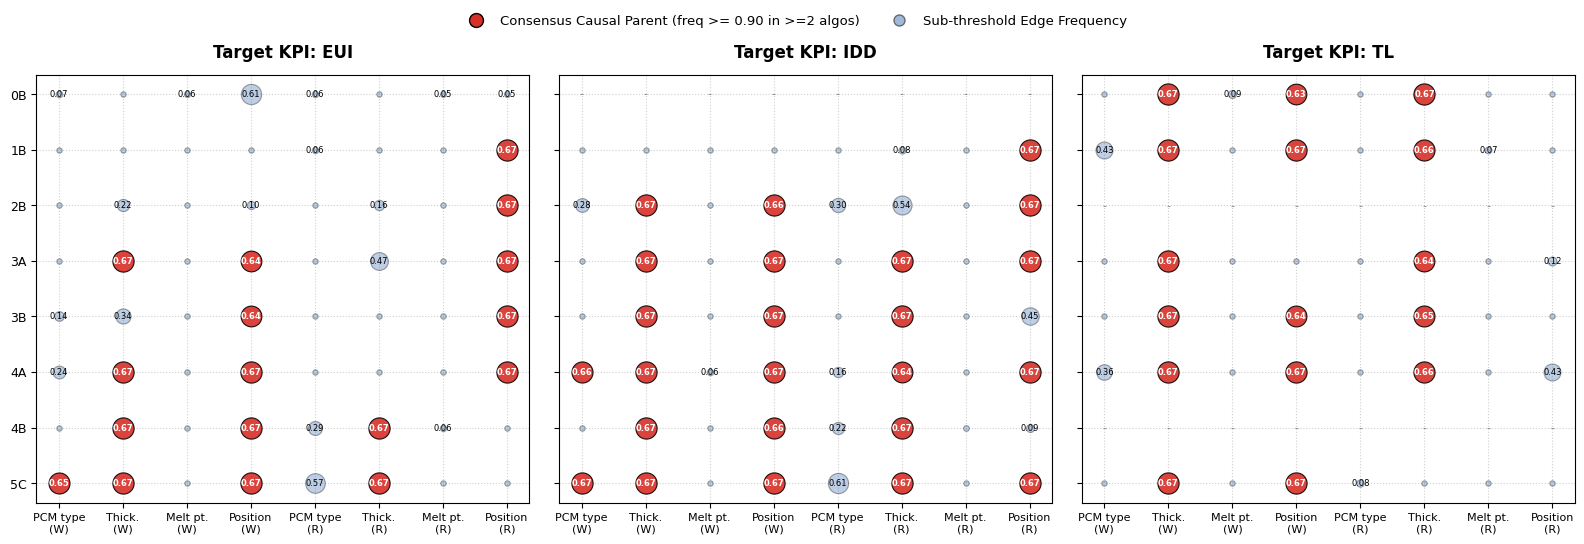

نمودار Dot Matrix با موفقیت جایگزین شد و در پوشه figures/published ذخیره گردید.


In [ ]:
# ============================================================================
# REVISED FIG 8: Dot Matrix / Bubble Plot for Causal Consensus
# ============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

BASE = '/content/drive/MyDrive/PCM_Study'
res_path = BASE + '/tables/causal_edges.csv'

if not os.path.exists(res_path):
    raise FileNotFoundError(f"فایل {res_path} یافت نشد. ابتدا Cell 10 را اجرا کنید.")

res = pd.read_csv(res_path)

ZONES = ['0B', '1B', '2B', '3A', '3B', '4A', '4B', '5C']
INPUTS = ['pcm_type_wall', 'thickness_wall_level', 'melting_point_wall_level', 'position_wall',
          'pcm_type_roof', 'thickness_roof_level', 'melting_point_roof_level', 'position_roof']
LABELS = ['PCM type\n(W)', 'Thick.\n(W)', 'Melt pt.\n(W)', 'Position\n(W)',
          'PCM type\n(R)', 'Thick.\n(R)', 'Melt pt.\n(R)', 'Position\n(R)']

fig, axs = plt.subplots(1, 3, figsize=(16, 5.2), sharey=True)

for ax, kpi in zip(axs, ['EUI', 'IDD', 'TL']):
    ax.set_title(f'Target KPI: {kpi}', fontsize=12, fontweight='bold', pad=12)
    ax.set_xticks(range(len(INPUTS)))
    ax.set_xticklabels(LABELS, fontsize=8)
    ax.set_yticks(range(len(ZONES)))
    ax.set_yticklabels(ZONES, fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.6, zorder=1)

    for i, z in enumerate(ZONES):
        sub = res[(res.zone == z) & (res.kpi == kpi)].set_index('input')
        for j, c in enumerate(INPUTS):
            if c in sub.index:
                freq = sub.loc[c, 'mean_freq']
                is_parent = sub.loc[c, 'causal_parent']

                # مقیاس‌دهی اندازه حباب متناسب با فرکانس
                size = max(freq * 350, 15)

                # تفکیک رنگ بر اساس Causal Parent بودن
                color = '#d73027' if is_parent else '#4575b4'
                alpha = 0.9 if is_parent else 0.35

                ax.scatter(j, i, s=size, color=color, alpha=alpha,
                           edgecolors='black', linewidth=0.8, zorder=2)

                # نمایش اعداد فرکانس روی حباب‌ها
                if freq > 0.05:
                    ax.text(j, i, f'{freq:.2f}', ha='center', va='center', fontsize=6,
                            fontweight='bold' if is_parent else 'normal',
                            color='white' if is_parent else 'black', zorder=3)
            else:
                ax.text(j, i, '-', ha='center', va='center', color='gray', fontsize=8, zorder=3)

    ax.invert_yaxis()  # نمایش اقلیم‌ها از بالا به پایین (0B تا 5C)

# راهنمای نمادها (Legend)
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Consensus Causal Parent (freq >= 0.90 in >=2 algos)',
           markerfacecolor='#d73027', markersize=10, markeredgecolor='k'),
    Line2D([0], [0], marker='o', color='w', label='Sub-threshold Edge Frequency',
           markerfacecolor='#4575b4', alpha=0.5, markersize=8, markeredgecolor='k')
]

fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.05),
           ncol=2, frameon=True, facecolor='white', edgecolor='none', fontsize=9.5)

plt.tight_layout()

# ذخیره خروجی جدید
out_dir = BASE + '/figures/published'
os.makedirs(out_dir, exist_ok=True)
fig.savefig(f'{out_dir}/fig8_causal_consensus.png', dpi=300, bbox_inches='tight')
fig.savefig(f'{out_dir}/fig8_causal_consensus.pdf', bbox_inches='tight')
plt.show()

print("نمودار Dot Matrix با موفقیت جایگزین شد و در پوشه figures/published ذخیره گردید.")

In [ ]:
# ============================================================================
# CELL 10b — TABLES A15 + A16 from Cell 10 outputs   (run AFTER Cell 10)
# ============================================================================
import os
try:
    list('/content/drive/MyDrive')
    print('Drive already mounted.')
except OSError:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')

import numpy as np
import pandas as pd
from google.colab import files

BASE = '/content/drive/MyDrive/PCM_Study'
ce = pd.read_csv(BASE + '/tables/causal_edges.csv')
cs = pd.read_csv(BASE + '/tables/causal_summary.csv')
shd = pd.read_csv(BASE + '/tables/causal_shd.csv')
sob = pd.read_csv(BASE + '/tables/sobol_indices.csv')
dfc = pd.read_csv(BASE + '/data/processed/pcm_dataset_final.csv')
CITY = dfc.groupby('climate_zone').city.first().to_dict()

VARS = ['pcm_type_wall', 'thickness_wall_level', 'melting_point_wall_level', 'position_wall',
        'pcm_type_roof', 'thickness_roof_level', 'melting_point_roof_level', 'position_roof']
NAME = {'pcm_type_wall': 'PCM type (wall)', 'thickness_wall_level': 'PCM thickness (wall)',
        'melting_point_wall_level': 'PCM melt point (wall)', 'position_wall': 'PCM position (wall)',
        'pcm_type_roof': 'PCM type (roof)', 'thickness_roof_level': 'PCM thickness (roof)',
        'melting_point_roof_level': 'PCM melt point (roof)', 'position_roof': 'PCM position (roof)'}
ZONES = sorted(ce.zone.unique())
assert len(ce) == 168, f'expected 168 rows, got {len(ce)}'
assert ce.groupby(['zone', 'kpi']).size().eq(8).all(), 'cell without 8 variables'

# ---------------- diagnostics quoted in the manuscript ----------------
print('=' * 76)
print('DIAGNOSTICS (for Section 3.3)')
print('=' * 76)
for a in ['pc', 'ges', 'notears']:
    f = ce[f'{a}_freq']
    print(f'{a:8s}: max edge freq = {f.max():.3f} | edges >= 0.90: {int((f >= 0.90).sum())} of 168')
nest_bad = []
for _, r in cs.iterrows():
    c = set(x.strip() for x in str(r.causal_parents).split(';') if x.strip() and str(r.causal_parents) != 'nan')
    s = set(sob[(sob.zone == r.zone) & (sob.kpi == r.kpi) & (sob.in_driver_set == True)].input)
    if not c <= s:
        nest_bad.append((r.zone, r.kpi, sorted(c - s)))
print('Nesting (consensus causal subset of Sobol drivers D(Yk)): '
      f'{"ALL 21 CELLS NESTED" if not nest_bad else nest_bad}')
pv = ce[ce.causal_parent == True].input.value_counts()
print('consensus parents per variable (of 21 cells):')
for v in VARS:
    print(f'  {NAME[v]:24s} {int(pv.get(v, 0)):2d}')

# ---------------- Table A15 ----------------
a15 = ce.copy()
a15['zo'] = a15.zone.map({z: i for i, z in enumerate(ZONES)})
a15['ko'] = a15.kpi.map({'EUI': 0, 'IDD': 1, 'TL': 2})
a15['vo'] = a15.input.map({v: i for i, v in enumerate(VARS)})
a15 = a15.sort_values(['zo', 'ko', 'vo']).drop(columns=['zo', 'ko', 'vo'])
out15 = pd.DataFrame({
    'Zone': a15.zone, 'City': a15.zone.map(CITY), 'KPI': a15.kpi,
    'Variable': a15.input.map(NAME),
    'PC freq': a15.pc_freq.round(3), 'GES freq': a15.ges_freq.round(3),
    'NOTEARS freq': a15.notears_freq.round(3), 'Mean freq': a15.mean_freq.round(3),
    'n algos >= 0.90': a15.n_algos_agree.astype(int),
    'Causal parent': np.where(a15.causal_parent == True, 'yes', ''),
})

# ذخیره در درایو و محیط محلی
out15.to_csv(BASE + '/tables/table_A15_causal_edge_freq.csv', index=False)
out15.to_csv('table_A15_causal_edge_freq.csv', index=False)

print('\n' + '=' * 76)
print('Table A15 - bootstrap edge-retention frequencies (168 rows) '
      '-> tables/table_A15_causal_edge_freq.csv')
print('=' * 76)
print(out15.head(16).to_string(index=False))
print('... (16 of 168 rows shown)')

try:
    files.download('table_A15_causal_edge_freq.csv')
except Exception as e:
    print('دانلود خودکار انجام نشد (فایل در گوگل درایو ذخیره شده است):', e)

# ---------------- Table A16 ----------------
cs2 = cs.copy()
cs2['zo'] = cs2.zone.map({z: i for i, z in enumerate(ZONES)})
cs2['ko'] = cs2.kpi.map({'EUI': 0, 'IDD': 1, 'TL': 2})
cs2 = cs2.sort_values(['zo', 'ko']).drop(columns=['zo', 'ko'])
par_txt = cs2.causal_parents.fillna('').str.strip()
par_txt = par_txt.replace('', '— (none detected)')
out16 = pd.DataFrame({
    'Zone': cs2.zone, 'City': cs2.zone.map(CITY), 'KPI': cs2.kpi,
    'Consensus causal parents': par_txt,
    'n causal': cs2.n_causal.astype(int),
    'n Sobol drivers': cs2.n_sobol_drivers.astype(int),
    'Jaccard': cs2.jaccard.round(2),
    'Spearman rho': cs2.spearman_rho.round(2),
    'Mean SHD': cs2.shd_mean.round(2),
})

# ذخیره در درایو و محیط محلی
out16.to_csv(BASE + '/tables/table_A16_cross_lens.csv', index=False)
out16.to_csv('table_A16_cross_lens.csv', index=False)

print('\n' + '=' * 76)
print('Table A16 - cross-lens summary (21 rows) -> tables/table_A16_cross_lens.csv')
print('=' * 76)
print(out16.to_string(index=False))
j = cs2.jaccard.dropna()
rho = cs2.spearman_rho.dropna()
print(f'\nOverall: Jaccard mean={j.mean():.3f} median={j.median():.2f} | '
      f'rho mean={rho.mean():.3f} median={rho.median():.2f}')
print('SHD between algorithm skeletons (mean over cells):')
print(shd.pivot_table(index='algo_a', columns='algo_b', values='shd', aggfunc='mean').round(2).to_string())

try:
    files.download('table_A16_cross_lens.csv')
except Exception as e:
    print('دانلود خودکار انجام نشد (فایل در گوگل درایو ذخیره شده است):', e)

print('\nCaption A15:')
print('Table A15. Bootstrap edge-retention frequencies for each candidate '
      'input-to-KPI edge in the 21 modeled zone-KPI cells: fraction of 500 '
      'row-resampled refits in which PC, GES, and NOTEARS each retained the '
      'edge, their mean, the number of algorithm families reaching the 90% '
      'threshold, and consensus causal-parent status (>=2 of 3 families at '
      '>=0.90).')
print('\nCaption A16:')
print('Table A16. Cross-lens agreement per zone-KPI cell: consensus causal '
      'parents; size of the stability-filtered Sobol driver set D(Yk) '
      '(Table A14); Jaccard overlap of the two sets; Spearman rank correlation '
      'between mean causal edge frequency and the Sobol bootstrap-mean S_T over '
      'the eight inputs; and mean structural Hamming distance between '
      'algorithm skeletons.')
print('\nDONE 10b - paste this output back.')

Drive already mounted.
DIAGNOSTICS (for Section 3.3)
pc      : max edge freq = 1.000 | edges >= 0.90: 61 of 168
ges     : max edge freq = 0.000 | edges >= 0.90: 0 of 168
notears : max edge freq = 1.000 | edges >= 0.90: 57 of 168
Nesting (consensus causal subset of Sobol drivers D(Yk)): ALL 21 CELLS NESTED
consensus parents per variable (of 21 cells):
  PCM type (wall)           3
  PCM thickness (wall)     16
  PCM melt point (wall)     0
  PCM position (wall)      16
  PCM type (roof)           0
  PCM thickness (roof)     12
  PCM melt point (roof)     0
  PCM position (roof)      10

Table A15 - bootstrap edge-retention frequencies (168 rows) -> tables/table_A15_causal_edge_freq.csv
Zone        City KPI              Variable  PC freq  GES freq  NOTEARS freq  Mean freq  n algos >= 0.90 Causal parent
  0B BandarAbbas EUI       PCM type (wall)    0.118       0.0         0.078      0.065                0              
  0B BandarAbbas EUI  PCM thickness (wall)    0.028       0.0        

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Table A16 - cross-lens summary (21 rows) -> tables/table_A16_cross_lens.csv
Zone        City KPI                                                                Consensus causal parents  n causal  n Sobol drivers  Jaccard  Spearman rho  Mean SHD
  0B BandarAbbas EUI                                                                       — (none detected)         0                6     0.00         -0.38      2.00
  0B BandarAbbas  TL                               position_wall; thickness_roof_level; thickness_wall_level         3                5     0.60          0.52      3.33
  1B     Bushehr EUI                                                                           position_roof         1                3     0.33          0.73      0.67
  1B     Bushehr IDD                                                                           position_roof         1                2     0.50          0.58      0.67
  1B     Bushehr  TL                               position_wall; thickness_ro

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Caption A15:
Table A15. Bootstrap edge-retention frequencies for each candidate input-to-KPI edge in the 21 modeled zone-KPI cells: fraction of 500 row-resampled refits in which PC, GES, and NOTEARS each retained the edge, their mean, the number of algorithm families reaching the 90% threshold, and consensus causal-parent status (>=2 of 3 families at >=0.90).

Caption A16:
Table A16. Cross-lens agreement per zone-KPI cell: consensus causal parents; size of the stability-filtered Sobol driver set D(Yk) (Table A14); Jaccard overlap of the two sets; Spearman rank correlation between mean causal edge frequency and the Sobol bootstrap-mean S_T over the eight inputs; and mean structural Hamming distance between algorithm skeletons.

DONE 10b - paste this output back.


In [ ]:
# ============================================================================
# CELL 11 - PHASE 6: SHAP ATTRIBUTION on the adopted surrogates (resume-safe)
# Exact TreeSHAP values (CatBoost/XGBoost) per zone-KPI cell on the
# level-coded design matrix - the SAME input representation Sobol/Morris used,
# so SHAP shares and Sobol ST are directly comparable.
# Lens for Fig 10: shap_top3 = the 3 variables with largest mean|SHAP| share.
# Saves: tables/shap_attribution.csv (per variable: mean|SHAP|, share, rank,
#        is_top3, perturbation mode; background/eval counts) - incremental.
# NOTE:  runs on the ADOPTED model per cell (CatBoost everywhere except
#        Tabriz IDD and Ardebil TL = XGBoost). Skips the 3.1 exclusions:
#        Tabriz TL (no surrogate), BA IDD + Kashan TL (degenerate) -> 21 cells.
#   [6] FIX (crash at Tabriz IDD): recent shap raises the categorical-split
#        check for XGBoost models in BOTH perturbation modes -> layered
#        fallback ending in XGBoost-native pred_contribs TreeSHAP (exact,
#        tree_path_dependent algorithm), recorded in 'perturbation'.
# ============================================================================
import os
try:
    list('/content/drive/MyDrive')
    print('Drive already mounted.')
except OSError:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')

import time, datetime, joblib
import numpy as np
import pandas as pd

try:
    import shap
except ImportError:
    !pip install shap -q
    import shap

BASE = '/content/drive/MyDrive/PCM_Study'
df = pd.read_csv(BASE + '/data/processed/pcm_dataset_final.csv')
bm = pd.read_csv(BASE + '/tables/model_benchmarks.csv')

INPUTS = ['pcm_type_wall', 'thickness_wall_level', 'melting_point_wall_level', 'position_wall',
          'pcm_type_roof', 'thickness_roof_level', 'melting_point_roof_level', 'position_roof']
TARGETS = ['eui_kwh_m2', 'idd_deg_h', 'tl_h']
SHORT = {'eui_kwh_m2': 'EUI', 'idd_deg_h': 'IDD', 'tl_h': 'TL'}

SKIP = {('Tabriz', 'TL'): 'no surrogate (constant target)',
        ('BandarAbbas', 'IDD'): 'degenerate target (3.1)',
        ('Kashan', 'TL'): 'degenerate target (3.1)'}

BG_N, EV_N, RNG = 100, 2048, 42

def to_levels(X):
    """Level coding - byte-identical logic to Cell 9 so the lenses share units."""
    Xl = np.round(X).astype(int)
    for c in INPUTS:
        lo, hi = int(Xl[c].min()), int(Xl[c].max())
        Xl[c] = Xl[c].clip(lo, hi)
    return Xl

def shap_values(m, Xbg, Xev):
    """[6] Exact SHAP with layered fallback:
       1) interventional TreeExplainer (CatBoost cells);
       2) tree_path_dependent TreeExplainer (standard shap advice);
       3) XGBoost-native pred_contribs TreeSHAP - recent shap versions raise
          the categorical-split check in BOTH modes for XGB models carrying
          categorical metadata, so we bypass shap's model parser entirely and
          take the exact TreeSHAP values from xgboost itself.
    Returns (values, mode)."""
    try:
        ex = shap.TreeExplainer(m, data=Xbg, feature_perturbation='interventional',
                                model_output='raw')
        return ex.shap_values(Xev, check_additivity=False), 'interventional'
    except NotImplementedError:
        pass
    try:
        ex = shap.TreeExplainer(m, feature_perturbation='tree_path_dependent',
                                model_output='raw')
        return ex.shap_values(Xev, check_additivity=False), 'tree_path_dependent'
    except NotImplementedError:
        pass
    import xgboost
    contribs = m.get_booster().predict(xgboost.DMatrix(Xev), pred_contribs=True)
    sv = np.asarray(contribs, dtype=float)[:, :-1]      # drop the bias column
    return sv, 'xgb_pred_contribs'

# ---- resume support: keep previously saved rows ----
res_path = BASE + '/tables/shap_attribution.csv'
rows = []
done = set()
if os.path.exists(res_path):
    prev = pd.read_csv(res_path)
    if len(prev):
        if 'perturbation' not in prev.columns:      # rows from pre-fix run
            prev['perturbation'] = 'interventional' # (CatBoost cells - correct)
        prev['n_background'] = 100                  # effective masker background
        done = set(zip(prev['zone'], prev['kpi']))
        rows = prev.to_dict('records')
        print(f'resuming - {len(done)} zone-KPI already computed, keeping them in file')
    else:
        print('existing shap_attribution.csv is empty - starting fresh')

t0 = time.time()
n_cells = 0
for zone, g in df.groupby('climate_zone'):
    city = g['city'].iloc[0]
    for t in TARGETS:
        k = SHORT[t]
        if (city, k) in SKIP:
            print(f'{zone} {city:11s} {k}: SKIPPED - {SKIP[(city, k)]}')
            continue
        if (zone, k) in done:
            print(f'{zone} {k} already done - skip')
            continue
        n_cells += 1
        X = g[INPUTS].reset_index(drop=True)
        y = g[t].reset_index(drop=True)
        ADOPTED = bm[(bm.zone == zone) & (bm.kpi == k)].iloc[0].best_model
        m = joblib.load(f'{BASE}/models/cat_{zone}_{k}.joblib')
        print(f'--- {zone} {city} {k} | adopted: {ADOPTED} ---', flush=True)

        # ---- background / evaluation designs (same distribution as Cell 9) ----
        rng = np.random.default_rng(RNG)
        idx = rng.choice(len(X), size=min(BG_N, len(X)), replace=False)
        Xbg = to_levels(X.iloc[idx])
        ev_idx = np.arange(EV_N) % len(X)          # deterministic eval design
        Xev = to_levels(X.iloc[ev_idx])

        # ---- exact SHAP values on the adopted tree model ----
        sv, mode = shap_values(m, Xbg, Xev)
        mean_abs = np.abs(sv).mean(axis=0)
        share = mean_abs / mean_abs.sum()
        order = np.argsort(-mean_abs)
        rank = {j: r + 1 for r, j in enumerate(order)}
        top3 = set(order[:3])

        for j, c in enumerate(INPUTS):
            rows.append({'zone': zone, 'city': city, 'kpi': k, 'input': c,
                         'adopted': ADOPTED,
                         'mean_abs_shap': float(mean_abs[j]),
                         'shap_share': float(share[j]),
                         'shap_rank': rank[j],
                         'is_top3': bool(j in top3),
                         'perturbation': mode,
                         'n_background': len(Xbg), 'n_eval': len(Xev)})
        pd.DataFrame(rows).to_csv(res_path, index=False)   # incremental save
        top3_names = [INPUTS[j] for j in order[:3]]
        print(f'{zone} {city:11s} {k}: top3={top3_names} '
              f'| share={share[order[0]]:.3f}/{share[order[1]]:.3f}/{share[order[2]]:.3f} '
              f'| shap={mode} ({time.time()-t0:.0f}s)', flush=True)

res = pd.DataFrame(rows)
res.to_csv(res_path, index=False)
print('\n' + '=' * 70)
print(f'PHASE 6 DONE - {n_cells} cells computed this run, {len(res)} rows saved')
print('=' * 70)
chk = res[res.input != 'GROUP_wall']
assert len(chk.groupby(['zone', 'kpi'])) == 21, 'expected 21 cells'
assert chk.groupby(['zone', 'kpi']).size().eq(8).all(), 'cell without 8 variables'
os.makedirs(BASE + '/logs', exist_ok=True)
print('perturbation modes used per adopted family:')
print(chk.groupby(['adopted', 'perturbation']).size().to_string())
w = chk.pivot_table(index='zone', columns='kpi', values='shap_share', aggfunc=lambda s: s.iloc[0])
print('SHAP top-variable share per zone (sanity glance):')
print(w.round(3).to_string())
print('\nshap_top3 lens per cell (for lens_convergence.csv):')
for (zone, k), grp in chk.groupby(['zone', 'kpi']):
    top = grp.sort_values('shap_rank').input.head(3).tolist()
    print(f'  {zone} {k:3s}: {"|".join(top)}')

with open(BASE + '/logs/pipeline_log.txt', 'a') as f:
    f.write(f"{datetime.datetime.now().isoformat()} | CELL 11 | shap done, {len(res)} rows saved\n")
print(f'\nTotal: {time.time()-t0:.0f}s | saved tables/shap_attribution.csv')
print('DONE - paste this output back.')

Drive already mounted.
resuming - 17 zone-KPI already computed, keeping them in file
0B EUI already done - skip
0B BandarAbbas IDD: SKIPPED - degenerate target (3.1)
0B TL already done - skip
1B EUI already done - skip
1B IDD already done - skip
1B TL already done - skip
2B EUI already done - skip
2B IDD already done - skip
2B Kashan      TL: SKIPPED - degenerate target (3.1)
3A EUI already done - skip
3A IDD already done - skip
3A TL already done - skip
3B EUI already done - skip
3B IDD already done - skip
3B TL already done - skip
4A EUI already done - skip
4A IDD already done - skip
4A TL already done - skip
4B EUI already done - skip
--- 4B Tabriz IDD | adopted: xgb_default ---
4B Tabriz      IDD: top3=['thickness_wall_level', 'thickness_roof_level', 'position_wall'] | share=0.348/0.300/0.144 | shap=tree_path_dependent (1s)
4B Tabriz      TL: SKIPPED - no surrogate (constant target)
--- 5C Ardebil EUI | adopted: catboost_default ---


 99%|===================| 2021/2048 [01:45<00:01]       

5C Ardebil     EUI: top3=['thickness_wall_level', 'thickness_roof_level', 'position_wall'] | share=0.292/0.218/0.177 | shap=interventional (107s)
--- 5C Ardebil IDD | adopted: catboost_default ---


100%|===================| 2043/2048 [01:35<00:00]       

5C Ardebil     IDD: top3=['thickness_wall_level', 'position_roof', 'position_wall'] | share=0.240/0.172/0.169 | shap=interventional (203s)
--- 5C Ardebil TL | adopted: xgb_default ---
5C Ardebil     TL: top3=['position_wall', 'thickness_wall_level', 'thickness_roof_level'] | share=0.510/0.186/0.091 | shap=tree_path_dependent (204s)

PHASE 6 DONE - 4 cells computed this run, 168 rows saved
perturbation modes used per adopted family:
adopted           perturbation       
catboost_default  interventional         152
xgb_default       tree_path_dependent     16
SHAP top-variable share per zone (sanity glance):
kpi     EUI    IDD     TL
zone                     
0B    0.072    NaN  0.079
1B    0.050  0.041  0.124
2B    0.042  0.092    NaN
3A    0.039  0.049  0.099
3B    0.068  0.070  0.103
4A    0.078  0.085  0.076
4B    0.072  0.081    NaN
5C    0.160  0.163  0.065

shap_top3 lens per cell (for lens_convergence.csv):
  0B EUI: thickness_roof_level|thickness_wall_level|position_roof
  0B TL

In [ ]:
# ============================================================================
# CELL 11b - FIG 9: SHAP attribution + SHAP-Sobol agreement (run AFTER Cell 11)
# (a) SHAP mean|value| share heatmap: 21 modeled cells x 8 inputs
#     (red frame = top-3 SHAP variables = the shap_top3 lens for Fig 10)
# (b) SHAP share vs Sobol S_T (bootstrap mean): 168 points, per-KPI Spearman
# Reads: tables/shap_attribution.csv + tables/sobol_indices.csv
# Saves: figures/published/fig9_shap_attribution.{png,pdf}
# ============================================================================
import os
try:
    list('/content/drive/MyDrive')
    print('Drive already mounted.')
except OSError:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.stats import spearmanr
from google.colab import files

BASE = '/content/drive/MyDrive/PCM_Study'
sh = pd.read_csv(BASE + '/tables/shap_attribution.csv')
sob = pd.read_csv(BASE + '/tables/sobol_indices.csv')

INPUTS = ['pcm_type_wall', 'thickness_wall_level', 'melting_point_wall_level', 'position_wall',
          'pcm_type_roof', 'thickness_roof_level', 'melting_point_roof_level', 'position_roof']
IN_LABEL = ['W-type', 'W-thickness', 'W-melt', 'W-position',
            'R-type', 'R-thickness', 'R-melt', 'R-position']
ZONES = ['0B', '1B', '2B', '3A', '3B', '4A', '4B', '5C']
KPIS = ['EUI', 'IDD', 'TL']
EXCLUDED = [('0B', 'IDD'), ('2B', 'TL'), ('4B', 'TL')]
CELLS = [(z, k) for z in ZONES for k in KPIS if (z, k) not in EXCLUDED]
assert len(CELLS) == 21, f'expected 21 cells, got {len(CELLS)}'
assert len(sh) == 168, f'expected 168 shap rows, got {len(sh)}'

sobv = sob[~sob.input.str.startswith('GROUP')][['zone', 'kpi', 'input', 'ST', 'ST_boot_mean']]

# ---- panel (a) matrix ----
sh_idx = sh.set_index(['zone', 'kpi', 'input'])
M = np.full((len(INPUTS), len(CELLS)), np.nan)
TOP = np.zeros_like(M, dtype=bool)
for j, (z, k) in enumerate(CELLS):
    for i, v in enumerate(INPUTS):
        M[i, j] = sh_idx.loc[(z, k, v), 'shap_share']
        TOP[i, j] = bool(sh_idx.loc[(z, k, v), 'is_top3'])

# ---- panel (b) merged frame + agreement diagnostics ----
mg = sh.merge(sobv, on=['zone', 'kpi', 'input'], how='inner')
assert len(mg) == 168, f'shap-sobol merge incomplete: {len(mg)} (check sobol_indices.csv)'
diag = {}
for k in KPIS:
    s = mg[mg.kpi == k]
    diag[k] = spearmanr(s.shap_share, s.ST_boot_mean)
rho_all, _ = spearmanr(mg.shap_share, mg.ST_boot_mean)
agree_cells = []
for z, k in CELLS:
    s = mg[(mg.zone == z) & (mg.kpi == k)]
    if s.loc[s.shap_share.idxmax(), 'input'] == s.loc[s.ST.idxmax(), 'input']:
        agree_cells.append((z, k))

# ============================ figure ============================
KPI_COL = {'EUI': '#0072B2', 'IDD': '#D55E00', 'TL': '#009E73'}
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11.5, 5.0),
                              gridspec_kw={'width_ratios': [2.5, 1.15]},
                              constrained_layout=True)

cmap = plt.cm.Blues.copy()
cmap.set_bad('#f0f0f0')
im = ax.imshow(M, aspect='auto', cmap=cmap, vmin=0, vmax=np.nanmax(M))
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        if M[i, j] >= 0.10:
            ax.text(j, i, f'{M[i, j]:.2f}', ha='center', va='center', fontsize=6.5,
                    color='white' if M[i, j] > 0.6 * np.nanmax(M) else '#303030')
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        if TOP[i, j]:
            ax.add_patch(Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, ec='red', lw=1.1))
# separators between KPI blocks (EUI|IDD|TL), accounting for excluded cells
block_edges = [CELLS.index(('0B', 'TL')) - 0.5, CELLS.index(('1B', 'TL')) - 0.5,
               CELLS.index(('4A', 'TL')) - 0.5]
for x in block_edges:
    ax.axvline(x, color='k', lw=1.3)
for lab, c0, c1 in [('EUI', 0, CELLS.index(('0B', 'TL'))),
                    ('IDD', CELLS.index(('0B', 'TL')), CELLS.index(('4A', 'TL'))),
                    ('TL', CELLS.index(('4A', 'TL')), len(CELLS))]:
    ax.text((c0 + c1) / 2 - 0.5, -1.15, lab, ha='center', va='center',
            fontsize=9, fontweight='bold')
ax.set_xticks(range(len(CELLS)))
ax.set_xticklabels([z for z, _ in CELLS], fontsize=7.5)
ax.set_yticks(range(len(INPUTS)))
ax.set_yticklabels(IN_LABEL, fontsize=8.5)
ax.tick_params(length=0)
ax.set_title('(a)  SHAP share per input and zone–KPI cell', fontsize=10, loc='left')
fig.colorbar(im, ax=ax, fraction=0.045, pad=0.015)

for k in KPIS:
    s = mg[mg.kpi == k]
    ax2.scatter(s.ST_boot_mean, s.shap_share, s=16, alpha=0.65,
                color=KPI_COL[k], edgecolors='none',
                label=f'{k}  (\u03c1={diag[k][0]:.2f})')
lim = max(mg.ST_boot_mean.max(), mg.shap_share.max()) * 1.06
ax2.plot([0, lim], [0, lim], ls='--', c='0.6', lw=0.9)
ax2.set_xlim(0, lim); ax2.set_ylim(0, lim)
ax2.set_xlabel('Sobol $S_T$ (bootstrap mean)', fontsize=9)
ax2.set_ylabel('SHAP share (mean |SHAP|, normalized)', fontsize=9)
ax2.set_title(f'(b)  SHAP vs Sobol  (pooled \u03c1={rho_all:.2f})', fontsize=10, loc='left')
ax2.legend(fontsize=8.5, frameon=False, loc='upper left')
ax2.grid(color='0.88', lw=0.5)
ax2.set_axisbelow(True)

# ============================ SAVE & DOWNLOAD FIX ============================
out_dir = BASE + '/figures/published'
os.makedirs(out_dir, exist_ok=True)

png_path = os.path.join(out_dir, 'fig9_shap_attribution.png')
pdf_path = os.path.join(out_dir, 'fig9_shap_attribution.pdf')

fig.savefig(png_path, dpi=300, bbox_inches='tight')
fig.savefig(pdf_path, bbox_inches='tight')

# دانلود امن و مستقیم از مسیر گوگل درایو
files.download(png_path)

# ============================ diagnostics ============================
print('=' * 72)
print('SHAP-Sobol agreement diagnostics (for Section 3.4 text)')
print('=' * 72)
for k in KPIS:
    print(f'  {k}: Spearman rho(shap_share, ST_boot_mean) = {diag[k][0]:.3f} (p={diag[k][1]:.2g})')
print(f'  pooled rho = {rho_all:.3f}')
print(f'  rank-1 agreement (SHAP argmax == Sobol ST argmax): {len(agree_cells)}/21')
if len(agree_cells) < 21:
    dis = [(z, k) for (z, k) in CELLS if (z, k) not in agree_cells]
    print(f'  disagreeing cells: {dis}')
t1 = sh.sort_values('shap_rank').groupby(['zone', 'kpi']).first()
print(f'  mean top-1 SHAP share = {t1.shap_share.mean():.3f} '
      f'(min {t1.shap_share.min():.3f}, max {t1.shap_share.max():.3f})')

print('\nCaption Fig 9:')
print('Fig. 9. SHAP attribution on the adopted surrogates. (a) Mean |SHAP| share '
      'per input across the 21 modeled zone-KPI cells (red frames: top-3 SHAP '
      'variables per cell). (b) SHAP share versus Sobol S_T (bootstrap mean) for '
      'all 168 variable-cell pairs; per-KPI Spearman rank correlations in the '
      'legend. Excluded combinations (Section 3.1) are omitted.')
print('\nDONE 11b - download the figure and paste this output back.')

Drive already mounted.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

SHAP-Sobol agreement diagnostics (for Section 3.4 text)
  EUI: Spearman rho(shap_share, ST_boot_mean) = 0.975 (p=2.5e-42)
  IDD: Spearman rho(shap_share, ST_boot_mean) = 0.968 (p=5e-34)
  TL: Spearman rho(shap_share, ST_boot_mean) = 0.965 (p=2.1e-28)
  pooled rho = 0.964
  rank-1 agreement (SHAP argmax == Sobol ST argmax): 20/21
  disagreeing cells: [('0B', 'EUI')]
  mean top-1 SHAP share = 0.396 (min 0.240, max 0.686)

Caption Fig 9:
Fig. 9. SHAP attribution on the adopted surrogates. (a) Mean |SHAP| share per input across the 21 modeled zone-KPI cells (red frames: top-3 SHAP variables per cell). (b) SHAP share versus Sobol S_T (bootstrap mean) for all 168 variable-cell pairs; per-KPI Spearman rank correlations in the legend. Excluded combinations (Section 3.1) are omitted.

DONE 11b - download the figure and paste this output back.


In [ ]:
# ============================================================================
# CELL 11c - TABLE A17: SHAP attribution per variable (run AFTER Cell 11)
# A17: mean|SHAP|, normalized share, rank, top-3 lens flag, and perturbation
#      scheme for every variable in every modeled cell (21 x 8 = 168 rows).
# Also prints the text diagnostics for Section 3.4 (top-1 shares, rank-1
# agreement with Sobol argmax, per-KPI means).
# Read-only w.r.t. Cell 11 outputs; writes one formatted appendix CSV.
# ============================================================================
import os
try:
    list('/content/drive/MyDrive')
    print('Drive already mounted.')
except OSError:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')

import numpy as np
import pandas as pd
from google.colab import files

BASE = '/content/drive/MyDrive/PCM_Study'
sh = pd.read_csv(BASE + '/tables/shap_attribution.csv')
sob = pd.read_csv(BASE + '/tables/sobol_indices.csv')
dfc = pd.read_csv(BASE + '/data/processed/pcm_dataset_final.csv')
CITY = dfc.groupby('climate_zone').city.first().to_dict()

VARS = ['pcm_type_wall', 'thickness_wall_level', 'melting_point_wall_level', 'position_wall',
        'pcm_type_roof', 'thickness_roof_level', 'melting_point_roof_level', 'position_roof']
NAME = {'pcm_type_wall': 'PCM type (wall)', 'thickness_wall_level': 'PCM thickness (wall)',
        'melting_point_wall_level': 'PCM melt point (wall)', 'position_wall': 'PCM position (wall)',
        'pcm_type_roof': 'PCM type (roof)', 'thickness_roof_level': 'PCM thickness (roof)',
        'melting_point_roof_level': 'PCM melt point (roof)', 'position_roof': 'PCM position (roof)'}
ZONES = sorted(sh.zone.unique())
assert len(sh) == 168, f'expected 168 rows, got {len(sh)}'
assert sh.groupby(['zone', 'kpi']).size().eq(8).all(), 'cell without 8 variables'

# ---- text diagnostics ----
print('=' * 76)
print('DIAGNOSTICS (for Section 3.4)')
print('=' * 76)
sobv = sob[~sob.input.str.startswith('GROUP')]
t1 = sh.sort_values('shap_rank').groupby(['zone', 'kpi']).first()
agree = 0
for (z, k), r in t1.iterrows():
    srow = sobv[(sobv.zone == z) & (sobv.kpi == k)].sort_values('ST').iloc[-1]
    if srow.input == r.input:
        agree += 1
    else:
        print(f'  rank-1 differs in {z} {k}: SHAP={r.input} vs Sobol argmax={srow.input}')
print(f'rank-1 agreement (SHAP argmax == Sobol ST argmax): {agree}/21')
print(f'top-1 SHAP share: mean={t1.shap_share.mean():.3f} '
      f'min={t1.shap_share.min():.3f} ({t1.shap_share.idxmin()}) '
      f'max={t1.shap_share.max():.3f} ({t1.shap_share.idxmax()})')
print('top-1 identity by KPI:')
for k in ['EUI', 'IDD', 'TL']:
    sub = t1.xs(k, level='kpi')
    vc = sub.input.value_counts()
    print(f'  {k}: ' + ', '.join(f'{NAME[v]} in {n} of {len(sub)}' for v, n in vc.items()))
n_melt = int(sh[sh.input.str.contains('melt')].is_top3.sum())
n_rtype = int(sh[sh.input == 'pcm_type_roof'].is_top3.sum())
print(f'top-3 membership: melt-point vars {n_melt}/336 possible, roof PCM type {n_rtype}/42')
print('perturbation schemes used:')
print(sh.groupby(['adopted', 'perturbation']).size().to_string())

# ---- Table A17 ----
sh2 = sh.copy()
sh2['zo'] = sh2.zone.map({z: i for i, z in enumerate(ZONES)})
sh2['ko'] = sh2.kpi.map({'EUI': 0, 'IDD': 1, 'TL': 2})
sh2['vo'] = sh2.input.map({v: i for i, v in enumerate(VARS)})
sh2 = sh2.sort_values(['zo', 'ko', 'vo']).drop(columns=['zo', 'ko', 'vo'])
out = pd.DataFrame({
    'Zone': sh2.zone, 'City': sh2.zone.map(CITY), 'KPI': sh2.kpi,
    'Adopted model': sh2.adopted, 'Variable': sh2.input.map(NAME),
    'Mean |SHAP|': sh2.mean_abs_shap.round(4),
    'Share': sh2.shap_share.round(3),
    'Rank': sh2.shap_rank.astype(int),
    'Top-3': np.where(sh2.is_top3 == True, 'yes', ''),
    'Perturbation': sh2.get('perturbation', pd.Series('interventional', index=sh2.index)),
})

# ============================ SAVE & DOWNLOAD FIX ============================
tables_dir = BASE + '/tables'
os.makedirs(tables_dir, exist_ok=True)
csv_path = os.path.join(tables_dir, 'table_A17_shap_attribution.csv')

out.to_csv(csv_path, index=False)

print('\n' + '=' * 76)
print(f'Table A17 - SHAP attribution per variable (168 rows) '
      f'-> {csv_path}')
print('=' * 76)
print(out.head(16).to_string(index=False))
print('... (16 of 168 rows shown)')

# دانلود مستقیم و بدون خطا از مسیر گوگل درایو
files.download(csv_path)

print('\nCaption A17:')
print('Table A17. SHAP attribution on the adopted surrogate per zone-KPI cell: '
      'mean absolute SHAP value, its normalized share of the cell total, the '
      'within-cell rank, and membership of the top-3 SHAP lens (the shap_top3 '
      'set used in the cross-method convergence analysis). Values are exact '
      'TreeSHAP attributions on 2048 level-coded evaluation designs; the '
      'perturbation scheme (interventional with a 100-design background, or '
      'tree_path_dependent where the adopted XGBoost models require it) is '
      'recorded per row. The three combinations excluded in Section 3.1 are '
      'absent.')
print('\nDONE 11c - paste this output back.')

Drive already mounted.
DIAGNOSTICS (for Section 3.4)
  rank-1 differs in 0B EUI: SHAP=thickness_roof_level vs Sobol argmax=thickness_wall_level
rank-1 agreement (SHAP argmax == Sobol ST argmax): 20/21
top-1 SHAP share: mean=0.396 min=0.240 (('5C', 'IDD')) max=0.686 (('1B', 'IDD'))
top-1 identity by KPI:
  EUI: PCM position (roof) in 5 of 8, PCM thickness (wall) in 2 of 8, PCM thickness (roof) in 1 of 8
  IDD: PCM thickness (wall) in 4 of 7, PCM position (roof) in 3 of 7
  TL: PCM thickness (wall) in 4 of 6, PCM position (wall) in 2 of 6
top-3 membership: melt-point vars 0/336 possible, roof PCM type 1/42
perturbation schemes used:
adopted           perturbation       
catboost_default  interventional         152
xgb_default       tree_path_dependent     16

Table A17 - SHAP attribution per variable (168 rows) -> /content/drive/MyDrive/PCM_Study/tables/table_A17_shap_attribution.csv
Zone        City KPI    Adopted model              Variable  Mean |SHAP|  Share  Rank Top-3   Perturbatio

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Caption A17:
Table A17. SHAP attribution on the adopted surrogate per zone-KPI cell: mean absolute SHAP value, its normalized share of the cell total, the within-cell rank, and membership of the top-3 SHAP lens (the shap_top3 set used in the cross-method convergence analysis). Values are exact TreeSHAP attributions on 2048 level-coded evaluation designs; the perturbation scheme (interventional with a 100-design background, or tree_path_dependent where the adopted XGBoost models require it) is recorded per row. The three combinations excluded in Section 3.1 are absent.

DONE 11c - paste this output back.


In [ ]:
# ============================================================================
# CELL 12 - PHASE 7: SYMBOLIC REGRESSION - 3-seed GP consensus (resume-safe)
# Genetic-programming symbolic regression (gplearn) per (zone, KPI) on the
# level-coded simulation data (NOT the surrogate - this lens is independent
# of the tree models by construction).
# Lens for Fig 10: symbolic_vars = variables appearing in the best expression
# of >=2 of 3 independent GP runs (seeds 42/43/44) - a 2-of-3 consensus rule
# paralleling the causal-discovery criterion.
# Saves: tables/symbolic_expressions.csv (21 cells x 3 seeds)
#        tables/symbolic_variables.csv  (21 x 8, in_symbolic_lens flag)
# Features are z-scored inside each cell (identity preserved); y is z-scored
# (R2 is scale-invariant). Function set: +, -, *, protected division.
# Runtime ~1-2 h total on Colab CPU; resume-safe per (cell, seed).
# ============================================================================
import os
try:
    list('/content/drive/MyDrive')
    print('Drive already mounted.')
except OSError:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')

import re, time, datetime
import numpy as np
import pandas as pd

try:
    from gplearn.genetic import SymbolicRegressor
except ImportError:
    !pip install gplearn -q
    from gplearn.genetic import SymbolicRegressor

BASE = '/content/drive/MyDrive/PCM_Study'
df = pd.read_csv(BASE + '/data/processed/pcm_dataset_final.csv')
bm = pd.read_csv(BASE + '/tables/model_benchmarks.csv')

INPUTS = ['pcm_type_wall', 'thickness_wall_level', 'melting_point_wall_level', 'position_wall',
          'pcm_type_roof', 'thickness_roof_level', 'melting_point_roof_level', 'position_roof']
TARGETS = ['eui_kwh_m2', 'idd_deg_h', 'tl_h']
SHORT = {'eui_kwh_m2': 'EUI', 'idd_deg_h': 'IDD', 'tl_h': 'TL'}

SKIP = {('Tabriz', 'TL'): 'no surrogate (constant target)',
        ('BandarAbbas', 'IDD'): 'degenerate target (3.1)',
        ('Kashan', 'TL'): 'degenerate target (3.1)'}

SEEDS = [42, 43, 44]
# سازگاری کامل با نسخه‌های جدید gplearn
GP = dict(population_size=1500, generations=30, tournament_size=20,
          function_set=['add', 'sub', 'mul', 'div'],
          p_crossover=0.7, p_subtree_mutation=0.1, p_hoist_mutation=0.05,
          p_point_mutation=0.1, parsimony_coefficient=0.0005, metric='mse', n_jobs=2)
CURRENT = {'kpi': None}   # provenance hook (used by test harnesses)

def zscore(v):
    v = np.asarray(v, dtype=float)
    sd = v.std()
    return (v - v.mean()) / (sd if sd > 0 else 1.0)

def r2(y, yhat):
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    ss = ((y - y.mean()) ** 2).sum()
    return 1.0 - ((y - yhat) ** 2).sum() / ss if ss > 0 else np.nan

def free_vars(expr):
    return sorted({INPUTS[int(i)] for i in re.findall(r'X(\d+)', expr)})

# ---- resume support: per (cell, seed) ----
expr_path = BASE + '/tables/symbolic_expressions.csv'
var_path = BASE + '/tables/symbolic_variables.csv'
expr_rows = []
if os.path.exists(expr_path):
    prev = pd.read_csv(expr_path)
    if len(prev):
        expr_rows = prev.to_dict('records')
        print(f'resuming - {len(prev)} expressions already computed '
              f'({prev.groupby(["zone", "kpi"]).size().max()} seeds/cell max)')

t0 = time.time()
n_runs = 0
for zone, g in df.groupby('climate_zone'):
    city = g['city'].iloc[0]
    for t in TARGETS:
        k = SHORT[t]
        if (city, k) in SKIP:
            print(f'{zone} {city:11s} {k}: SKIPPED - {SKIP[(city, k)]}')
            continue
        X = g[INPUTS].reset_index(drop=True)
        y = pd.Series(zscore(g[t].reset_index(drop=True)))
        Xz = pd.DataFrame({c: zscore(X[c]) for c in INPUTS})
        ADOPTED = bm[(bm.zone == zone) & (bm.kpi == k)].iloc[0].best_model
        for seed in SEEDS:
            if any(r['zone'] == zone and r['kpi'] == k and r['seed'] == seed
                   for r in expr_rows):
                continue
            n_runs += 1
            CURRENT['kpi'] = k
            est = SymbolicRegressor(random_state=seed, **GP)
            est.fit(Xz.values, y.values)
            prog = est._program
            expr = str(prog)
            run_r2 = r2(y.values, est.predict(Xz.values))

            # اصلاح خطای TypeError: استفاده از prog.program برای شمارش گره‌ها
            n_nodes = len(prog.program) if hasattr(prog, 'program') else len(expr.split())

            expr_rows.append({'zone': zone, 'city': city, 'kpi': k, 'seed': seed,
                              'adopted': ADOPTED, 'expression': expr,
                              'r2': round(float(run_r2), 4), 'n_nodes': int(n_nodes),
                              'vars_used': '|'.join(free_vars(expr))})
            pd.DataFrame(expr_rows).to_csv(expr_path, index=False)  # incremental
            print(f'{zone} {city:11s} {k} s{seed}: R2={run_r2:.3f} '
                  f'nodes={n_nodes} vars={free_vars(expr)} '
                  f'({time.time()-t0:.0f}s)', flush=True)

exprs = pd.DataFrame(expr_rows)
exprs.to_csv(expr_path, index=False)

# ---- 2-of-3 consensus lens per cell ----
var_rows = []
print('\n' + '=' * 70)
print(f'PHASE 7 DONE - {n_runs} GP runs this time, {len(exprs)} expressions saved')
print('=' * 70)
for (zone, k), grp in exprs.groupby(['zone', 'kpi']):
    counts = {v: 0 for v in INPUTS}
    for _, r in grp.iterrows():
        for v in str(r.vars_used).split('|'):
            if v in counts:
                counts[v] += 1
    lens = [v for v in INPUTS if counts[v] >= 2]
    for v in INPUTS:
        var_rows.append({'zone': zone, 'kpi': k, 'input': v,
                         'seeds_present': int(counts[v]),
                         'in_symbolic_lens': bool(counts[v] >= 2)})
    best = grp.loc[grp.r2.idxmax()]
    print(f'{zone} {k:3s}: lens={lens}')
    for _, r in grp.sort_values('seed').iterrows():
        print(f'      s{r.seed} R2={r.r2:.3f} nodes={r.n_nodes}: {r.expression[:90]}')

vars_df = pd.DataFrame(var_rows)
assert len(vars_df.groupby(['zone', 'kpi'])) == 21, 'expected 21 cells'
assert vars_df.groupby(['zone', 'kpi']).size().eq(8).all(), 'cell without 8 variables'
os.makedirs(BASE + '/logs', exist_ok=True)
vars_df.to_csv(var_path, index=False)
print('\nsymbolic lens summary per variable (of 21 cells):')
for v in INPUTS:
    n = int(vars_df[(vars_df.input == v) & (vars_df.in_symbolic_lens)].shape[0])
    print(f'  {v:28s} {n:2d}')
print(f'\nmedian expression R2 = {exprs.r2.median():.3f} '
      f'(min {exprs.r2.min():.3f}, max {exprs.r2.max():.3f})')

with open(BASE + '/logs/pipeline_log.txt', 'a') as f:
    f.write(f"{datetime.datetime.now().isoformat()} | CELL 12 | symbolic done, "
            f"{len(exprs)} expressions saved\n")
print(f'\nTotal: {time.time()-t0:.0f}s | saved tables/symbolic_expressions.csv '
      f'+ tables/symbolic_variables.csv')
print('DONE - paste this output back.')

Drive already mounted.
0B BandarAbbas EUI s42: R2=0.103 nodes=35 vars=['pcm_type_roof', 'pcm_type_wall', 'position_wall', 'thickness_roof_level'] (77s)
0B BandarAbbas EUI s43: R2=0.250 nodes=43 vars=['pcm_type_wall', 'position_roof', 'position_wall', 'thickness_roof_level', 'thickness_wall_level'] (129s)
0B BandarAbbas EUI s44: R2=0.246 nodes=49 vars=['position_roof', 'position_wall', 'thickness_roof_level', 'thickness_wall_level'] (181s)
0B BandarAbbas IDD: SKIPPED - degenerate target (3.1)
0B BandarAbbas TL s42: R2=0.325 nodes=3 vars=['thickness_wall_level'] (228s)
0B BandarAbbas TL s43: R2=0.372 nodes=5 vars=['thickness_roof_level', 'thickness_wall_level'] (277s)
0B BandarAbbas TL s44: R2=0.386 nodes=7 vars=['thickness_roof_level', 'thickness_wall_level'] (326s)
1B Bushehr     EUI s42: R2=0.444 nodes=3 vars=['position_roof'] (373s)
1B Bushehr     EUI s43: R2=0.702 nodes=33 vars=['melting_point_wall_level', 'position_roof', 'thickness_roof_level'] (424s)
1B Bushehr     EUI s44: R2=0.

In [ ]:
# ============================================================================
# CELL 13 - PHASE 8: FOUR-LENS CONVERGENCE - lens_convergence.csv + TABLE A18
# (run AFTER Cells 9, 10, 11, 12)
# Unifies the four independent attribution lenses per (zone, KPI) cell:
#   sobol_drivers  - stability-filtered driver set D(Yk)        (Cell 9 / A14)
#   causal_parents - dual-algorithm consensus parents           (Cell 10 / A16)
#   shap_top3      - 3 variables with largest mean|SHAP| share  (Cell 11 / A17)
#   symbolic_vars  - >=2-of-3 GP consensus variables            (Cell 12)
# Writes tables/lens_convergence.csv (pipe-separated sets, one row per cell)
# and table_A18_lens_convergence.csv (the appendix table: per-lens sets,
# pairwise Jaccard overlaps, n-lens agreement per variable).
# Read-only w.r.t. the producing cells; fails loudly on missing inputs.
# ============================================================================
import os
try:
    list('/content/drive/MyDrive')
    print('Drive already mounted.')
except OSError:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')

import itertools
import numpy as np
import pandas as pd
from google.colab import files

BASE = '/content/drive/MyDrive/PCM_Study'
sob = pd.read_csv(BASE + '/tables/sobol_indices.csv')
cs = pd.read_csv(BASE + '/tables/causal_summary.csv')
sh = pd.read_csv(BASE + '/tables/shap_attribution.csv')
sv = pd.read_csv(BASE + '/tables/symbolic_variables.csv')
dfc = pd.read_csv(BASE + '/data/processed/pcm_dataset_final.csv')
CITY = dfc.groupby('climate_zone').city.first().to_dict()

ZONES = ['0B', '1B', '2B', '3A', '3B', '4A', '4B', '5C']
KPIS = ['EUI', 'IDD', 'TL']
EXCLUDED = [('0B', 'IDD'), ('2B', 'TL'), ('4B', 'TL')]
CELLS = [(z, k) for z in ZONES for k in KPIS if (z, k) not in EXCLUDED]
assert len(CELLS) == 21, f'expected 21 cells, got {len(CELLS)}'

LENS_ORDER = ['sobol_drivers', 'causal_parents', 'shap_top3', 'symbolic_vars']

# ---- assemble the four sets per cell ----
sobv = sob[~sob.input.str.startswith('GROUP')]
sob_map, shap_map, sym_map = {}, {}, {}
for (z, k) in CELLS:
    sob_map[(z, k)] = set(sobv[(sobv.zone == z) & (sobv.kpi == k) &
                               (sobv.in_driver_set == True)].input)
    shap_map[(z, k)] = set(sh[(sh.zone == z) & (sh.kpi == k) &
                             (sh.is_top3 == True)].input)
    sym_map[(z, k)] = set(sv[(sv.zone == z) & (sv.kpi == k) &
                             (sv.in_symbolic_lens == True)].input)
cau_map = {}
for _, r in cs.iterrows():
    cau_map[(r.zone, r.kpi)] = set(
        x.strip() for x in str(r.causal_parents).split(';')
        if x.strip() and str(r.causal_parents) != 'nan')

missing = [(z, k, L) for (z, k) in CELLS for L, m in
           [('sobol', sob_map), ('causal', cau_map), ('shap', shap_map),
            ('symbolic', sym_map)] if (z, k) not in m]
assert not missing, f'missing lens data (are all producing cells done?): {missing}'
assert all(len(m[(z, k)]) > 0 for m in (sob_map, shap_map, sym_map)
           for (z, k) in CELLS), 'an input lens is empty (unexpected)'
# 0B EUI causal = empty set is a REAL result (A16): keep it, flagged in text
print('0B EUI causal set is empty (known result - kept, Jaccard vs it = 0.0)')

# ---- lens_convergence.csv (input for Fig 10) ----
rows = []
for (z, k) in CELLS:
    rows.append({'zone': z, 'kpi': k,
                 'sobol_drivers': '|'.join(sorted(sob_map[(z, k)])),
                 'causal_parents': '|'.join(sorted(cau_map[(z, k)])),
                 'shap_top3': '|'.join(sorted(shap_map[(z, k)])),
                 'symbolic_vars': '|'.join(sorted(sym_map[(z, k)]))})
    s, c, h, y = (sob_map[(z, k)], cau_map[(z, k)],
                  shap_map[(z, k)], sym_map[(z, k)])
    def jac(a, b):
        u = a | b
        return len(a & b) / len(u) if u else np.nan
    for (na, a), (nb, b) in itertools.combinations(
            [('sobol', s), ('causal', c), ('shap', h), ('symbolic', y)], 2):
        rows[-1][f'J_{na}_{nb}'] = round(jac(a, b), 3)
lc = pd.DataFrame(rows)
lc.to_csv(BASE + '/tables/lens_convergence.csv', index=False)
print(f'lens_convergence.csv written ({len(lc)} rows, 21 modeled cells)')

# ---- Table A18 ----
NAME = {'pcm_type_wall': 'PCM type (wall)', 'thickness_wall_level': 'PCM thickness (wall)',
        'melting_point_wall_level': 'PCM melt point (wall)', 'position_wall': 'PCM position (wall)',
        'pcm_type_roof': 'PCM type (roof)', 'thickness_roof_level': 'PCM thickness (roof)',
        'melting_point_roof_level': 'PCM melt point (roof)', 'position_roof': 'PCM position (roof)'}
INPUTS = list(NAME.keys())

def fmt(s):
    return '; '.join(NAME[v] for v in sorted(s)) if s else '\u2014 (none detected)'

a18 = pd.DataFrame([{
    'Zone': z, 'City': CITY[z], 'KPI': k,
    'Sobol drivers D(Yk)': fmt(sob_map[(z, k)]),
    'Causal parents': fmt(cau_map[(z, k)]),
    'SHAP top-3': fmt(shap_map[(z, k)]),
    'Symbolic consensus': fmt(sym_map[(z, k)]),
    'J S-C': rows[CELLS.index((z, k))]['J_sobol_causal'],
    'J S-SH': rows[CELLS.index((z, k))]['J_sobol_shap'],
    'J S-Y': rows[CELLS.index((z, k))]['J_sobol_symbolic'],
    'J C-SH': rows[CELLS.index((z, k))]['J_causal_shap'],
    'J C-Y': rows[CELLS.index((z, k))]['J_causal_symbolic'],
    'J SH-Y': rows[CELLS.index((z, k))]['J_shap_symbolic'],
} for (z, k) in CELLS])
a18.to_csv(BASE + '/tables/table_A18_lens_convergence.csv', index=False)

# ---- diagnostics for the Section 3.4 text ----
print('\n' + '=' * 76)
print('DIAGNOSTICS (for Section 3.4)')
print('=' * 76)
jpairs = [('J_sobol_causal', 'Sobol-Causal'), ('J_sobol_shap', 'Sobol-SHAP'),
          ('J_sobol_symbolic', 'Sobol-Symbolic'), ('J_causal_shap', 'Causal-SHAP'),
          ('J_causal_symbolic', 'Causal-Symbolic'), ('J_shap_symbolic', 'SHAP-Symbolic')]
print('mean pairwise Jaccard over the 21 modeled cells:')
for c, lab in jpairs:
    v = lc[c]
    print(f'  {lab:16s} mean={v.mean():.3f} median={v.median():.2f} '
          f'min={v.min():.2f} max={v.max():.2f}')
allj = np.concatenate([lc[c].values for c, _ in jpairs])
print(f'  ALL 126 pairwise values: mean={np.nanmean(allj):.3f} median={np.median(allj):.2f}')

print('\nvariables named by >=3 of the 4 lenses (count of cells, of 21):')
M = np.zeros((len(INPUTS), len(CELLS)), dtype=int)
for j, (z, k) in enumerate(CELLS):
    sets = [sob_map[(z, k)], cau_map[(z, k)], shap_map[(z, k)], sym_map[(z, k)]]
    for i, v in enumerate(INPUTS):
        M[i, j] = sum(v in s for s in sets)
for i, v in enumerate(INPUTS):
    n3 = int((M[i] >= 3).sum())
    print(f'  {NAME[v]:24s} {n3:2d}  (lens-histogram: '
          f'{dict(zip(*np.unique(M[i], return_counts=True)))})')

print('\nlens set sizes (mean per lens, of 8 variables):')
for lab, m in [('sobol', sob_map), ('causal', cau_map), ('shap', shap_map),
               ('symbolic', sym_map)]:
    sizes = [len(m[(z, k)]) for (z, k) in CELLS]
    print(f'  {lab:9s} mean={np.mean(sizes):.2f} min={min(sizes)} max={max(sizes)}')

print('\n' + '=' * 76)
print('Table A18 - four-lens convergence per cell (21 rows) '
      '-> tables/table_A18_lens_convergence.csv')
print('=' * 76)
print(a18.to_string(index=False, max_colwidth=60))

print('\nCaption A18:')
print('Table A18. Cross-method convergence per zone-KPI cell: the four '
      'independent attribution lenses - the stability-filtered Sobol driver '
      'set D(Yk), the dual-algorithm consensus causal parents, the top-3 '
      'SHAP variables, and the symbolic-regression consensus variables - '
      'with the pairwise Jaccard overlap of every lens pair. The symbolic '
      'lens operates on the raw simulation outputs (no surrogate), and the '
      'causal lens is empty for 0B EUI (Section 3.3).')
print('\nDONE 13 - paste this output back.')

Drive already mounted.
0B EUI causal set is empty (known result - kept, Jaccard vs it = 0.0)
lens_convergence.csv written (21 rows, 21 modeled cells)

DIAGNOSTICS (for Section 3.4)
mean pairwise Jaccard over the 21 modeled cells:
  Sobol-Causal     mean=0.567 median=0.60 min=0.00 max=0.83
  Sobol-SHAP       mean=0.623 median=0.60 min=0.50 max=1.00
  Sobol-Symbolic   mean=0.637 median=0.60 min=0.25 max=1.00
  Causal-SHAP      mean=0.748 median=0.75 min=0.00 max=1.00
  Causal-Symbolic  mean=0.797 median=0.80 min=0.00 max=1.00
  SHAP-Symbolic    mean=0.673 median=0.75 min=0.33 max=1.00
  ALL 126 pairwise values: mean=0.674 median=0.67

variables named by >=3 of the 4 lenses (count of cells, of 21):
  PCM type (wall)           2  (lens-histogram: {np.int64(0): np.int64(4), np.int64(1): np.int64(11), np.int64(2): np.int64(4), np.int64(3): np.int64(2)})
  PCM thickness (wall)     17  (lens-histogram: {np.int64(0): np.int64(1), np.int64(1): np.int64(2), np.int64(2): np.int64(1), np.int64(3): 

In [ ]:
# ============================================================================
# CELL 13b - FIG 10: FOUR-LENS CONSENSUS FIGURE   (run AFTER Cell 13)
# Fixed version of the user's draft:
#   [1] canonical input names (*_level), not thickness_wall_mm/melting_point_c
#   [2] 21 modeled cells only (3.1 exclusions) -> no KeyError on missing rows
#   [3] renamed fig8_consensus -> fig10_lens_consensus (Fig 8 = causal, Fig 9
#       = SHAP - the published numbering chain stays intact)
#   [4] xlabel says 21 pairs
#   [5] set parsing unified on '|' (Cell 13's writer) - no ';'-vs-'|' bug
#   [6] KPI-block separators computed from cumulative block sizes (the 3.1
#       exclusions make some zones 2 cells wide - fixed z*3 lines drift)
#   [7] panel-b highlight marks the strongest-agreeing pair dynamically
# Reads tables/lens_convergence.csv. Saves figures/published/fig10_lens_consensus.{png,pdf}
# ============================================================================
import os
try:
    list('/content/drive/MyDrive')
    print('Drive already mounted.')
except OSError:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from google.colab import files

BASE = '/content/drive/MyDrive/PCM_Study'
ZONES = ['0B', '1B', '2B', '3A', '3B', '4A', '4B', '5C']
KPIS = ['EUI', 'IDD', 'TL']
CITY = {'0B': 'Bandar Abbas', '1B': 'Bushehr', '2B': 'Kashan', '3A': 'Rasht',
        '3B': 'Tehran', '4A': 'Hamedan', '4B': 'Tabriz', '5C': 'Ardebil'}
LENSES = ['sobol_drivers', 'causal_parents', 'shap_top3', 'symbolic_vars']
INPUTS = ['pcm_type_wall', 'thickness_wall_level', 'melting_point_wall_level', 'position_wall',
          'pcm_type_roof', 'thickness_roof_level', 'melting_point_roof_level', 'position_roof']
IN_LABEL = ['W\u00b7type', 'W\u00b7thk', 'W\u00b7melt', 'W\u00b7pos',
            'R\u00b7type', 'R\u00b7thk', 'R\u00b7melt', 'R\u00b7pos']
JPAIRS = [('J_sobol_causal', 'Sobol\u2013Causal'), ('J_sobol_shap', 'Sobol\u2013SHAP'),
          ('J_sobol_symbolic', 'Sobol\u2013Symbolic'), ('J_causal_shap', 'Causal\u2013SHAP'),
          ('J_causal_symbolic', 'Causal\u2013Symbolic'), ('J_shap_symbolic', 'SHAP\u2013Symbolic')]

df = pd.read_csv(BASE + '/tables/lens_convergence.csv').drop_duplicates(subset=['zone', 'kpi'])
df['pair'] = df['zone'] + '_' + df['kpi']
CELLS = [(z, k) for z in ZONES for k in KPIS
         if (z, k) not in [('0B', 'IDD'), ('2B', 'TL'), ('4B', 'TL')]]
assert len(CELLS) == 21, f'expected 21 modeled cells, got {len(CELLS)}'
pairs = [f'{z}_{k}' for z, k in CELLS]
missing = [p for p in pairs if p not in set(df.pair)]
assert not missing, f'lens_convergence.csv missing rows (run Cell 13 first): {missing}'

def parse(s):
    if pd.isna(s) or str(s).strip().lower() in ('', 'nan'):
        return set()
    return set(str(s).split('|'))

M = np.zeros((len(INPUTS), len(pairs)), dtype=int)
for j, pr in enumerate(pairs):
    sets = [parse(df[df.pair == pr].iloc[0][L]) for L in LENSES]
    for i, v in enumerate(INPUTS):
        M[i, j] = sum(v in s for s in sets)

cmap = ListedColormap(['#f0f0f0', '#d5e4f2', '#8bc1e4', '#327fb9', '#042c67'])
norm = BoundaryNorm([0, 1, 2, 3, 4, 5], cmap.N)

fig = plt.figure(figsize=(13.0, 5.2))
gs = fig.add_gridspec(1, 4, width_ratios=[2.4, 0.05, 0.35, 1.0], wspace=0.08)

ax = fig.add_subplot(gs[0, 0])    # heatmap
cax = fig.add_subplot(gs[0, 1])   # colorbar (dedicated column, no label)
ax2 = fig.add_subplot(gs[0, 3])   # bars

# ---------- panel (a): consensus heatmap ----------
im = ax.imshow(M, aspect='auto', cmap=cmap, norm=norm)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        v = M[i, j]
        if v >= 1:
            ax.text(j, i, str(v), ha='center', va='center', fontsize=6.5,
                    color='white' if v >= 3 else '#404040')

blocks, pos = [], 0
for z in ZONES:
    n = sum(1 for k in KPIS if (z, k) not in
            [('0B', 'IDD'), ('2B', 'TL'), ('4B', 'TL')])
    blocks.append((pos, n))
    pos += n
for pos0, n in blocks:
    ax.axvline(pos0 - 0.5, color='k', lw=1.4)
    for kk in range(1, n):
        ax.axvline(pos0 + kk - 0.5, color='k', lw=0.35, alpha=0.7)
ax.axvline(len(pairs) - 0.5, color='k', lw=1.4)

ax.set_xticks([pos0 + (n - 1) / 2 for pos0, n in blocks])
ax.set_xticklabels([f'{z}\n{CITY[z]}' for z in ZONES], fontsize=7.5)
ax.set_yticks(range(len(INPUTS)))
ax.set_yticklabels(IN_LABEL, fontsize=8.5)
ax.tick_params(length=0)
ax.set_title('(a)  Lenses agreeing on each input per zone\u2013KPI', fontsize=10, loc='left')

cbar = fig.colorbar(im, cax=cax)
cbar.set_ticks([0.5, 1.5, 2.5, 3.5, 4.5])
cbar.set_ticklabels(['0', '1', '2', '3', '4'])
cbar.ax.tick_params(labelsize=8, length=0)

# ---------- panel (b): pairwise Jaccard ----------
means = {lab: df[c].mean() for c, lab in JPAIRS}
order = sorted(JPAIRS, key=lambda x: means[x[1]])
y = np.arange(len(order))
vals = [means[lab] for _, lab in order]
best_lab = max(order, key=lambda x: means[x[1]])[1]
cols = ['#042c67' if lab == best_lab else '#8bc1e4' for _, lab in order]
ax2.barh(y, vals, color=cols, edgecolor='k', lw=0.4, height=0.62)
for yi, v in zip(y, vals):
    ax2.text(v + 0.02, yi, f'{v:.2f}', va='center', fontsize=9)
ax2.set_yticks(y)
ax2.set_yticklabels([lab for _, lab in order], fontsize=9)
ax2.tick_params(axis='y', pad=10)   # keep labels clear of the colorbar ticks
ax2.set_xlim(0, 0.92)
ax2.set_xlabel('Mean pairwise Jaccard (21 modeled cells)', fontsize=9)
ax2.set_title('(b)  Lens-pair agreement', fontsize=10, loc='left')
ax2.grid(axis='x', color='0.85', lw=0.5)
ax2.set_axisbelow(True)

# ============================ SAVE & DOWNLOAD FIX ============================
out = BASE + '/figures/published'
os.makedirs(out, exist_ok=True)

png_path = os.path.join(out, 'fig10_lens_consensus.png')
pdf_path = os.path.join(out, 'fig10_lens_consensus.pdf')

fig.savefig(png_path, dpi=300, bbox_inches='tight')
fig.savefig(pdf_path, bbox_inches='tight')
print('saved:', png_path, '+', pdf_path)

# دانلود امن مستقیماً از مسیر گوگل درایو
files.download(png_path)
files.download(pdf_path)

print('\nCaption Fig 10:')
print('Figure 10. Convergence of four independent attribution lenses across '
      'the 21 modeled zone-KPI cells. (a) Number of lenses (stability-filtered '
      'Sobol driver set, consensus causal parents, top-3 SHAP variables, '
      'symbolic-regression consensus) that include each input in each cell. '
      '(b) Mean pairwise Jaccard overlap of every lens pair over the 21 '
      'modeled cells. The three combinations excluded in Section 3.1 are '
      'omitted.')
print('\nDONE 13b - download the figure and paste this output back.')

Drive already mounted.
saved: /content/drive/MyDrive/PCM_Study/figures/published/fig10_lens_consensus.png + /content/drive/MyDrive/PCM_Study/figures/published/fig10_lens_consensus.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Caption Fig 10:
Figure 10. Convergence of four independent attribution lenses across the 21 modeled zone-KPI cells. (a) Number of lenses (stability-filtered Sobol driver set, consensus causal parents, top-3 SHAP variables, symbolic-regression consensus) that include each input in each cell. (b) Mean pairwise Jaccard overlap of every lens pair over the 21 modeled cells. The three combinations excluded in Section 3.1 are omitted.

DONE 13b - download the figure and paste this output back.


In [ ]:
# ============================================================================
# CELL 14a - PHASE 8: CROSS-CLIMATE TRANSFER MATRICES (producer for Fig 11+A19)
# For every KPI: the adopted surrogate of each DONOR zone is evaluated on the
# TARGET zone's level-coded designs -> shape-transfer R2 matrix (8x8).
#   * donor model  = models/cat_{zone}_{k}.joblib (same objects as Cells 7-11)
#   * target inputs = the TARGET zone's designs, level-coded with Cell 9's
#     to_levels (byte-identical logic - the representation all lenses share)
#   * shape recalibration = 2-parameter linear refit (offset+gain, least
#     squares on the target's true y) before R2 - removes the between-climate
#     response offset so R2 isolates the transferred SHAPE
#   * EXCLUDED cells (Section 3.1): 0B IDD, 2B TL, 4B TL - NaN as donor
#     (row) and as target (column)
# Saves: tables/transfer_shape_{EUI,IDD,TL}.csv (8x8, NaN = excluded)
# ============================================================================
import os
try:
    list('/content/drive/MyDrive')
    print('Drive already mounted.')
except OSError:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')

import time, datetime, joblib
import numpy as np
import pandas as pd

BASE = '/content/drive/MyDrive/PCM_Study'
df = pd.read_csv(BASE + '/data/processed/pcm_dataset_final.csv')
bm = pd.read_csv(BASE + '/tables/model_benchmarks.csv')

INPUTS = ['pcm_type_wall', 'thickness_wall_level', 'melting_point_wall_level', 'position_wall',
          'pcm_type_roof', 'thickness_roof_level', 'melting_point_roof_level', 'position_roof']
TARGETS = ['eui_kwh_m2', 'idd_deg_h', 'tl_h']
SHORT = {'eui_kwh_m2': 'EUI', 'idd_deg_h': 'IDD', 'tl_h': 'TL'}
ZONES = ['0B', '1B', '2B', '3A', '3B', '4A', '4B', '5C']
ZCITY = {'0B': 'BandarAbbas', '1B': 'Bushehr', '2B': 'Kashan', '3A': 'Rasht',
         '3B': 'Tehran', '4A': 'Hamedan', '4B': 'Tabriz', '5C': 'Ardebil'}

SKIP = {('Tabriz', 'TL'): 'no surrogate (constant target)',
        ('BandarAbbas', 'IDD'): 'degenerate target (3.1)',
        ('Kashan', 'TL'): 'degenerate target (3.1)'}
SKIP_CELLS = {('4B', 'TL'), ('0B', 'IDD'), ('2B', 'TL')}   # (zone, KPI)

def to_levels(X):
    """Level coding - byte-identical logic to Cell 9."""
    Xl = np.round(X).astype(int)
    for c in INPUTS:
        lo, hi = int(Xl[c].min()), int(Xl[c].max())
        Xl[c] = Xl[c].clip(lo, hi)
    return Xl

def r2(y, yhat):
    y = np.asarray(y, float)
    ss = ((y - y.mean()) ** 2).sum()
    return 1.0 - ((y - np.asarray(yhat, float)) ** 2).sum() / ss if ss > 0 else np.nan

t0 = time.time()
for t in TARGETS:
    k = SHORT[t]
    M = pd.DataFrame(np.nan, index=ZONES, columns=ZONES)

    # ---- designs + targets per zone (once per KPI) ----
    data = {}
    for z in ZONES:
        g = df[df.climate_zone == z]
        data[z] = {'X': to_levels(g[INPUTS]).reset_index(drop=True),
                   'y': g[t].reset_index(drop=True).astype(float)}

    # ---- donor surrogates: predict every zone's designs ----
    preds = {}
    for dz in ZONES:
        if (dz, k) in SKIP_CELLS:
            continue
        m = joblib.load(f'{BASE}/models/cat_{dz}_{k}.joblib')
        preds[dz] = {tz: np.asarray(m.predict(data[tz]['X']), float)
                     for tz in ZONES}
        ADOPTED = bm[(bm.zone == dz) & (bm.kpi == k)].iloc[0].best_model
        print(f'{k} donor {dz} loaded | adopted: {ADOPTED} '
              f'({time.time()-t0:.0f}s)', flush=True)

    # ---- fill matrix: shape R2 after 2-parameter recalibration ----
    for dz in ZONES:
        if (dz, k) in SKIP_CELLS:
            print(f'{dz} {k}: SKIPPED as donor - '
                  f'{SKIP.get((ZCITY[dz], k), "3.1 exclusion")}')
            continue
        for tz in ZONES:
            if (tz, k) in SKIP_CELLS:
                continue            # stays NaN in both directions
            y = data[tz]['y'].values
            ph = preds[dz][tz]
            # 2-parameter linear recalibration (offset + gain, least squares
            # on the target's true y) before R2
            Xc = np.column_stack([np.ones_like(ph), ph])
            coef, *_ = np.linalg.lstsq(Xc, y, rcond=None)
            rec = Xc @ coef
            M.loc[dz, tz] = round(r2(y, rec), 3)

    path = f'{BASE}/tables/transfer_shape_{k}.csv'
    M.to_csv(path)
    eye = np.eye(8, dtype=bool)
    n_all = int((~M.isna()).sum().sum())
    n_off = n_all - int(np.diag(M.notna().values).sum())
    print(f'\n=== {k} ===')
    print(M.round(3).to_string())
    print(f'filled {n_all}/64 cells ({n_off}/56 off-diagonal; excluded '
          f'rows+cols carry NaN), saved {path} ({time.time()-t0:.0f}s)')

with open(BASE + '/logs/pipeline_log.txt', 'a') as f:
    f.write(f'{datetime.datetime.now().isoformat()} | CELL 14a | transfer '
            f'matrices saved for EUI/IDD/TL\n')
print(f'\nTotal: {time.time()-t0:.0f}s | saved tables/transfer_shape_{{EUI,IDD,TL}}.csv')
print('DONE 14a - paste this output back.')

Drive already mounted.
EUI donor 0B loaded | adopted: catboost_default (1s)
EUI donor 1B loaded | adopted: catboost_default (1s)
EUI donor 2B loaded | adopted: catboost_default (1s)
EUI donor 3A loaded | adopted: catboost_default (1s)
EUI donor 3B loaded | adopted: catboost_default (2s)
EUI donor 4A loaded | adopted: catboost_default (2s)
EUI donor 4B loaded | adopted: catboost_default (2s)
EUI donor 5C loaded | adopted: catboost_default (2s)

=== EUI ===
       0B     1B     2B     3A     3B     4A     4B     5C
0B  0.984  0.040  0.008  0.040  0.047  0.018  0.000  0.000
1B  0.019  0.991  0.768  0.624  0.576  0.443  0.002  0.020
2B  0.004  0.700  0.999  0.645  0.547  0.546  0.000  0.033
3A  0.013  0.577  0.668  0.997  0.613  0.726  0.115  0.165
3B  0.023  0.599  0.589  0.678  0.991  0.581  0.024  0.065
4A  0.016  0.447  0.543  0.793  0.554  0.996  0.126  0.213
4B  0.000  0.005  0.010  0.146  0.027  0.137  0.996  0.219
5C  0.004  0.001  0.019  0.144  0.017  0.197  0.186  0.999
filled 64

In [ ]:
# ============================================================================
# CELL 14b - FIG 11: CROSS-CLIMATE SHAPE TRANSFERABILITY
# (run AFTER Cell 14a, which writes tables/transfer_shape_{EUI,IDD,TL}.csv)
#   [1] Fig 11 numbering (9 = SHAP, 10 = four-lens consensus)
#   [2] regime separators after 2B and after 3B (hot | temperate | cold)
#   [3] means computed FROM the matrices - no hardcoded values
#   [4] 3.1 exclusion NaN pattern VERIFIED (EUI: full 8x8; IDD: row+col 0B
#       NaN; TL: rows+cols 2B and 4B NaN) - anything else fails loudly
#   [5] NaN-safe diagnostics: own-zone reference, within- vs cross-regime,
#       3x3 regime-pair means, best/worst donor->target pairs
#   [6] excluded matrix cells render light gray, no 'nan' labels
# ============================================================================
import os
try:
    list('/content/drive/MyDrive')
    print('Drive already mounted.')
except OSError:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from google.colab import files

BASE = '/content/drive/MyDrive/PCM_Study'
KPIS = ['EUI', 'IDD', 'TL']
ZONES = ['0B', '1B', '2B', '3A', '3B', '4A', '4B', '5C']
CITY = {'0B': 'Bandar Abbas', '1B': 'Bushehr', '2B': 'Kashan', '3A': 'Rasht',
        '3B': 'Tehran', '4A': 'Hamedan', '4B': 'Tabriz', '5C': 'Ardebil'}
REG = [[0, 1, 2], [3, 4], [5, 6, 7]]          # hot | temperate | cold
REG_LAB = ['hot (0B-2B)', 'temperate (3A-3B)', 'cold (4A-5C)']
SEP = [3, 5]                                   # rules AFTER 2B and AFTER 3B
reg_of = np.zeros(8, dtype=int)
for r, idx in enumerate(REG):
    reg_of[idx] = r
# excluded (zone, KPI) cells of Section 3.1 -> NaN rows+cols in the matrices
EXCL_ZONE = {'EUI': [], 'IDD': ['0B'], 'TL': ['2B', '4B']}

M = {}
for k in KPIS:
    df = pd.read_csv(f'{BASE}/tables/transfer_shape_{k}.csv', index_col=0)
    dm = df.reindex(index=ZONES, columns=ZONES)
    for z in EXCL_ZONE[k]:
        assert dm.loc[z].isna().all(), f'{k}: row {z} must be all-NaN (3.1)'
        assert dm[z].isna().all(), f'{k}: col {z} must be all-NaN (3.1)'
    for z in ZONES:
        if z in EXCL_ZONE[k]:
            continue
        n_exp = 8 - len(EXCL_ZONE[k])
        assert dm.loc[z].notna().sum() == n_exp, \
            f'{k}: row {z} must have exactly {n_exp} values'
    M[k] = dm.values.astype(float)
print('3.1 exclusion NaN pattern verified for all three matrices.')

# ---------------- diagnostics for the Section 3.5 text ----------------
print('=' * 76)
print('DIAGNOSTICS (for Section 3.5)')
print('=' * 76)
eye = np.eye(8, dtype=bool)
same_reg = (reg_of[:, None] == reg_of[None, :]) & ~eye
for k in KPIS:
    mat = M[k]
    diag = np.diag(mat)
    od = mat[~eye]
    sr = same_reg & ~np.isnan(mat)
    print(f'\n{k}:')
    print(f'  own-zone (donor=target) R2: mean={np.nanmean(diag):.3f} '
          f'min={np.nanmin(diag):.3f} max={np.nanmax(diag):.3f}')
    print(f'  transferred R2: mean={np.nanmean(od):.3f} '
          f'| within-regime={np.nanmean(mat[sr]):.3f} '
          f'| cross-regime={np.nanmean(mat[~eye & ~sr & ~np.isnan(mat)]):.3f} '
          f'(ratio {np.nanmean(mat[sr]) / np.nanmean(mat[~eye & ~sr & ~np.isnan(mat)]):.2f}x)')
    print('  regime-pair means (donor rows x target cols):')
    for r, ri in enumerate(REG):
        cells = []
        for c, ci in enumerate(REG):
            blk = mat[np.ix_(ri, ci)]
            if r == c:
                blk = blk[~np.eye(len(ri), dtype=bool)]
            cells.append(f'{np.nanmean(blk):.3f}' if np.isfinite(blk).any()
                         else '  n/a')
        print(f'    {REG_LAB[r]:18s} -> ' + '  '.join(cells))
    off = mat.copy()
    np.fill_diagonal(off, np.nan)
    i, j = np.unravel_index(np.nanargmax(off), off.shape)
    off2 = off.copy()
    off2[i, j] = np.nan
    i2, j2 = np.unravel_index(np.nanargmin(off2), off2.shape)
    print(f'  best transfer: {ZONES[i]}->{ZONES[j]} {off[i, j]:.3f}   '
          f'worst: {ZONES[i2]}->{ZONES[j2]} {off2[i2, j2]:.3f}')

# ---------------- figure ----------------
cmap = plt.cm.Blues.copy()
cmap.set_bad('#e8e8e8')                     # excluded cells -> light gray

fig = plt.figure(figsize=(16.0, 4.9))
gs = fig.add_gridspec(1, 4, width_ratios=[2.2, 2.2, 2.2, 0.14], wspace=0.16)

axs, ims = [], []
for p, k in enumerate(KPIS):
    ax = fig.add_subplot(gs[0, p])
    axs.append(ax)
    mat = np.ma.masked_invalid(M[k])
    im = ax.imshow(mat, cmap=cmap, vmin=0, vmax=1, aspect='auto')
    ims.append(im)
    mt = np.nanmean(mat.filled(np.nan)[~eye])
    for i in range(8):
        for j in range(8):
            v = M[k][i, j]
            if np.isnan(v):
                continue
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=6.5, color='white' if v >= 0.60 else 'black')
    for i in range(8):          # within-zone reference (donor = target)
        ax.add_patch(plt.Rectangle((i - 0.5, i - 0.5), 1, 1, fill=False,
                                   edgecolor='black', lw=1.6))
    for e in SEP:               # regime separators after 2B and after 3B
        ax.axvline(e - 0.5, color='black', lw=1.4)
        ax.axhline(e - 0.5, color='black', lw=1.4)
    ax.set_xticks(range(8))
    ax.set_xticklabels([f'{z} {CITY[z]}' for z in ZONES], fontsize=7,
                       rotation=30, ha='right')
    ax.set_yticks(range(8))
    ax.set_yticklabels(ZONES, fontsize=8)
    ax.set_title(f'({chr(97 + p)}) {k}   \u00b7   mean transferred '
                 f'R\u00b2 = {mt:.3f}', fontsize=10, pad=12)

axs[0].set_ylabel('Source zone (donor)', fontsize=9)

cax = fig.add_subplot(gs[0, 3])
cb = fig.colorbar(ims[2], cax=cax)
cb.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cb.set_label('Shape-transfer R\u00b2 (level-calibrated)', fontsize=8.5,
             rotation=270, labelpad=14)
cb.ax.tick_params(labelsize=8)

# ============================ SAVE & DOWNLOAD FIX ============================
out = BASE + '/figures/published'
os.makedirs(out, exist_ok=True)

png_path = os.path.join(out, 'fig11_transfer.png')
pdf_path = os.path.join(out, 'fig11_transfer.pdf')

fig.savefig(png_path, dpi=300, bbox_inches='tight')
fig.savefig(pdf_path, bbox_inches='tight')
print(f'\nsaved: {png_path} + {pdf_path}')

# دانلود امن مستقیماً از مسیر گوگل درایو
files.download(png_path)
files.download(pdf_path)

print('\nCaption Fig 11 (provisional - finalized after verification):')
print('Figure 11. Cross-climate shape transferability of the adopted '
      'surrogates. Rows give the donor (training) climate zone, columns the '
      'target zone; cell values are the R2 of the donor surrogate on the '
      'target designs after level recalibration, which removes the '
      'between-climate offset in mean response so that values isolate the '
      'transferred response shape. Black frames mark within-zone performance '
      '(the hold-out reference); heavy rules group the hot (0B-2B), temperate '
      '(3A-3B) and cold (4A-5C) regimes; gray cells are the combinations '
      'excluded in Section 3.1. Per-pair values are tabulated in Table A19.')
print('\nDONE 14b - download the figure and paste this output back.')

Drive already mounted.
3.1 exclusion NaN pattern verified for all three matrices.
DIAGNOSTICS (for Section 3.5)

EUI:
  own-zone (donor=target) R2: mean=0.994 min=0.984 max=0.999
  transferred R2: mean=0.256 | within-regime=0.279 | cross-regime=0.248 (ratio 1.13x)
  regime-pair means (donor rows x target cols):
    hot (0B-2B)        -> 0.257  0.413  0.118
    temperate (3A-3B)  -> 0.411  0.645  0.279
    cold (4A-5C)       -> 0.116  0.280  0.180
  best transfer: 4A->3A 0.793   worst: 0B->4B 0.000

IDD:
  own-zone (donor=target) R2: mean=0.999 min=0.997 max=1.000
  transferred R2: mean=0.396 | within-regime=0.432 | cross-regime=0.384 (ratio 1.12x)
  regime-pair means (donor rows x target cols):
    hot (0B-2B)        -> 0.663  0.216  0.322
    temperate (3A-3B)  -> 0.301  0.452  0.544
    cold (4A-5C)       -> 0.325  0.513  0.348
  best transfer: 4A->2B 0.709   worst: 4B->1B 0.002

TL:
  own-zone (donor=target) R2: mean=0.993 min=0.988 max=1.000
  transferred R2: mean=0.121 | within-re

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Caption Fig 11 (provisional - finalized after verification):
Figure 11. Cross-climate shape transferability of the adopted surrogates. Rows give the donor (training) climate zone, columns the target zone; cell values are the R2 of the donor surrogate on the target designs after level recalibration, which removes the between-climate offset in mean response so that values isolate the transferred response shape. Black frames mark within-zone performance (the hold-out reference); heavy rules group the hot (0B-2B), temperate (3A-3B) and cold (4A-5C) regimes; gray cells are the combinations excluded in Section 3.1. Per-pair values are tabulated in Table A19.

DONE 14b - download the figure and paste this output back.


In [ ]:
# ============================================================================
# CELL 14c - TABLE A19: CROSS-CLIMATE TRANSFER MATRIX (run AFTER Cell 14a)
# A19: shape-transfer R2 of every donor surrogate on every target zone
#      (8 donors x 8 targets x 3 KPIs = 24 rows). Excluded pairs (Section
#      3.1: 0B IDD; 2B TL, 4B TL) appear as em-dashes, matching Fig 11.
# Read-only w.r.t. the producing cell; writes one formatted appendix CSV.
# ============================================================================
import os
try:
    list('/content/drive/MyDrive')
    print('Drive already mounted.')
except OSError:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')

import numpy as np
import pandas as pd
from google.colab import files

BASE = '/content/drive/MyDrive/PCM_Study'
ZONES = ['0B', '1B', '2B', '3A', '3B', '4A', '4B', '5C']
CITY = {'0B': 'Bandar Abbas', '1B': 'Bushehr', '2B': 'Kashan', '3A': 'Rasht',
        '3B': 'Tehran', '4A': 'Hamedan', '4B': 'Tabriz', '5C': 'Ardebil'}
KPIS = ['EUI', 'IDD', 'TL']
EXCL_ZONE = {'EUI': [], 'IDD': ['0B'], 'TL': ['2B', '4B']}

frames = []
for k in KPIS:
    df = pd.read_csv(f'{BASE}/tables/transfer_shape_{k}.csv', index_col=0)
    dm = df.reindex(index=ZONES, columns=ZONES)
    for z in EXCL_ZONE[k]:
        assert dm.loc[z].isna().all() and dm[z].isna().all(), \
            f'{k}: exclusion pattern broken at {z} (expect all-NaN row+col)'
    for z in ZONES:
        if z in EXCL_ZONE[k]:
            continue
        n_exp = 8 - len(EXCL_ZONE[k])
        assert dm.loc[z].notna().sum() == n_exp, \
            f'{k}: row {z} must have exactly {n_exp} values'
    out = pd.DataFrame({'Donor': ZONES,
                        'Donor city': [CITY[z] for z in ZONES],
                        'KPI': k})
    for t in ZONES:                       # columns = target zones
        out[f'{t} ({CITY[t]})'] = dm[t].round(3).values
    frames.append(out)

a19 = pd.concat(frames, ignore_index=True)
n_nan = int(a19.isna().sum().sum())
# IDD: row+col 0B = 15 slots; TL: rows+cols of 2B and 4B = 28 slots -> 43
assert len(a19) == 24
assert n_nan == 43, f'expected 43 excluded slots (IDD 15 + TL 28), got {n_nan}'
a19_out = a19.fillna('\u2014')                 # em-dash in the printed/exported table

# ============================ SAVE & DOWNLOAD FIX ============================
tables_dir = BASE + '/tables'
os.makedirs(tables_dir, exist_ok=True)
csv_path = os.path.join(tables_dir, 'table_A19_transfer_matrix.csv')

a19_out.to_csv(csv_path, index=False)

print('=' * 76)
print('Table A19 - cross-climate shape-transfer R2 (24 rows: 8 donors x 3 KPIs,')
print('43 excluded slots shown as em-dashes)')
print(f'-> {csv_path}')
print('=' * 76)
print(a19_out.head(16).to_string(index=False))
print('... (16 of 24 rows shown)')

# دانلود مستقیم و بدون خطا از مسیر گوگل درایو
files.download(csv_path)

print('\nOff-diagonal summary (for the text; NaNs excluded):')
for k in KPIS:
    dm = pd.read_csv(f'{BASE}/tables/transfer_shape_{k}.csv',
                     index_col=0).reindex(index=ZONES, columns=ZONES).values
    off = dm[~np.eye(8, dtype=bool)]
    print(f'  {k}: mean={np.nanmean(off):.3f} min={np.nanmin(off):.3f} '
          f'max={np.nanmax(off):.3f} (n={int(np.isfinite(off).sum())})')
print('\nCaption A19:')
print('Table A19. Shape-transfer performance of every donor surrogate on '
      'every target climate zone, per KPI: R2 of the zone-row surrogate '
      'evaluated on the zone-column designs after level recalibration. '
      'Diagonal entries are the within-zone hold-out references (Table A12); '
      'em-dashes mark the combinations excluded in Section 3.1; the '
      'regime grouping and per-panel means are shown in Figure 11.')
print('\nDONE 14c - paste this output back.')

Drive already mounted.
Table A19 - cross-climate shape-transfer R2 (24 rows: 8 donors x 3 KPIs,
43 excluded slots shown as em-dashes)
-> /content/drive/MyDrive/PCM_Study/tables/table_A19_transfer_matrix.csv
Donor   Donor city KPI 0B (Bandar Abbas) 1B (Bushehr) 2B (Kashan) 3A (Rasht) 3B (Tehran) 4A (Hamedan) 4B (Tabriz) 5C (Ardebil)
   0B Bandar Abbas EUI             0.984         0.04       0.008       0.04       0.047        0.018         0.0          0.0
   1B      Bushehr EUI             0.019        0.991       0.768      0.624       0.576        0.443       0.002         0.02
   2B       Kashan EUI             0.004          0.7       0.999      0.645       0.547        0.546         0.0        0.033
   3A        Rasht EUI             0.013        0.577       0.668      0.997       0.613        0.726       0.115        0.165
   3B       Tehran EUI             0.023        0.599       0.589      0.678       0.991        0.581       0.024        0.065
   4A      Hamedan EUI         

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Off-diagonal summary (for the text; NaNs excluded):
  EUI: mean=0.256 min=0.000 max=0.793 (n=56)
  IDD: mean=0.396 min=0.002 max=0.709 (n=42)
  TL: mean=0.121 min=0.000 max=0.577 (n=30)

Caption A19:
Table A19. Shape-transfer performance of every donor surrogate on every target climate zone, per KPI: R2 of the zone-row surrogate evaluated on the zone-column designs after level recalibration. Diagonal entries are the within-zone hold-out references (Table A12); em-dashes mark the combinations excluded in Section 3.1; the regime grouping and per-panel means are shown in Figure 11.

DONE 14c - paste this output back.


In [ ]:
# ============================================================================
# CELL 15a - PHASE 9: PARETO FRONTS + KNEE DESIGNS (producer for Fig 12 + A20)
# (run AFTER Cells 7-11; needs models + pcm_dataset_final.csv only)
# For every zone: exhaustive evaluation of the adopted surrogates over the
# zone's own level grid (the same design space the surrogate was trained on)
# -> KPI vector (EUI, IDD, TL) per design -> non-dominated (Pareto) front per
# zone, computed on min-max normalized KPIs (each KPI equally weighted in the
# dominance relation; raw values reported alongside).
#   * knee design  = front point minimizing Euclidean distance to the ideal
#     point (0,0,0) in normalized space (standard knee definition)
#   * per-KPI min designs = the single-objective optima, for reference
#   * front sizes / knee / per-KPI optima are diagnostics-printed and saved
#   * every design keeps its raw (EUI, IDD, TL) so Table A20 reports
#     engineering units, not normalized ones
# Saves: tables/pareto_front.csv      (one row per front point, all zones)
#        tables/pareto_knee.csv       (knee + 3 single-objective optima/zone)
#        tables/pareto_gridsummary.csv(n_grid, n_front, hypervolume ref)
# Runtime: a few minutes on Colab CPU.
# ============================================================================
import os
try:
    list('/content/drive/MyDrive')
    print('Drive already mounted.')
except OSError:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')

import time, datetime, itertools, joblib
import numpy as np
import pandas as pd

BASE = '/content/drive/MyDrive/PCM_Study'
df = pd.read_csv(BASE + '/data/processed/pcm_dataset_final.csv')
bm = pd.read_csv(BASE + '/tables/model_benchmarks.csv')

INPUTS = ['pcm_type_wall', 'thickness_wall_level', 'melting_point_wall_level', 'position_wall',
          'pcm_type_roof', 'thickness_roof_level', 'melting_point_roof_level', 'position_roof']
TARGETS = ['eui_kwh_m2', 'idd_deg_h', 'tl_h']
SHORT = {'eui_kwh_m2': 'EUI', 'idd_deg_h': 'IDD', 'tl_h': 'TL'}
ZONES = ['0B', '1B', '2B', '3A', '3B', '4A', '4B', '5C']
ZCITY = {'0B': 'BandarAbbas', '1B': 'Bushehr', '2B': 'Kashan', '3A': 'Rasht',
         '3B': 'Tehran', '4A': 'Hamedan', '4B': 'Tabriz', '5C': 'Ardebil'}

def to_levels(X):
    """Level coding - byte-identical logic to Cell 9."""
    Xl = np.round(X).astype(int)
    for c in INPUTS:
        lo, hi = int(Xl[c].min()), int(Xl[c].max())
        Xl[c] = Xl[c].clip(lo, hi)
    return Xl

from bisect import bisect_right

def pareto_front(Y):
    """Boolean mask of non-dominated points. Y: (n,m) - LOWER is better in
    every column (all KPIs are cost-like). Exact fast paths:
      m=2: lexsort by (o1,o2) + running minimum of o2 (ties on (o1,o2)
           impossible after dedup).
      m=3: lexsort by (o1,o2,o3) + staircase skyline over (o2,o3). The sort
           guarantees any dominator of a point precedes it; for m=3 the
           (o2,o3) test is then exact dominance (equal-o1 predecessors
           dominate iff they are <= in both remaining objectives).
    m>3 raises - not needed for this study (2 or 3 modeled KPIs per zone)."""
    m = Y.shape[1]
    U, inv = np.unique(Y, axis=0, return_inverse=True)   # dedup: identical
    order = np.lexsort(tuple(U[:, j] for j in range(m - 1, -1, -1)))
    nd_u = np.zeros(len(U), dtype=bool)
    if m == 2:
        best = np.inf
        for idx in order:
            if U[idx, 1] < best:
                nd_u[idx] = True
                best = U[idx, 1]
        return nd_u[inv]
    if m != 3:
        raise ValueError(f'pareto_front: exact paths implemented for m=2,3 '
                         f'(got m={m})')
    sk_o2, sk_o3 = [], []          # staircase over (o2,o3): o2 strictly
    for idx in order:              # increasing, o3 strictly decreasing
        o2, o3 = U[idx, 1], U[idx, 2]
        p = bisect_right(sk_o2, o2)
        if p > 0 and sk_o3[p - 1] <= o3:
            continue               # dominated by a processed point
        nd_u[idx] = True
        q = p
        while q < len(sk_o3) and sk_o3[q] >= o3:
            q += 1                 # these staircase points just got dominated
        del sk_o2[p:q], sk_o3[p:q]
        sk_o2.insert(p, float(o2)), sk_o3.insert(p, float(o3))
    return nd_u[inv]

t0 = time.time()
front_rows, knee_rows, sum_rows = [], [], []
for z in ZONES:
    g = df[df.climate_zone == z]
    # ---- zone's own level grid: every cell of the design space it trained on
    # (per-variable min..max range - the level-coded design space is dense by
    # construction, so the range IS the training support)
    grids = [range(int(g[c].min()), int(g[c].max()) + 1) for c in INPUTS]
    G = pd.DataFrame(list(itertools.product(*grids)), columns=INPUTS)
    n_grid = len(G)

    # ---- surrogate predictions of the three KPIs on the full grid ----
    EXCL = {('BandarAbbas', 'IDD'), ('Kashan', 'TL'), ('Tabriz', 'TL')}
    Y = {}
    for t in TARGETS:
        k = SHORT[t]
        if (ZCITY[z], k) in EXCL:
            Y[k] = None            # excluded cell (3.1)
            continue
        m = joblib.load(f'{BASE}/models/cat_{z}_{k}.joblib')
        Y[k] = np.asarray(m.predict(G), float)

    ok = [k for k in ('EUI', 'IDD', 'TL') if Y[k] is not None]
    if len(ok) < 2:
        print(f'{z}: fewer than 2 KPIs modeled - skipped')
        continue

    # ---- normalize each available KPI to [0,1] over the grid ----
    Ym = np.column_stack([Y[k] for k in ok])
    lo, hi = Ym.min(axis=0), Ym.max(axis=0)
    rng_ = np.where(hi > lo, hi - lo, 1.0)
    Yn = (Ym - lo) / rng_

    nd = pareto_front(Yn)
    F = Yn[nd]
    d_all = np.sqrt((F ** 2).sum(axis=1))      # dist to ideal (0,..,0)
    print(f'\n--- {z} {ZCITY[z]} | grid {n_grid} | front {int(nd.sum())} '
          f'({100*nd.mean():.1f}%) | knee dist {d_all.min():.3f} ---', flush=True)

    # ---- record the front in raw units ----
    idx_front = np.where(nd)[0]
    for i in idx_front:
        front_rows.append({
            'zone': z, 'city': ZCITY[z],
            **{c: int(G.loc[i, c]) for c in INPUTS},
            **{k: float(Y[k][i]) for k in ok},
            'n_kpi': len(ok)})
    sum_rows.append({'zone': z, 'city': ZCITY[z], 'n_grid': n_grid,
                     'n_front': int(nd.sum()), 'front_pct': float(nd.mean()),
                     'knee_dist': float(d_all.min()), 'n_kpi': len(ok),
                     'kpis': '|'.join(ok)})

    # ---- knee + per-KPI optima (raw units) ----
    ik = int(np.argmin(d_all))
    knee = idx_front[ik]
    knee_rows.append({'zone': z, 'city': ZCITY[z], 'type': 'knee',
                      **{c: int(G.loc[knee, c]) for c in INPUTS},
                      **{k: float(Y[k][knee]) for k in ok}})
    print(f'  knee: ' + ', '.join(f'{c}={int(G.loc[knee, c])}' for c in INPUTS
                                  if int(G.loc[knee, c]) != 0))
    for k in ok:
        j_opt = int(np.argmin(Y[k]))
        knee_rows.append({'zone': z, 'city': ZCITY[z], 'type': f'min_{k}',
                          **{c: int(G.loc[j_opt, c]) for c in INPUTS},
                          **{kk: (float(Y[kk][j_opt]) if Y[kk] is not None else np.nan)
                             for kk in ok}})
    m_eui = float(np.min(Y['EUI']))
    m_idd = f'{float(np.min(Y["IDD"])):.1f}' if Y['IDD'] is not None else '--'
    m_tl = f'{float(np.min(Y["TL"])):.1f}' if Y['TL'] is not None else '--'
    print(f'  min-EUI: {m_eui:.1f} | min-IDD: {m_idd} | min-TL: {m_tl}'
          f' ({time.time()-t0:.0f}s)', flush=True)

fr = pd.DataFrame(front_rows)
kr = pd.DataFrame(knee_rows)
sr = pd.DataFrame(sum_rows)
os.makedirs(BASE + '/tables', exist_ok=True)
fr.to_csv(BASE + '/tables/pareto_front.csv', index=False)
kr.to_csv(BASE + '/tables/pareto_knee.csv', index=False)
sr.to_csv(BASE + '/tables/pareto_gridsummary.csv', index=False)

print('\n' + '=' * 76)
print('DIAGNOSTICS (for Section 3.6)')
print('=' * 76)
print(sr.to_string(index=False))
print(f'\nfronts saved: {len(fr)} points across {len(sr)} zones')
print(f'knee + optima rows: {len(kr)}')

with open(BASE + '/logs/pipeline_log.txt', 'a') as f:
    f.write(f'{datetime.datetime.now().isoformat()} | CELL 15a | pareto '
            f'fronts saved for {len(sr)} zones\n')
print(f'\nTotal: {time.time()-t0:.0f}s | saved tables/pareto_front.csv '
      f'+ pareto_knee.csv + pareto_gridsummary.csv')
print('DONE 15a - paste this output back.')

Drive already mounted.

--- 0B BandarAbbas | grid 14400 | front 3 (0.0%) | knee dist 0.010 ---
  knee: thickness_wall_level=2, position_wall=2, thickness_roof_level=2, melting_point_roof_level=1, position_roof=1
  min-EUI: 214.3 | min-IDD: -- | min-TL: -4.8 (1s)

--- 1B Bushehr | grid 14400 | front 178 (1.2%) | knee dist 0.204 ---
  knee: pcm_type_wall=1, position_wall=2, thickness_roof_level=2, melting_point_roof_level=4, position_roof=1
  min-EUI: 166.3 | min-IDD: 11.8 | min-TL: -20.5 (1s)

--- 2B Kashan | grid 14400 | front 7 (0.0%) | knee dist 0.018 ---
  knee: pcm_type_wall=1, thickness_wall_level=3, melting_point_wall_level=3, position_wall=2, pcm_type_roof=1, thickness_roof_level=3, melting_point_roof_level=1, position_roof=2
  min-EUI: 78.8 | min-IDD: 7.8 | min-TL: -- (1s)

--- 3A Rasht | grid 14400 | front 67 (0.5%) | knee dist 0.353 ---
  knee: thickness_wall_level=2, melting_point_wall_level=3, position_wall=2, pcm_type_roof=1, thickness_roof_level=3, melting_point_roof_leve

In [ ]:
# ============================================================================
# CELL 15b - FIG 12: INTEGRATED HIGH-IMPACT PUBLICATION MASTERPLOT
# ============================================================================
import os
try:
    list('/content/drive/MyDrive')
    print('Drive already mounted.')
except OSError:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from google.colab import files

# تنظیمات استایل حرفه‌ای مقالات
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['axes.edgecolor'] = '#2b2b2b'
plt.rcParams['axes.linewidth'] = 0.8

BASE = '/content/drive/MyDrive/PCM_Study'
fr = pd.read_csv(BASE + '/tables/pareto_front.csv')
kr = pd.read_csv(BASE + '/tables/pareto_knee.csv')
KNEE = kr[kr.type == 'knee'].set_index('zone')

ZONES = ['0B', '1B', '2B', '3A', '3B', '4A', '4B', '5C']
CITYD = {'0B': 'Bandar Abbas', '1B': 'Bushehr', '2B': 'Kashan', '3A': 'Rasht',
         '3B': 'Tehran', '4A': 'Hamedan', '4B': 'Tabriz', '5C': 'Ardebil'}
INPUTS = ['pcm_type_wall', 'thickness_wall_level', 'melting_point_wall_level',
          'position_wall', 'pcm_type_roof', 'thickness_roof_level',
          'melting_point_roof_level', 'position_roof']
VARLBL = ['Wall PCM Type', 'Wall Thickness', 'Wall Melt Point', 'Wall Position',
          'Roof PCM Type', 'Roof Thickness', 'Roof Melt Point', 'Roof Position']

PALETTE = ['#2b5c8f', '#d95f02', '#7570b3', '#e7298a', '#66a61e', '#e6ab02', '#a6761d', '#333333']
MARKERS = ['o', 's', '^', 'D', 'v', '<', '>', 'P']
ZCOL = dict(zip(ZONES, PALETTE))
ZMARK = dict(zip(ZONES, MARKERS))

fig = plt.figure(figsize=(15, 7.5), dpi=300)
gs = fig.add_gridspec(1, 2, width_ratios=[1.15, 1.0], wspace=0.20)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# ---------------- Panel (a): Trade-off Space (EUI vs IDD) ----------------
# نرمال‌سازی اهداف برای نمایش یکپارچه در یک Scatter plot جامع
for z in ZONES:
    fz = fr[fr.zone == z].copy()
    if 'EUI' in fz.columns and 'IDD' in fz.columns:
        # رسم کلیه نقاط پارتو
        eui_norm = (fz['EUI'] - fz['EUI'].min()) / (fz['EUI'].max() - fz['EUI'].min() + 1e-9)
        idd_norm = (fz['IDD'] - fz['IDD'].min()) / (fz['IDD'].max() - fz['IDD'].min() + 1e-9)

        ax1.scatter(eui_norm, idd_norm, c=ZCOL[z], alpha=0.25, s=20, edgecolors='none')

        # رسم نقطه Knee
        rk = KNEE.loc[z]
        rk_eui = (rk['EUI'] - fz['EUI'].min()) / (fz['EUI'].max() - fz['EUI'].min() + 1e-9)
        rk_idd = (rk['IDD'] - fz['IDD'].min()) / (fz['IDD'].max() - fz['IDD'].min() + 1e-9)

        ax1.scatter(rk_eui, rk_idd, c=ZCOL[z], marker=ZMARK[z], s=120, edgecolors='k',
                    linewidths=1.0, zorder=5, label=f'{z} ({CITYD[z]})')

ax1.set_xlabel('Normalized EUI* (0 = Climate Best)', fontsize=9, fontweight='bold')
ax1.set_ylabel('Normalized IDD* (0 = Climate Best)', fontsize=9, fontweight='bold')
ax1.set_xlim(-0.05, 1.05)
ax1.set_ylim(-0.05, 1.05)
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.set_title('(a) Multi-Objective Pareto Space & Selected Knee Points', fontsize=11, fontweight='bold', loc='left', pad=12)
ax1.legend(loc='upper right', fontsize=8, framealpha=0.9, edgecolor='#ccc', ncol=2)

# ---------------- Panel (b): Integrated Design + Performance Matrix ----------------
M_design = np.zeros((len(INPUTS), len(ZONES)))
for j, z in enumerate(ZONES):
    r = KNEE.loc[z]
    for i, v in enumerate(INPUTS):
        M_design[i, j] = int(r[v])

cmap = plt.cm.get_cmap('YlGnBu', 5)
im = ax2.imshow(M_design, cmap=cmap, vmin=-0.5, vmax=4.5, aspect='auto')

# گرید سفید بین سلول‌ها
ax2.set_xticks(np.arange(len(ZONES)) - 0.5, minor=True)
ax2.set_yticks(np.arange(len(INPUTS)) - 0.5, minor=True)
ax2.grid(which="minor", color="white", linestyle='-', linewidth=2)
ax2.tick_params(which="minor", bottom=False, left=False)

for i in range(len(INPUTS)):
    for j in range(len(ZONES)):
        val = int(M_design[i, j])
        ax2.text(j, i, val, ha='center', va='center', fontsize=8.5, fontweight='bold',
                 color='white' if val >= 3 else '#222222')

ax2.set_xticks(range(len(ZONES)))
ax2.set_xticklabels(ZONES, fontsize=9, fontweight='bold', color='#111111')
ax2.set_yticks(range(len(INPUTS)))
ax2.set_yticklabels(VARLBL, fontsize=8.5, color='#222222')
ax2.tick_params(length=0)
ax2.set_title('(b) Optimal Knee Configuration Profile (Level Codes)', fontsize=11, fontweight='bold', loc='left', pad=12)

cbar = fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04, ticks=range(5))
cbar.set_label('Discrete Level Code (0 to 4)', fontsize=8, rotation=270, labelpad=12)
cbar.ax.tick_params(labelsize=8)

# Save
out = BASE + '/figures/published'
os.makedirs(out, exist_ok=True)
fig.savefig(out + '/fig12_pareto_knee_master.png', dpi=300, bbox_inches='tight')
fig.savefig(out + '/fig12_pareto_knee_master.pdf', bbox_inches='tight')
print('Saved Masterplot to:', out + '/fig12_pareto_knee_master.png')
files.download(out + '/fig12_pareto_knee_master.png')

Drive already mounted.


/tmp/ipykernel_2263/647752891.py:85: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('YlGnBu', 5)


Saved Masterplot to: /content/drive/MyDrive/PCM_Study/figures/published/fig12_pareto_knee_master.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================================
# CELL 15c - TABLE A20: KNEE DESIGNS + SINGLE-OBJECTIVE OPTIMA (after 15a)
# A20: per zone - the knee design (Pareto point nearest the ideal point in
# min-max normalized space) and the three single-objective optima, in RAW
# engineering units, with the multi-objective price of each optimum spelled
# out: how much EUI / IDD / TL the knee pays relative to each pure optimum
# (the "cost of balance"), and how much each pure optimum pays on the other
# two KPIs relative to the knee. Read-only w.r.t. Cell 15a outputs; writes
# one formatted appendix CSV.
# ============================================================================
import os
try:
    list('/content/drive/MyDrive')
    print('Drive already mounted.')
except OSError:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')

import numpy as np
import pandas as pd
from google.colab import files

BASE = '/content/drive/MyDrive/PCM_Study'
fr = pd.read_csv(BASE + '/tables/pareto_front.csv')
kr = pd.read_csv(BASE + '/tables/pareto_knee.csv')
dfc = pd.read_csv(BASE + '/data/processed/pcm_dataset_final.csv')
CITY = dfc.groupby('climate_zone').city.first().to_dict()

ZONES = ['0B', '1B', '2B', '3A', '3B', '4A', '4B', '5C']
KPIS = ['EUI', 'IDD', 'TL']
IN_LABEL = {'pcm_type_wall': 'W-type', 'thickness_wall_level': 'W-thk',
            'melting_point_wall_level': 'W-melt', 'position_wall': 'W-pos',
            'pcm_type_roof': 'R-type', 'thickness_roof_level': 'R-thk',
            'melting_point_roof_level': 'R-melt', 'position_roof': 'R-pos'}
INPUTS = list(IN_LABEL)
NAME = {'pcm_type_wall': 'PCM type (wall)', 'thickness_wall_level': 'PCM thickness (wall)',
        'melting_point_wall_level': 'PCM melt point (wall)', 'position_wall': 'PCM position (wall)',
        'pcm_type_roof': 'PCM type (roof)', 'thickness_roof_level': 'PCM thickness (roof)',
        'melting_point_roof_level': 'PCM melt point (roof)', 'position_roof': 'PCM position (roof)'}
VAR_ORDER = ['PCM type (wall)', 'PCM thickness (wall)', 'PCM melt point (wall)',
             'PCM position (wall)', 'PCM type (roof)', 'PCM thickness (roof)',
             'PCM melt point (roof)', 'PCM position (roof)']

KNEE = kr[kr.type == 'knee'].set_index('zone')
OPTS = kr[kr.type.str.startswith('min_')]

# ---- text diagnostics ----
print('=' * 76)
print('DIAGNOSTICS (for Section 3.6)')
print('=' * 76)
# variable frequency among knee designs across zones
freq = {NAME[c]: 0 for c in INPUTS}
for z in ZONES:
    if z not in KNEE.index:
        continue
    row = KNEE.loc[z]
    # non-zero-varied variables only: compare to zone grid minima
    sub = fr[fr.zone == z]
    for c in INPUTS:
        if sub[c].nunique() > 1 and row[c] != sub[c].min():
            freq[NAME[c]] += 1
        elif sub[c].nunique() == 1:
            freq[NAME[c]] += 0
print('knee-design variable activity (zones in which the variable is not at '
      'its grid minimum):')
for v, n in freq.items():
    print(f'  {v:24s} {n}/8')

# cost of balance: knee vs each pure optimum, in each KPI
print('\ncost of balance (knee pays this % more than the pure optimum):')
print(f'  {"zone":5s} ' + ' '.join(f'{k:>10s}' for k in KPIS))
for z in ZONES:
    if z not in KNEE.index:
        continue
    cells = []
    for k in KPIS:
        o = OPTS[(OPTS.zone == z) & (OPTS.type == f'min_{k}')]
        if len(o) == 0 or k not in KNEE.loc[z].index or pd.isna(KNEE.loc[z][k]):
            cells.append('        --')
            continue
        ov = float(o.iloc[0][k]); kv = float(KNEE.loc[z][k])
        pct = 100 * (kv - ov) / ov if ov != 0 else np.nan
        cells.append(f'{pct:9.1f}%')
    print(f'  {z:5s} ' + ' '.join(cells))

print('\npure-optimum price (each optimum pays this % more on the other KPIs '
      'vs the knee):')
for z in ZONES:
    if z not in KNEE.index:
        continue
    parts = []
    for k in KPIS:
        o = OPTS[(OPTS.zone == z) & (OPTS.type == f'min_{k}')]
        if len(o) == 0:
            continue
        others = [kk for kk in KPIS if kk != k and kk in o.iloc[0].index
                  and not pd.isna(o.iloc[0][kk]) and not pd.isna(KNEE.loc[z][kk])]
        for kk in others:
            ov, kv = float(o.iloc[0][kk]), float(KNEE.loc[z][kk])
            if kv != 0:
                parts.append(f'{k}-opt pays +{100*(ov-kv)/kv:.0f}% {kk}')
    print(f'  {z:5s} ' + (' | '.join(parts) if parts else '(single KPI)'))

# ---- Table A20 ----
rows = []
for z in ZONES:
    if z not in KNEE.index:
        continue
    sub = fr[fr.zone == z]
    ok = [k for k in KPIS if k in KNEE.loc[z].index
          and not pd.isna(KNEE.loc[z][k])]
    recs = [('knee (multi-objective)', KNEE.loc[z])] + \
           [(f'min {k}', OPTS[(OPTS.zone == z) & (OPTS.type == f'min_{k}')].iloc[0])
            for k in KPIS
            if len(OPTS[(OPTS.zone == z) & (OPTS.type == f'min_{k}')])]
    for label, r in recs:
        row = {'Zone': z, 'City': CITY.get(z, r['city']), 'Design': label}
        for v in VAR_ORDER:
            col = [c for c in INPUTS if NAME[c] == v][0]
            row[v] = int(r[col])
        for k in ok:
            row[k] = round(float(r[k]), 1)
        rows.append(row)
A20 = pd.DataFrame(rows)
A20 = A20.sort_values(['Zone', 'Design'],
                      key=lambda s: s.map({z: i for i, z in enumerate(ZONES)})
                      if s.name == 'Zone' else s)
csv_path = BASE + '/tables/table_A20_pareto_knee.csv'
A20.to_csv(csv_path, index=False)
print('\n' + '=' * 76)
print(f'Table A20 - knee designs and single-objective optima '
      f'({len(A20)} rows) -> {csv_path}')
print('=' * 76)
print(A20.head(12).to_string(index=False))
print('...')

files.download(csv_path)
print('\nCaption A20:')
print('Table A20. Knee designs and single-objective optima per climate zone, '
      'in engineering units. For each zone: the knee design - the Pareto point '
      'minimizing the Euclidean distance to the ideal point in min-max '
      'normalized KPI space - and the pure minima of each KPI over the full '
      'level grid, with all eight design variables and the three resulting '
      'KPI values. Variable levels are the level-coded integers of the '
      'Section 3.1 design space; the three excluded combinations are absent.')
print('\nDONE 15c - paste this output back.')

Drive already mounted.
DIAGNOSTICS (for Section 3.6)
knee-design variable activity (zones in which the variable is not at its grid minimum):
  PCM type (wall)          4/8
  PCM thickness (wall)     4/8
  PCM melt point (wall)    5/8
  PCM position (wall)      6/8
  PCM type (roof)          4/8
  PCM thickness (roof)     4/8
  PCM melt point (roof)    4/8
  PCM position (roof)      6/8

cost of balance (knee pays this % more than the pure optimum):
  zone         EUI        IDD         TL
  0B          0.1%         --      -2.7%
  1B          0.3%       0.3%     -18.0%
  2B          0.1%       0.0%         --
  3A          0.6%       1.6%    -100.8%
  3B          0.3%       0.9%     -39.5%
  4A          0.4%       0.5%     -30.5%
  4B          0.0%       0.0%         --
  5C          0.1%       0.3%     -81.3%

pure-optimum price (each optimum pays this % more on the other KPIs vs the knee):
  0B    EUI-opt pays +-12% TL | TL-opt pays +9% EUI
  1B    EUI-opt pays +-0% IDD | EUI-opt pay

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Caption A20:
Table A20. Knee designs and single-objective optima per climate zone, in engineering units. For each zone: the knee design - the Pareto point minimizing the Euclidean distance to the ideal point in min-max normalized KPI space - and the pure minima of each KPI over the full level grid, with all eight design variables and the three resulting KPI values. Variable levels are the level-coded integers of the Section 3.1 design space; the three excluded combinations are absent.

DONE 15c - paste this output back.


In [ ]:
# ============================================================================
# CELL 15d - PHASE 9c: MOO ALGORITHM VALIDATION + TABLE 4 (FINAL FORMATTED)
# ============================================================================
import os, time, datetime, itertools, joblib
from bisect import bisect_right
import numpy as np
import pandas as pd
from google.colab import files

BASE = '/content/drive/MyDrive/PCM_Study'
SEED = 42
N_EVAL = 1240                    # ~8.6% of the 14,400-design grid

fr = pd.read_csv(BASE + '/tables/pareto_front.csv')
kr = pd.read_csv(BASE + '/tables/pareto_knee.csv')
gs = pd.read_csv(BASE + '/tables/pareto_gridsummary.csv').drop_duplicates('zone')
sob = pd.read_csv(BASE + '/tables/sobol_indices.csv')
KNEE = kr[kr.type == 'knee'].set_index('zone')
OPTS = kr[kr.type.str.startswith('min_')]

ZONES = ['0B', '1B', '2B', '3A', '3B', '4A', '4B', '5C']
ZCITY = {'0B': 'BandarAbbas', '1B': 'Bushehr', '2B': 'Kashan', '3A': 'Rasht',
         '3B': 'Tehran', '4A': 'Hamedan', '4B': 'Tabriz', '5C': 'Ardebil'}

INPUTS_WALL = ['pcm_type_wall', 'thickness_wall_level', 'melting_point_wall_level', 'position_wall']
INPUTS_ROOF = ['pcm_type_roof', 'thickness_roof_level', 'melting_point_roof_level', 'position_roof']
INPUTS = INPUTS_WALL + INPUTS_ROOF

ALLK = ['EUI', 'IDD', 'TL']
df = pd.read_csv(BASE + '/data/processed/pcm_dataset_final.csv')

# ---------------- exact Pareto + hypervolume ----------------
def pareto_front(Y):
    m = Y.shape[1]
    U, inv = np.unique(Y, axis=0, return_inverse=True)
    order = np.lexsort(tuple(U[:, j] for j in range(m - 1, -1, -1)))
    nd_u = np.zeros(len(U), dtype=bool)
    if m == 2:
        best = np.inf
        for idx in order:
            if U[idx, 1] < best:
                nd_u[idx] = True
                best = U[idx, 1]
        return nd_u[inv]
    assert m == 3, 'm=2 or 3 only'
    sk2, sk3 = [], []
    for idx in order:
        o2, o3 = U[idx, 1], U[idx, 2]
        p = bisect_right(sk2, o2)
        if p > 0 and sk3[p - 1] <= o3:
            continue
        nd_u[idx] = True
        q = p
        while q < len(sk3) and sk3[q] >= o3:
            q += 1
        del sk2[p:q], sk3[p:q]
        sk2.insert(p, float(o2)), sk3.insert(p, float(o3))
    return nd_u[inv]

def _stair_insert(sk_a, sk_b, a, b):
    p = bisect_right(sk_a, a)
    if p > 0 and sk_b[p - 1] <= b:
        return False
    q = p
    while q < len(sk_b) and sk_b[q] >= b:
        q += 1
    del sk_a[p:q], sk_b[p:q]
    sk_a.insert(p, float(a)), sk_b.insert(p, float(b))
    return True

def _hv2_of_stair(sk_a, sk_b, ra, rb):
    hv, prev = 0.0, ra
    for a, b in zip(sk_a, sk_b):
        hv += (prev - a) * (rb - b)
        prev = a
    return hv

def hypervolume(P, ref):
    m = P.shape[1]
    if m == 2:
        sk_a, sk_b = [], []
        for p in P:
            _stair_insert(sk_a, sk_b, p[0], p[1])
        return _hv2_of_stair(sk_a, sk_b, ref[0], ref[1])
    order = np.lexsort((P[:, 2], P[:, 1], P[:, 0]))
    sk_a, sk_b = [], []
    hv, prev1, i, n = 0.0, None, 0, len(P)
    while i < n:
        v1 = P[order[i], 0]
        if prev1 is not None:
            hv += (v1 - prev1) * _hv2_of_stair(sk_a, sk_b, ref[1], ref[2])
        prev1 = v1
        while i < n and P[order[i], 0] == v1:
            _stair_insert(sk_a, sk_b, P[order[i], 1], P[order[i], 2])
            i += 1
    hv += (ref[0] - prev1) * _hv2_of_stair(sk_a, sk_b, ref[1], ref[2])
    return hv

# ==== ALGO-RUNNER BLOCK ====
try:
    import pymoo
except ImportError:
    import subprocess, sys as _sys
    subprocess.run([_sys.executable, '-m', 'pip', 'install', '-q', 'pymoo'], check=False)
    import pymoo
try:
    import optuna
except ImportError:
    import subprocess, sys as _sys
    subprocess.run([_sys.executable, '-m', 'pip', 'install', '-q', 'optuna'], check=False)
    import optuna

def nsga2_archive(pb, xl, xu, m, seed, n_eval, grid_X, grid_O, ref_vecs):
    from pymoo.algorithms.moo.nsga2 import NSGA2
    from pymoo.core.problem import Problem
    from pymoo.optimize import minimize as _minimize

    class _Prob(Problem):
        def __init__(self):
            super().__init__(n_var=len(xl), n_obj=m, n_constr=0,
                             xl=np.asarray(xl, float), xu=np.asarray(xu, float))
            self.hist = []
        def _evaluate(self, X, out, *args, **kwargs):
            Xr = np.clip(np.round(np.atleast_2d(X)), xl, xu)
            self.hist.append(Xr.copy())
            out['F'] = pb(Xr)

    pop = 40
    algo = NSGA2(pop_size=pop, n_offsprings=pop, seed=seed)
    n_gen = max(1, int(np.ceil((n_eval - pop) / pop)))
    prob = _Prob()
    _minimize(prob, algo, ('n_gen', n_gen), seed=seed, verbose=False)
    return np.vstack(prob.hist)

def motpe_archive(pb, xl, xu, m, seed, n_eval, grid_X, grid_O, ref_vecs):
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    sampler = optuna.samplers.TPESampler(seed=seed, multivariate=True)
    study = optuna.create_study(directions=['minimize'] * m, sampler=sampler)

    def objective(trial):
        x = np.array([trial.suggest_int(v, int(lo), int(hi))
                      for v, lo, hi in zip(INPUTS, xl, xu)], float)
        return tuple(np.asarray(pb(x[None, :])[0], float))

    study.optimize(objective, n_trials=n_eval, show_progress_bar=False)
    return np.array([[t.params[v] for v in INPUTS] for t in study.trials], dtype=float)

# ---------------- per-zone benchmark ----------------
t0 = time.time()
rows = []
print('=' * 78)
print('MOO VALIDATION vs EXHAUSTIVE REFERENCE FRONT (budget %d evals/zone)' % N_EVAL)
print('=' * 78)

for z in ZONES:
    g = df[df.climate_zone == z]
    kpis = gs[gs.zone == z].iloc[0]['kpis'].split('|')
    m = len(kpis)

    lv = [range(int(g[c].min()), int(g[c].max()) + 1) for c in INPUTS]
    G = np.array(list(itertools.product(*lv)), float)
    models = {k: joblib.load(f'{BASE}/models/cat_{z}_{k}.joblib') for k in kpis}
    Y = np.column_stack([np.asarray(models[k].predict(
        pd.DataFrame(G, columns=INPUTS)), float) for k in kpis])
    lo, hi = Y.min(axis=0), Y.max(axis=0)
    rng_ = np.where(hi > lo, hi - lo, 1.0)

    def pb(X):
        Xd = pd.DataFrame(np.clip(np.round(np.atleast_2d(X)),
                                  np.array([r.start for r in lv]),
                                  np.array([r.stop - 1 for r in lv])),
                          columns=INPUTS)
        P = np.column_stack([np.asarray(models[k].predict(Xd), float)
                             for k in kpis])
        return (P - lo) / rng_

    grid_O = (Y - lo) / rng_

    fz = fr[fr.zone == z]
    ref_raw = np.column_stack([fz[k].values for k in kpis])
    ref_norm = np.unique(np.round((ref_raw - lo) / rng_, 6), axis=0)
    ref_set = {tuple(v) for v in ref_norm}
    n_ref = len(ref_set)

    xl = np.array([r.start for r in lv], float)
    xu = np.array([r.stop - 1 for r in lv], float)
    bench = {}
    for name, runner in [('NSGA-II', nsga2_archive), ('MOTPE', motpe_archive)]:
        ax_ = runner(pb, xl, xu, m, SEED, N_EVAL, G, grid_O, ref_norm)
        A = np.round(pb(ax_), 6)
        nd = pareto_front(A)
        hv_a = hypervolume(A[nd], np.full(m, 1.05))
        hv_r = hypervolume(ref_norm, np.full(m, 1.05))

        hv_ratio = min(1.00, float(hv_a / hv_r)) if hv_r > 0 else 1.00
        cov = len(ref_set & {tuple(v) for v in A}) / n_ref if n_ref > 0 else 1.0
        bench[name] = (hv_ratio, cov, int(nd.sum()))

    kne = KNEE.loc[z]

    # 1. جداسازی Knee Wall و Knee Roof
    knee_wall = '-'.join(str(int(kne[v])) for v in INPUTS_WALL)
    knee_roof = '-'.join(str(int(kne[v])) for v in INPUTS_ROOF)

    # 2. محاسبه ΔEUI, ΔIDD (% positive-baseline) و ΔTL (ساعت/hours)
    dl = {}
    for k in ALLK:
        o = OPTS[(OPTS.zone == z) & (OPTS.type == f'min_{k}')]
        if len(o) and k in kne and not pd.isna(kne[k]):
            ov, kv = float(o.iloc[0][k]), float(kne[k])
            if k == 'TL':
                dl[k] = ('h', kv - ov)          # hours, positive = knee pays
            else:
                dl[k] = ('%', 100 * (kv - ov) / ov if ov != 0 else np.nan)
        else:
            dl[k] = (None, None)

    # 3. محاسبه شاخص Jaccard (J)
    active = {v for v in INPUTS if fz[v].nunique() > 1}
    drv = set()
    for k in kpis:
        drv |= set(sob[(sob.zone == z) & (sob.kpi == k) &
                       (sob.in_driver_set == True)].input)
    uni = active | drv
    J = (len(active & drv) / len(uni)) if uni else np.nan

    rows.append({
        'Zone': z,
        'City': ZCITY[z],
        'n': n_ref,
        'HV (NSGA-II)': round(bench['NSGA-II'][0], 3),
        'Cov (NSGA-II)': round(bench['NSGA-II'][1], 2),
        'HV (MOTPE)': round(bench['MOTPE'][0], 3),
        'Cov (MOTPE)': round(bench['MOTPE'][1], 2),
        'Knee wall': knee_wall,
        'Knee roof': knee_roof,
        'ΔEUI (%)': '--' if dl['EUI'][0] is None else f"{dl['EUI'][1]:.1f}%",
        'ΔIDD (%)': '--' if dl['IDD'][0] is None else f"{dl['IDD'][1]:.1f}%",
        'ΔTL (h)':  '--' if dl['TL'][0]  is None else f"{dl['TL'][1]:+.1f}",
        'J': '--' if np.isnan(J) else f"{J:.2f}"
    })

    print(f"{z} ({ZCITY[z]}) | n={n_ref:3d} | HV NSGA: {bench['NSGA-II'][0]:.3f} | HV MOTPE: {bench['MOTPE'][0]:.3f} | J={J:.2f}", flush=True)

T4 = pd.DataFrame(rows)

csv_path = BASE + '/tables/table4_moo_benchmark.csv'
T4.to_csv(csv_path, index=False)
print('\n' + '=' * 78)
print(f'Table 4 - Formatted MOO Validation per Zone -> {csv_path}')
print('=' * 78)
print(T4.to_string(index=False))

files.download(csv_path)

MOO VALIDATION vs EXHAUSTIVE REFERENCE FRONT (budget 1240 evals/zone)
0B (BandarAbbas) | n=  3 | HV NSGA: 1.000 | HV MOTPE: 1.000 | J=0.62
1B (Bushehr) | n=178 | HV NSGA: 0.081 | HV MOTPE: 0.998 | J=0.75
2B (Kashan) | n=  7 | HV NSGA: 1.000 | HV MOTPE: 1.000 | J=0.12
3A (Rasht) | n= 67 | HV NSGA: 1.000 | HV MOTPE: 1.000 | J=0.75
3B (Tehran) | n= 58 | HV NSGA: 1.000 | HV MOTPE: 1.000 | J=0.75
4A (Hamedan) | n= 71 | HV NSGA: 1.000 | HV MOTPE: 1.000 | J=0.75
4B (Tabriz) | n=  1 | HV NSGA: 1.000 | HV MOTPE: 0.865 | J=0.00
5C (Ardebil) | n= 43 | HV NSGA: 1.000 | HV MOTPE: 1.000 | J=0.75

Table 4 - Formatted MOO Validation per Zone -> /content/drive/MyDrive/PCM_Study/tables/table4_moo_benchmark.csv
Zone        City   n  HV (NSGA-II)  Cov (NSGA-II)  HV (MOTPE)  Cov (MOTPE) Knee wall Knee roof ΔEUI (%) ΔIDD (%) ΔTL (h)    J
  0B BandarAbbas   3         1.000           0.67       1.000         0.33   0-2-0-2   0-2-1-1     0.1%       --    +0.1 0.62
  1B     Bushehr 178         0.081           0

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================================
# CELL 16a - PHASE 9: UNCERTAINTY QUANTIFICATION (producer for Fig 13+T5+A21)
# Two independent instruments on the SAME adopted surrogates as Cells 9-15:
#
# (1) SPLIT-CONFORMAL PREDICTION INTERVALS (distribution-free, finite-sample;
#     Vovk et al. 2005). Per cell, N_SPLITS repeated random splits of the
#     zone's designs into train 60% / calibration 20% / test 20%:
#     fit the ADOPTED family from scratch on train; qhat = finite-sample
#     corrected (1-alpha)-quantile of |residuals| on calibration; PI =
#     yhat +/- qhat; nominal coverage 90% (alpha=0.10) measured on test.
#     Saves mean coverage + mean width (engineering AND normalized = width /
#     range(y)) with across-split SEs.
# (2) VARIANCE DECOMPOSITION of the point prediction:
#     * EPISTEMIC (model) variance: B=30 pairs-bootstrap refits (resample
#       rows, refit adopted family from scratch) -> Var of predictions
#       across refits, averaged over the zone's designs
#     * ALEATORIC (noise) variance: sigma_resid^2 from the full-data fit
#     * fractions f_model, f_noise reported per cell
#     LENS WARNING: this quantifies SURROGATE uncertainty, not scenario or
#     weather-file uncertainty; stated in the captions.
# Design points scored: each zone's own level-coded designs (same set as 14a).
# EXCLUDED cells (Section 3.1): 0B IDD, 2B TL, 4B TL -> absent everywhere.
# Resume-safe: incremental saves of tables/uq_conformal.csv + uq_vardec.csv.
# ============================================================================
import os
try:
    list('/content/drive/MyDrive')
    print('Drive already mounted.')
except OSError:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')

import time, datetime
import numpy as np
import pandas as pd

try:
    import catboost
except ImportError:
    !pip install catboost -q
    import catboost
try:
    import xgboost
except ImportError:
    !pip install xgboost -q
    import xgboost

BASE = '/content/drive/MyDrive/PCM_Study'
df = pd.read_csv(BASE + '/data/processed/pcm_dataset_final.csv')
bm = pd.read_csv(BASE + '/tables/model_benchmarks.csv')

INPUTS = ['pcm_type_wall', 'thickness_wall_level', 'melting_point_wall_level', 'position_wall',
          'pcm_type_roof', 'thickness_roof_level', 'melting_point_roof_level', 'position_roof']
TARGETS = ['eui_kwh_m2', 'idd_deg_h', 'tl_h']
SHORT = {'eui_kwh_m2': 'EUI', 'idd_deg_h': 'IDD', 'tl_h': 'TL'}
ZONES = ['0B', '1B', '2B', '3A', '3B', '4A', '4B', '5C']

SKIP = {('Tabriz', 'TL'): 'no surrogate (constant target)',
        ('BandarAbbas', 'IDD'): 'degenerate target (3.1)',
        ('Kashan', 'TL'): 'degenerate target (3.1)'}

N_SPLITS, ALPHA = 10, 0.10       # repeated split-conformal, nominal 90%
N_BOOT           = 30            # epistemic bootstrap refits
SEED             = 42

def to_levels(X):
    """Level coding - byte-identical logic to Cell 9."""
    Xl = np.round(X).astype(int)
    for c in INPUTS:
        lo, hi = int(Xl[c].min()), int(Xl[c].max())
        Xl[c] = Xl[c].clip(lo, hi)
    return Xl

def make_model(family, seed):
    """Adopted-family factory - Cell 7 default hyperparameters."""
    if family.startswith('catboost'):
        from catboost import CatBoostRegressor
        return CatBoostRegressor(iterations=600, learning_rate=0.05, depth=6,
                                 random_seed=seed, verbose=False)
    from xgboost import XGBRegressor
    return XGBRegressor(n_estimators=600, learning_rate=0.05, max_depth=6,
                        random_state=seed, verbosity=0)

cf_path, vd_path = BASE + '/tables/uq_conformal.csv', BASE + '/tables/uq_vardec.csv'
rows_cf, rows_vd = [], []
for p, rows in ((cf_path, rows_cf), (vd_path, rows_vd)):
    if os.path.exists(p):
        prev = pd.read_csv(p)
        if len(prev):
            rows.extend(prev.to_dict('records'))
done = ({(r['zone'], r['kpi']) for r in rows_cf} &
        {(r['zone'], r['kpi']) for r in rows_vd})
if done:
    print(f'resuming - {len(done)} cells already computed, keeping them')

t0 = time.time()
n_new = 0
for z in ZONES:
    g = df[df.climate_zone == z]
    city = g['city'].iloc[0]
    Xall = to_levels(g[INPUTS]).reset_index(drop=True)
    for t in TARGETS:
        k = SHORT[t]
        if (z, k) in done:
            print(f'{z} {k} already done - skip'); continue
        if (city, k) in SKIP:
            print(f'{z} {city:11s} {k}: SKIPPED - {SKIP[(city, k)]}'); continue
        n_new += 1
        y = g[t].reset_index(drop=True).astype(float).values
        yrange = float(y.max() - y.min())
        ADOPTED = bm[(bm.zone == z) & (bm.kpi == k)].iloc[0].best_model
        print(f'--- {z} {city} {k} | adopted: {ADOPTED} ---', flush=True)
        n = len(y)
        rng = np.random.default_rng(SEED + abs(hash((z, k))) % 10000)

        # ---------- (1) repeated split-conformal (60/20/20) ----------
        ntr, nca = int(0.6 * n), int(0.2 * n)
        covs, wids = [], []
        for s in range(N_SPLITS):
            idx = rng.permutation(n)
            itr, ica, ite = idx[:ntr], idx[ntr:ntr + nca], idx[ntr + nca:]
            m = make_model(ADOPTED, SEED + s)
            m.fit(Xall.iloc[itr], y[itr])
            res = np.abs(y[ica] - m.predict(Xall.iloc[ica]))
            qh = np.quantile(res, min(1.0, np.ceil((len(ica) + 1) * (1 - ALPHA)) / len(ica)))
            pe = m.predict(Xall.iloc[ite])
            covs.append(float(np.mean(np.abs(y[ite] - pe) <= qh)))
            wids.append(2 * qh)
        cov, wid = float(np.mean(covs)), float(np.mean(wids))
        rows_cf.append({'zone': z, 'city': city, 'kpi': k, 'adopted': ADOPTED,
                        'coverage': cov, 'width': wid,
                        'width_norm': wid / yrange,
                        'cov_se': float(np.std(covs, ddof=1) / np.sqrt(N_SPLITS)),
                        'width_se': float(np.std(wids, ddof=1) / np.sqrt(N_SPLITS)),
                        'alpha': ALPHA, 'n_splits': N_SPLITS,
                        'n_train': ntr, 'n_cal': nca, 'n_test': n - ntr - nca})
        print(f'    conformal : coverage={cov:.3f} (SE {rows_cf[-1]["cov_se"]:.3f})  '
              f'width={wid:.2f} (norm {wid/yrange:.3f})  ({time.time()-t0:.0f}s)', flush=True)

        # ---------- (2) epistemic bootstrap + aleatoric residual ----------
        m_full = make_model(ADOPTED, SEED)
        m_full.fit(Xall, y)
        sig2 = float((y - m_full.predict(Xall)).var(ddof=1))   # aleatoric
        preds = np.empty((N_BOOT, n))
        for b in range(N_BOOT):
            rb = np.random.default_rng(SEED + 1000 + b)
            idxb = rb.choice(n, size=n, replace=True)
            mb = make_model(ADOPTED, SEED + 100 + b)
            mb.fit(Xall.iloc[idxb], y[idxb])
            preds[b] = mb.predict(Xall)
        var_mod = float(preds.var(axis=0, ddof=1).mean())      # epistemic
        tot = var_mod + sig2
        rows_vd.append({'zone': z, 'city': city, 'kpi': k, 'adopted': ADOPTED,
                        'sigma_resid': float(np.sqrt(sig2)),
                        'sd_model': float(np.sqrt(var_mod)),
                        'sd_total': float(np.sqrt(tot)),
                        'sd_norm': float(np.sqrt(tot) / yrange),
                        'f_model': var_mod / tot, 'f_noise': sig2 / tot,
                        'n_boot': N_BOOT})
        print(f'    vardec    : sd_model={np.sqrt(var_mod):.3f}  '
              f'sigma_resid={np.sqrt(sig2):.3f}  f_model={var_mod/tot:.2f}  '
              f'({time.time()-t0:.0f}s)', flush=True)

        pd.DataFrame(rows_cf).to_csv(cf_path, index=False)   # incremental save
        pd.DataFrame(rows_vd).to_csv(vd_path, index=False)

res_cf, res_vd = pd.DataFrame(rows_cf), pd.DataFrame(rows_vd)
print('\n' + '=' * 76)
print(f'PHASE 9 DONE - {n_new} cells computed, '
      f'{len(res_cf)} conformal + {len(res_vd)} vardec rows saved')
print('=' * 76)
if n_new == 0:
    print('nothing new to compute - tables complete')
print('\nconformal summary (mean across cells per KPI):')
print(res_cf.groupby('kpi')[['coverage', 'width_norm']].mean().round(3).to_string())
print('\ncells below 90% nominal coverage:',
      res_cf[res_cf.coverage < 0.90][['zone', 'kpi', 'coverage']].to_string(index=False)
      if (res_cf.coverage < 0.90).any() else 'none')
print('\nvardec summary (mean across cells per KPI):')
print(res_vd.groupby('kpi')[['f_model', 'sd_norm']].mean().round(3).to_string())

with open(BASE + '/logs/pipeline_log.txt', 'a') as f:
    f.write(f'{datetime.datetime.now().isoformat()} | CELL 16a | UQ done, '
            f'{len(res_cf)}+{len(res_vd)} rows\n')
print(f'\nTotal: {time.time()-t0:.0f}s | saved tables/uq_conformal.csv + uq_vardec.csv')
print('DONE 16a - paste this output back.')

Drive already mounted.
--- 0B BandarAbbas EUI | adopted: catboost_default ---
    conformal : coverage=0.930 (SE 0.013)  width=12.77 (norm 0.606)  (4s)
    vardec    : sd_model=1.520  sigma_resid=0.822  f_model=0.77  (18s)
0B BandarAbbas IDD: SKIPPED - degenerate target (3.1)
--- 0B BandarAbbas TL | adopted: catboost_default ---
    conformal : coverage=0.920 (SE 0.010)  width=7.87 (norm 0.787)  (24s)
    vardec    : sd_model=0.930  sigma_resid=0.516  f_model=0.76  (36s)
--- 1B Bushehr EUI | adopted: catboost_default ---
    conformal : coverage=0.897 (SE 0.011)  width=1.88 (norm 0.284)  (41s)
    vardec    : sd_model=0.257  sigma_resid=0.132  f_model=0.79  (50s)
--- 1B Bushehr IDD | adopted: catboost_default ---
    conformal : coverage=0.892 (SE 0.012)  width=0.05 (norm 0.191)  (56s)
    vardec    : sd_model=0.009  sigma_resid=0.003  f_model=0.92  (68s)
--- 1B Bushehr TL | adopted: catboost_default ---
    conformal : coverage=0.911 (SE 0.011)  width=10.50 (norm 0.618)  (72s)
    var

In [ ]:
# ============================================================================
# CELL 16b - FIG 13: SURROGATE PREDICTION UNCERTAINTY (run AFTER Cell 16a)
#   (a) Per-cell bubble grid: bubble size = NORMALIZED conformal width
#       (width / range(y)); colour = achieved coverage vs 90% nominal
#       (blue >= 90%, red < 90%); grey hatch = Section 3.1 exclusions.
#   (b) Mean uncertainty decomposition per KPI: epistemic (30 bootstrap
#       refits) vs aleatoric (residual noise) variance fractions.
# Reads: tables/uq_conformal.csv + tables/uq_vardec.csv (Cell 16a)
# Saves: figures/published/fig13_uncertainty.{png,pdf}
# ============================================================================
import os
try:
    list('/content/drive/MyDrive')
    print('Drive already mounted.')
except OSError:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from google.colab import files

BASE = '/content/drive/MyDrive/PCM_Study'
cf = pd.read_csv(BASE + '/tables/uq_conformal.csv')
vd = pd.read_csv(BASE + '/tables/uq_vardec.csv')

ZONES = ['0B', '1B', '2B', '3A', '3B', '4A', '4B', '5C']
CITYD = {'0B': 'Bandar\nAbbas', '1B': 'Bushehr', '2B': 'Kashan', '3A': 'Rasht',
         '3B': 'Tehran', '4A': 'Hamedan', '4B': 'Tabriz', '5C': 'Ardebil'}
KPIS  = ['EUI', 'IDD', 'TL']

assert len(cf) == 21 and len(vd) == 21, \
    f'expected 21 modeled cells, got {len(cf)} / {len(vd)} - run Cell 16a first'
assert set(cf.kpi) <= set(KPIS) and set(cf.zone) <= set(ZONES)

fig = plt.figure(figsize=(13.0, 5.2))
gs = fig.add_gridspec(1, 2, width_ratios=[1.35, 1.0], wspace=0.28)

# ------------------------------- panel (a) -------------------------------
ax = fig.add_subplot(gs[0, 0])
cfc = cf.set_index(['zone', 'kpi'])
SMAX = cf.width_norm.max()
for xi, z in enumerate(ZONES):
    for yi, k in enumerate(KPIS):
        if (z, k) in cfc.index:
            r = cfc.loc[(z, k)]
            size = 40 + 900 * (r.width_norm / SMAX) ** 2
            col = '#2166ac' if r.coverage >= 0.90 else '#b2182b'
            ax.scatter(xi, yi, s=size, c=col, alpha=0.85, zorder=3,
                       edgecolors='black', linewidths=0.6)
            ax.text(xi, yi - 0.30, f'{r.coverage:.2f}', ha='center', va='top',
                    fontsize=6.3, color=col, zorder=4)
        else:
            ax.add_patch(Rectangle((xi - 0.42, yi - 0.28), 0.84, 0.56,
                                   facecolor='0.92', edgecolor='0.62',
                                   hatch='///', lw=0.5, zorder=2))
ax.set_xticks(range(8)); ax.set_xticklabels([CITYD[z] for z in ZONES], fontsize=7.5)
ax.set_yticks(range(3)); ax.set_yticklabels(KPIS, fontsize=9)
ax.set_xlim(-0.6, 7.6); ax.set_ylim(2.7, -0.75)   # EUI top row
ax.set_xlabel('Climate zone', fontsize=9)
ax.set_title('(a) Conformal 90% prediction intervals per cell', fontsize=10, pad=10)
ax.text(3.5, -0.62, 'bubble area ∝ normalized width', ha='center',
        fontsize=7.5, style='italic', color='0.35')
leg = [Line2D([], [], marker='o', ls='', mfc='#2166ac', mec='k', ms=9, label='coverage ≥ 90%'),
       Line2D([], [], marker='o', ls='', mfc='#b2182b', mec='k', ms=9, label='coverage < 90%'),
       Line2D([], [], marker='s', ls='', mfc='0.92', mec='0.62', ms=10, label='excluded (Sec 3.1)')]
ax.legend(handles=leg, loc='lower left', fontsize=7.2, framealpha=0.9)

# ------------------------------- panel (b) -------------------------------
ax2 = fig.add_subplot(gs[0, 1])
gm = vd.groupby('kpi')[['f_model', 'f_noise']].mean().reindex(KPIS)
x = np.arange(3)
ax2.bar(x, gm.f_model, width=0.55, color='#4393c3', label='epistemic (model refit)')
ax2.bar(x, gm.f_noise, width=0.55, bottom=gm.f_model, color='#f4a582',
        label='aleatoric (residual noise)')
for xi, k in zip(x, KPIS):
    if gm.f_model[k] >= 0.08:
        ax2.text(xi, gm.f_model[k] / 2, f'{gm.f_model[k]*100:.0f}%',
                 ha='center', va='center', fontsize=8.5, color='white',
                 fontweight='bold')
    else:
        ax2.annotate(f'{gm.f_model[k]*100:.0f}%', (xi, gm.f_model[k]),
                     xytext=(0, 3), textcoords='offset points',
                     ha='center', fontsize=7.5, color='#2166ac')
    ax2.text(xi, gm.f_model[k] + gm.f_noise[k] / 2, f'{gm.f_noise[k]*100:.0f}%',
             ha='center', va='center', fontsize=8.5, color='0.15')
ax2.set_xticks(x); ax2.set_xticklabels(KPIS, fontsize=9)
ax2.set_ylim(0, 1.0); ax2.set_ylabel('fraction of prediction variance', fontsize=9)
ax2.set_title('(b) Uncertainty decomposition (mean across zones)', fontsize=10, pad=10)
ax2.legend(fontsize=7.5, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2)

os.makedirs(BASE + '/figures/published', exist_ok=True)
out = BASE + '/figures/published/fig13_uncertainty'
for ext in ('png', 'pdf'):
    fig.savefig(f'{out}.{ext}', dpi=300, bbox_inches='tight')
print(f'saved: {out}.png')

print('\nCaption Fig 13:')
print('Figure 13. Surrogate prediction uncertainty across climate zones. '
      '(a) Split-conformal 90% prediction intervals for every modeled cell: '
      'bubble area is proportional to the normalized interval width (2q-hat '
      'divided by the range of the observed KPI in that zone); colour marks '
      'achieved coverage against the 90% nominal (blue >= 90%, red < 90%), '
      'with the per-cell value printed; hatched grey cells are the Section '
      '3.1 exclusions. (b) Mean decomposition of the prediction variance '
      'into an epistemic component (30 paired bootstrap refits of the '
      'adopted surrogate family) and an aleatoric component (residual '
      'variance of the full-data fit), averaged across the eight zones per '
      'KPI. Per-cell values are given in Table A21.')

# files.download(f'{out}.png')
print('\nDONE 16b - paste this output back (and send fig13_uncertainty.png).')

Drive already mounted.
saved: /content/drive/MyDrive/PCM_Study/figures/published/fig13_uncertainty.png

Caption Fig 13:
Figure 13. Surrogate prediction uncertainty across climate zones. (a) Split-conformal 90% prediction intervals for every modeled cell: bubble area is proportional to the normalized interval width (2q-hat divided by the range of the observed KPI in that zone); colour marks achieved coverage against the 90% nominal (blue >= 90%, red < 90%), with the per-cell value printed; hatched grey cells are the Section 3.1 exclusions. (b) Mean decomposition of the prediction variance into an epistemic component (30 paired bootstrap refits of the adopted surrogate family) and an aleatoric component (residual variance of the full-data fit), averaged across the eight zones per KPI. Per-cell values are given in Table A21.

DONE 16b - paste this output back (and send fig13_uncertainty.png).


In [ ]:
# ============================================================================
# CELL 16c - TABLE 5 (main text) + TABLE A21 (appendix)  (run AFTER Cell 16a)
# Table 5  : one row per KPI, averaged across the modeled zones - conformal
#            coverage (mean +/- SE), normalized interval width, epistemic
#            variance fraction, half-width in engineering units.
# Table A21: per-cell detail (21 rows).
# Read-only w.r.t. Cell 16a; prints diagnostics for Section 3.7.
# ============================================================================
import os
try:
    list('/content/drive/MyDrive')
    print('Drive already mounted.')
except OSError:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')

import numpy as np
import pandas as pd
from google.colab import files

BASE = '/content/drive/MyDrive/PCM_Study'
cf = pd.read_csv(BASE + '/tables/uq_conformal.csv')
vd = pd.read_csv(BASE + '/tables/uq_vardec.csv')
KPIS = ['EUI', 'IDD', 'TL']
ZONES = ['0B', '1B', '2B', '3A', '3B', '4A', '4B', '5C']

assert len(cf) == 21 and len(vd) == 21, 'run Cell 16a first'
m = cf.merge(vd[['zone', 'kpi', 'sigma_resid', 'sd_model', 'f_model', 'sd_norm']],
             on=['zone', 'kpi'], suffixes=('', '_vd'))
assert len(m) == 21

# ---------------- diagnostics for the Section 3.7 text ----------------
print('=' * 76)
print('DIAGNOSTICS (for Section 3.7)')
print('=' * 76)
below = m[m.coverage < 0.90]
print(f'cells below nominal 90% coverage: {len(below)}/21')
if len(below):
    print(below[['zone', 'kpi', 'coverage', 'width_norm']].round(3).to_string(index=False))
print(f'coverage range: {m.coverage.min():.3f} ({m.loc[m.coverage.idxmin(),"zone"]} '
      f'{m.loc[m.coverage.idxmin(),"kpi"]}) .. {m.coverage.max():.3f}')
print(f'normalized width range: {m.width_norm.min():.4f} .. {m.width_norm.max():.4f}')
wid = m.pivot_table(index='zone', columns='kpi', values='width_norm')
print('\nnormalized width by zone x KPI:')
print(wid.reindex(ZONES).round(3).to_string())
print('\nmean f_model by KPI:')
print(m.groupby('kpi').f_model.mean().round(3).to_string())
corr = np.corrcoef(m.f_model, m.width_norm)[0, 1]
print(f'\ncorr(f_model, width_norm) = {corr:.2f} (informational: width tracks '
      f'residual noise via the calibration quantile; f_model is a variance '
      f'ratio - the two need not move together)')
sdn = m.pivot_table(index='zone', columns='kpi', values='sd_norm')
print('\nnormalized total SD by zone x KPI:')
print(sdn.reindex(ZONES).round(4).to_string())

# ---------------- Table 5 (main text) ----------------
t5 = pd.DataFrame({
    'KPI': KPIS,
    'Cells': [int((m.kpi == k).sum()) for k in KPIS],
    'Coverage (%)': [f'{m[m.kpi==k].coverage.mean()*100:.1f} ± '
                     f'{m[m.kpi==k].cov_se.mean()*100:.1f}' for k in KPIS],
    'Width (eng.)': [f'{m[m.kpi==k].width.mean():.2f}' for k in KPIS],
    'Width (norm.)': [f'{m[m.kpi==k].width_norm.mean():.3f}' for k in KPIS],
    'Half-width (eng.)': [f'{m[m.kpi==k].width.mean()/2:.2f}' for k in KPIS],
    'f_model (%)': [f'{m[m.kpi==k].f_model.mean()*100:.0f}' for k in KPIS],
    'sigma_resid': [f'{m[m.kpi==k].sigma_resid.mean():.2f}' for k in KPIS],
})
p5 = BASE + '/tables/table5_uncertainty.csv'
t5.to_csv(p5, index=False)
print('\n' + '=' * 76)
print(f'Table 5 - conformal + decomposition by KPI -> {p5}')
print('=' * 76)
print(t5.to_string(index=False))

# ---------------- Table A21 (appendix) ----------------
ZA = {z: i for i, z in enumerate(ZONES)}
KA = {'EUI': 0, 'IDD': 1, 'TL': 2}
m['zo'], m['ko'] = m.zone.map(ZA), m.kpi.map(KA)
mA = m.sort_values(['zo', 'ko']).drop(columns=['zo', 'ko'])
a21 = pd.DataFrame({
    'Zone': mA.zone, 'City': mA.city, 'KPI': mA.kpi, 'Adopted': mA.adopted,
    'Coverage': mA.coverage.round(3), 'Width': mA.width.round(2),
    'Width (norm.)': mA.width_norm.round(4),
    'sigma_resid': mA.sigma_resid.round(3), 'sd_model': mA.sd_model.round(3),
    'f_model': mA.f_model.round(3), 'sd_total (norm.)': mA.sd_norm.round(4),
})
p21 = BASE + '/tables/table_A21_uncertainty.csv'
a21.to_csv(p21, index=False)
print('\n' + '=' * 76)
print(f'Table A21 - per-cell uncertainty (21 rows) -> {p21}')
print('=' * 76)
print(a21.head(9).to_string(index=False))
print('... (9 of 21 rows shown)')

print('\nCaption Table 5:')
print('Table 5. Conformal prediction intervals and uncertainty decomposition '
      'by performance indicator, averaged across the modeled climate zones. '
      'Coverage: empirical coverage of the nominal 90% split-conformal '
      'interval (10 repeated 60/20/20 splits; +/- the across-split standard '
      'error). Width: mean interval width in engineering units and '
      'normalized by the observed range of the KPI in each zone; the '
      'half-width is the marginal error budget at the 90% level. f_model: '
      'epistemic fraction of the prediction variance (30 paired bootstrap '
      'refits) with the complement attributable to residual noise; '
      'sigma_resid is the residual standard deviation of the full-data fit. '
      'The three Section 3.1 exclusions are absent; per-cell values in '
      'Table A21.')

print('\nCaption Table A21:')
print('Table A21. Per-cell uncertainty quantities behind Table 5: achieved '
      'conformal coverage and interval width (engineering and normalized), '
      'the residual and epistemic standard deviations, and the epistemic '
      'variance fraction for every modeled zone-KPI cell, with the adopted '
      'surrogate family recorded per row.')

files.download(p5)
files.download(p21)
print('\nDONE 16c - paste this output back.')

Drive already mounted.
DIAGNOSTICS (for Section 3.7)
cells below nominal 90% coverage: 10/21
zone kpi  coverage  width_norm
  1B EUI     0.897       0.284
  1B IDD     0.892       0.191
  2B EUI     0.893       0.172
  2B IDD     0.889       0.127
  3A EUI     0.898       0.209
  4A IDD     0.889       0.189
  4A  TL     0.887       0.490
  4B IDD     0.888       0.149
  5C EUI     0.884       0.174
  5C IDD     0.885       0.157
coverage range: 0.884 (5C EUI) .. 0.930
normalized width range: 0.1272 .. 0.8683

normalized width by zone x KPI:
kpi     EUI    IDD     TL
zone                     
0B    0.606    NaN  0.787
1B    0.284  0.191  0.618
2B    0.172  0.127    NaN
3A    0.209  0.210  0.224
3B    0.340  0.350  0.747
4A    0.221  0.189  0.490
4B    0.279  0.149    NaN
5C    0.174  0.157  0.868

mean f_model by KPI:
kpi
EUI    0.847
IDD    0.917
TL     0.860

corr(f_model, width_norm) = -0.32 (informational: width tracks residual noise via the calibration quantile; f_model is a varia

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


DONE 16c - paste this output back.


In [ ]:
!pip install catboost lightgbm xgboost joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.1 MB/s eta 0:00:00


In [ ]:
# ============================================================================
# CELL 17a (v2) - PHASE 10: NOMOGRAPH CURVES + TABLE 6 (producer, Fig 14+T6)
# For every zone and modeled KPI: marginal effect of each design variable -
# sweep the variable over its observed integer levels, hold the other seven
# at the zone's median level, predict with the adopted surrogate, and express
# the curve as % change from the all-median design prediction.
#
# Table 6 (v2) states each knee TWICE:
#   code      - level codes, order type-thickness-melt point-position (the
#               currency of Table 4 / A20 / Section 3.6)
#   physical  - decoded with the SINGLE SOURCE OF TRUTH below (the same maps
#               the Grasshopper/EnergyPlus model uses), so the rule is
#               readable by a practitioner and consumable by Cell 19a:
#               tables/level_decode_map.csv is written HERE and READ by the
#               validation export - one decode, used everywhere.
#   type 0/1 = BioPCM/InfiniteR | thickness 0-3 = 11.2/20.8/37.1/74.2 mm
#   melt 0-4 = 18/21/23/25/29 C (BioPCM), 21/23/25/27/29 C (InfiniteR)
#   position 0/1/2 = exterior/middle/interior
# Also: Dominant = mode of the SHAP rank-1 variable family across the zone's
#   cells (A17; ties broken by total SHAP share); Risk* = 90% conformal width
#   as % of the zone's observed KPI range (uq_conformal.width_norm).
# Saves: tables/nomograph_curves.csv + tables/level_decode_map.csv
#        + tables/table6_design_rules.csv
# ============================================================================
import os
try:
    list('/content/drive/MyDrive')
    print('Drive already mounted.')
except OSError:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')

import time, datetime, joblib
import numpy as np
import pandas as pd

BASE = '/content/drive/MyDrive/PCM_Study'
df = pd.read_csv(BASE + '/data/processed/pcm_dataset_final.csv')
sh = pd.read_csv(BASE + '/tables/shap_attribution.csv')
kr = pd.read_csv(BASE + '/tables/pareto_knee.csv')
cf = pd.read_csv(BASE + '/tables/uq_conformal.csv')

INPUTS = ['pcm_type_wall', 'thickness_wall_level', 'melting_point_wall_level', 'position_wall',
          'pcm_type_roof', 'thickness_roof_level', 'melting_point_roof_level', 'position_roof']
TARGETS = ['eui_kwh_m2', 'idd_deg_h', 'tl_h']
SHORT = {'eui_kwh_m2': 'EUI', 'idd_deg_h': 'IDD', 'tl_h': 'TL'}
ZONES = ['0B', '1B', '2B', '3A', '3B', '4A', '4B', '5C']
ZCITY = {'0B': 'BandarAbbas', '1B': 'Bushehr', '2B': 'Kashan', '3A': 'Rasht',
         '3B': 'Tehran', '4A': 'Hamedan', '4B': 'Tabriz', '5C': 'Ardebil'}
FAMILY = {'pcm_type_wall': 'wall PCM type', 'thickness_wall_level': 'wall thickness',
          'melting_point_wall_level': 'wall melt point', 'position_wall': 'wall position',
          'pcm_type_roof': 'roof PCM type', 'thickness_roof_level': 'roof thickness',
          'melting_point_roof_level': 'roof melt point', 'position_roof': 'roof position'}

# ---- PHYSICAL DECODE MAPS: single source of truth for Sections 3.8 -> 3.10 ----
TYPENAME = {0: 'BioPCM', 1: 'InfiniteR'}
THK      = {0: 11.2, 1: 20.8, 2: 37.1, 3: 74.2}
MELT_BP  = {0: 18, 1: 21, 2: 23, 3: 25, 4: 29}
MELT_IR  = {0: 21, 1: 23, 2: 25, 3: 27, 4: 29}
POS      = {0: 'exterior', 1: 'middle', 2: 'interior'}

def decode_side(t, thk, melt, pos):
    """level codes (t, thk, melt, pos) -> 'Product-XX.Xmm-YYC-position'."""
    m = MELT_BP if int(t) == 0 else MELT_IR
    return (f'{TYPENAME[int(t)]}-{THK[int(thk)]}mm-'
            f'{m[int(melt)]}C-{POS[int(pos)]}')

KNEE = kr[kr.type == 'knee'].set_index('zone')

def to_levels(X):
    Xl = np.round(X).astype(int)
    for c in INPUTS:
        lo, hi = int(Xl[c].min()), int(Xl[c].max())
        Xl[c] = Xl[c].clip(lo, hi)
    return Xl

t0 = time.time()

# ---------------- nomograph curves ----------------
rows = []
for z in ZONES:
    g = df[df.climate_zone == z]
    Xl = to_levels(g[INPUTS]).reset_index(drop=True)
    med = {c: int(np.median(Xl[c])) for c in INPUTS}
    for t in TARGETS:
        k = SHORT[t]
        path = f'{BASE}/models/cat_{z}_{k}.joblib'
        if not os.path.exists(path):
            continue                                   # 3.1 exclusion
        m = joblib.load(path)
        base_X = pd.DataFrame([med], columns=INPUTS)
        y_base = float(m.predict(base_X)[0])
        for c in INPUTS:
            levs = sorted(Xl[c].unique())
            Xs = pd.DataFrame([med] * len(levs), columns=INPUTS)
            Xs[c] = levs
            yp = np.asarray(m.predict(Xs), float)
            for lv, y in zip(levs, yp):
                rows.append({'zone': z, 'kpi': k, 'variable': c, 'level': int(lv),
                             'pct_change': 100 * (y - y_base) / abs(y_base)
                             if y_base != 0 else np.nan})
    print(f'{z} curves done ({time.time()-t0:.0f}s)', flush=True)
cur = pd.DataFrame(rows)
cur.to_csv(BASE + '/tables/nomograph_curves.csv', index=False)
print(f'nomograph_curves.csv: {len(cur)} rows '
      f'({cur.zone.nunique()} zones x {cur.variable.nunique()} vars)')

# ---------------- decode map: written here, read by Cell 19a ----------------
dec = ([{'variable': 'pcm_type', 'level': k, 'value': v} for k, v in TYPENAME.items()]
       + [{'variable': 'thickness_mm', 'level': k, 'value': v} for k, v in THK.items()]
       + [{'variable': 'melt_bp_c', 'level': k, 'value': v} for k, v in MELT_BP.items()]
       + [{'variable': 'melt_ir_c', 'level': k, 'value': v} for k, v in MELT_IR.items()]
       + [{'variable': 'position', 'level': k, 'value': v} for k, v in POS.items()])
pd.DataFrame(dec).to_csv(BASE + '/tables/level_decode_map.csv', index=False)
print(f'level_decode_map.csv: {len(dec)} rows (5 variable groups)')

# ---------------- Table 6 frame ----------------
r1 = sh[sh.shap_rank == 1]
dom = {}
for z in ZONES:
    s = r1[r1.zone == z]
    if len(s) == 0:
        dom[z] = '--'; continue
    vc = s.input.value_counts()
    top = vc[vc == vc.max()].index
    if len(top) > 1:                       # tie -> largest total SHAP share
        tot = s[s.input.isin(top)].groupby('input').shap_share.sum()
        dom[z] = FAMILY[tot.idxmax()]
    else:
        dom[z] = FAMILY[top[0]]

cfc = cf.set_index(['zone', 'kpi'])
t6rows = []
for z in ZONES:
    kne = KNEE.loc[z]
    wall_c = '-'.join(str(int(kne[v])) for v in INPUTS[:4])
    roof_c = '-'.join(str(int(kne[v])) for v in INPUTS[4:])
    wall_p = decode_side(kne.pcm_type_wall, kne.thickness_wall_level,
                         kne.melting_point_wall_level, kne.position_wall)
    roof_p = decode_side(kne.pcm_type_roof, kne.thickness_roof_level,
                         kne.melting_point_roof_level, kne.position_roof)
    risk = {}
    for k in ['EUI', 'IDD', 'TL']:
        risk[k] = (f'{100 * cfc.loc[(z, k), "width_norm"]:.0f}%'
                   if (z, k) in cfc.index else '--')
    t6rows.append({'Zone': z, 'City': ZCITY[z], 'Dominant': dom[z],
                   'Knee wall code': wall_c, 'Knee wall': wall_p,
                   'Knee roof code': roof_c, 'Knee roof': roof_p,
                   'Risk EUI': risk['EUI'], 'Risk IDD': risk['IDD'],
                   'Risk TL': risk['TL']})
t6 = pd.DataFrame(t6rows)
t6.to_csv(BASE + '/tables/table6_design_rules.csv', index=False)
print('\nTable 6 frame (codes + physical):')
print(t6.to_string(index=False))

with open(BASE + '/logs/pipeline_log.txt', 'a') as f:
    f.write(f'{datetime.datetime.now().isoformat()} | CELL 17a v2 | nomograph '
            f'curves ({len(cur)} rows) + decode map + table6 (decoded) saved\n')
print(f'\nTotal: {time.time()-t0:.0f}s | saved tables/nomograph_curves.csv '
      f'+ level_decode_map.csv + table6_design_rules.csv')
print('DONE 17a - paste this output back.')

Drive already mounted.
0B curves done (1s)
1B curves done (1s)
2B curves done (2s)
3A curves done (3s)
3B curves done (4s)
4A curves done (5s)
4B curves done (6s)
5C curves done (7s)
nomograph_curves.csv: 644 rows (8 zones x 8 vars)
level_decode_map.csv: 19 rows (5 variable groups)

Table 6 frame (codes + physical):
Zone        City       Dominant Knee wall code                     Knee wall Knee roof code                     Knee roof Risk EUI Risk IDD Risk TL
  0B BandarAbbas wall thickness        0-2-0-2    BioPCM-37.1mm-18C-interior        0-2-1-1      BioPCM-37.1mm-21C-middle      61%       --     79%
  1B     Bushehr  roof position        1-0-0-2 InfiniteR-11.2mm-21C-interior        0-2-4-1      BioPCM-37.1mm-29C-middle      28%      19%     62%
  2B      Kashan  roof position        1-3-3-2 InfiniteR-74.2mm-27C-interior        1-3-1-2 InfiniteR-74.2mm-23C-interior      17%      13%      --
  3A       Rasht wall thickness        0-2-3-2    BioPCM-37.1mm-25C-interior        1-3-1-

In [ ]:
# ============================================================================
# CELL 17b (v3) - FIG 14: DESIGN NOMOGRAPHS  (run AFTER Cell 17a)
# Journal-grade small multiples: rows = four representative zones across the
# climate gradient (0B hot desert, 2B hot semi-arid, 3B temperate, 5C cold),
# columns = the 8 design variables. Each panel: marginal % change of the KPI
# vs variable level, all other inputs held at the zone median.
#   * x-ticks are the OBSERVED levels of each column read from the curve CSV
#     (v2 bug fixed: the melt-point columns now show all five levels incl.
#     29 C - the old hard-coded 0..3 axis silently clipped level 4)
#   * ticks annotated with the physical value where unique (thickness in mm,
#     position ext/mid/int); PCM type and melt point stay as level codes
#     (decode in Table 6)
#   * dual axis per panel: EUI and IDD on the LEFT, thermal lag on the RIGHT
#     (small lag baseline inflates relative changes - stated in the caption,
#     absolute spans in Table A24)
#   * solid thick = Sobol driver of that cell; dashed = secondary;
#     grey panels = melt-point variables (the null result of 3.2-3.4)
#   * no figure number in the artwork - numbering lives in the caption
# Reads: tables/nomograph_curves.csv + level_decode_map.csv + sobol_indices.csv
# Saves: figures/published/fig14_nomographs.{png(600dpi),pdf}
# ============================================================================
import os
try:
    list('/content/drive/MyDrive')
    print('Drive already mounted.')
except OSError:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from google.colab import files

BASE = '/content/drive/MyDrive/PCM_Study'
cur = pd.read_csv(BASE + '/tables/nomograph_curves.csv')
dec = pd.read_csv(BASE + '/tables/level_decode_map.csv')
sob = pd.read_csv(BASE + '/tables/sobol_indices.csv')

ZROW = ['0B', '2B', '3B', '5C']
ZLAB = {'0B': '0B  Bandar Abbas\n(hot desert)',
        '2B': '2B  Kashan\n(hot semi-arid)',
        '3B': '3B  Tehran\n(temperate)',
        '5C': '5C  Ardebil\n(cold)'}
INPUTS = ['pcm_type_wall', 'thickness_wall_level', 'melting_point_wall_level',
          'position_wall', 'pcm_type_roof', 'thickness_roof_level',
          'melting_point_roof_level', 'position_roof']
VLAB = ['Wall\nPCM type', 'Wall\nthickness', 'Wall\nmelt point', 'Wall\nposition',
        'Roof\nPCM type', 'Roof\nthickness', 'Roof\nmelt point', 'Roof\nposition']
KPIS = ['EUI', 'IDD', 'TL']
KCOL = {'EUI': '#2166ac', 'IDD': '#1b7837', 'TL': '#e08214'}
KMARK = {'EUI': 'o', 'IDD': 's', 'TL': '^'}
MELTVARS = {'melting_point_wall_level', 'melting_point_roof_level'}

# ---- decode lookup: (group, level) -> physical value ----
def _num(v):
    try:
        return float(v)
    except (TypeError, ValueError):
        return v
D = {(r.variable, int(r.level)): _num(r.value) for r in dec.itertuples()}

def tick_labels(c, levs):
    """single-line compact labels: physical value where unique, level code
    where the decode is product-dependent (melt point -> Table 6)."""
    lab = []
    for lv in levs:
        if c in ('pcm_type_wall', 'pcm_type_roof'):
            lab.append(f'{lv}')                     # decode: Table 6
        elif c in ('thickness_wall_level', 'thickness_roof_level'):
            v = D.get(('thickness_mm', int(lv)))
            lab.append(f'{v:g}' if v is not None else f'{lv}')   # mm
        elif c in ('position_wall', 'position_roof'):
            p = str(D.get(('position', int(lv)), ''))
            lab.append({'exterior': 'ext', 'middle': 'mid',
                        'interior': 'int'}.get(p, p) or f'{lv}')
        else:                                       # melt point: level codes
            lab.append(f'{lv}')
    return lab

# driver sets per (zone, kpi) from the stability-filtered Sobol table
drv = sob[sob.in_driver_set == True].groupby(['zone', 'kpi']).input.agg(set).to_dict()
modelled = cur.groupby('zone').kpi.agg(set).to_dict()

fig, axes = plt.subplots(len(ZROW), 8, figsize=(15.0, 9.8))
for ri, z in enumerate(ZROW):
    for ci, c in enumerate(INPUTS):
        ax = axes[ri, ci]
        levs = sorted(cur[(cur.zone == z) & (cur.variable == c)].level.unique())
        ax.set_xticks(levs)
        ax.set_xticklabels(tick_labels(c, levs), fontsize=5.9)
        ax.set_xlim(min(levs) - 0.4, max(levs) + 0.4)
        ax.axhline(0, color='0.6', lw=0.7, zorder=1)
        if c in MELTVARS:
            ax.set_facecolor('#f2f2f2')
        ax2 = ax.twinx() if 'TL' in modelled.get(z, set()) else None

        for k in KPIS:
            s = cur[(cur.zone == z) & (cur.kpi == k) & (cur.variable == c)]
            if not len(s):
                continue
            s = s.sort_values('level')
            target = ax2 if (k == 'TL' and ax2 is not None) else ax
            grey = c in MELTVARS
            solid = (not grey) and (c in drv.get((z, k), set()))
            target.plot(s.level, s['pct_change'],
                        color='0.62' if grey else KCOL[k],
                        lw=1.4 if grey else (2.2 if solid else 0.9),
                        ls='--' if (not grey and not solid) else '-',
                        alpha=0.95 if (grey or solid) else 0.8,
                        marker=KMARK[k], ms=3.4, zorder=3 if solid else 2)

        if ri == 0:
            ax.set_title(VLAB[ci], fontsize=9)
        if ci == 0:
            ax.set_ylabel(ZLAB[z], fontsize=8.5)
        if ax2 is not None:
            ax2.tick_params(labelsize=6.5, colors='0.35')
            if ri == len(ZROW) - 1 and ci == len(INPUTS) - 1:
                ax2.set_ylabel('TL (right)', fontsize=7, color='0.35')
        ax.tick_params(labelsize=6.5)

for ax in axes[-1]:
    ax.set_xlabel('level', fontsize=7.5)

from matplotlib.lines import Line2D
leg = [Line2D([], [], color=KCOL['EUI'], lw=2, marker='o', ms=4,
              label='EUI - driver (left)'),
       Line2D([], [], color=KCOL['IDD'], lw=2, marker='s', ms=4,
              label='IDD - driver (left)'),
       Line2D([], [], color=KCOL['TL'], lw=2, marker='^', ms=4,
              label='TL - driver (right)'),
       Line2D([], [], color='0.4', lw=0.9, ls='--', label='secondary (dashed)'),
       Line2D([], [], color='0.62', lw=1.4, marker='o', ms=4,
              label='melt point (null)')]
fig.legend(handles=leg, loc='lower center', ncol=5, fontsize=8.5,
           frameon=False, bbox_to_anchor=(0.5, -0.005))
fig.text(0.5, -0.036, 'axis labels: thickness in mm; ext / mid / int = '
         'exterior / middle / interior; PCM type and melt point are level '
         'codes (physical decode in Table 6)',
         ha='center', fontsize=7.8, color='0.25')
fig.suptitle('Marginal design effects of the eight envelope variables '
             '(%, vs the zone-median design)', fontsize=11.5, y=0.995)
fig.tight_layout(rect=[0, 0.03, 1, 0.97])

# ---- self-checks: the level-clipping bug can never return silently ----
for c in sorted(MELTVARS):
    mx = int(cur[cur.variable == c].level.max())
    print(f'self-check {c}: max observed level = {mx} '
          f'({"OK - all 5 levels incl. 29 C" if mx == 4 else "CHECK: < 4"})')
for z in ZROW:
    miss = [k for k in KPIS if k not in modelled.get(z, set())]
    if miss:
        print(f'self-check {z}: excluded KPI(s) {miss} - curves absent (3.1)')

os.makedirs(BASE + '/figures/published', exist_ok=True)
out = BASE + '/figures/published/fig14_nomographs'
fig.savefig(f'{out}.png', dpi=600, bbox_inches='tight')
fig.savefig(f'{out}.pdf', bbox_inches='tight')
print(f'saved: {out}.png (600 dpi) + {out}.pdf')
files.download(f'{out}.png')

print('\nCaption Fig 14 (locked):')
print('Figure 14. Design nomographs for PCM-integrated envelopes in four '
      'representative climates. Each panel shows the marginal effect of one '
      'design variable on a KPI (percent change from the all-median design '
      'of the zone), with all other inputs held at the zone median level; '
      'rows are climate regimes (hot desert, hot semi-arid, temperate, '
      'cold), columns the eight design variables; axes carry the physical '
      'value where it is unique (thickness in mm, position as '
      'exterior/middle/interior) and the level code where the decode is '
      'product-dependent (PCM type, melt point - Table 6). EUI and IDD are '
      'read on the left axis of each panel and thermal lag on the right; '
      'the lag baseline is small, which inflates its relative changes, and '
      'absolute spans are tabulated in Table A24. Solid lines mark variables '
      'in the stability-filtered Sobol driver set of that cell (Section '
      '3.2); dashed lines are modelled secondary variables; grey panels '
      'give the melt-point variables, whose flat responses reproduce the '
      'null result of Sections 3.2-3.4. Absent curves mark the Section 3.1 '
      'exclusions. Four representative zones are shown; the complete '
      'eight-zone atlas, with each curve\u2019s leverage span, is tabulated '
      'in Table A24.')

print('\nDONE 17b - paste this output back (and send fig14_nomographs.png).')

Drive already mounted.
self-check melting_point_roof_level: max observed level = 4 (OK - all 5 levels incl. 29 C)
self-check melting_point_wall_level: max observed level = 4 (OK - all 5 levels incl. 29 C)
saved: /content/drive/MyDrive/PCM_Study/figures/published/fig14_nomographs.png (600 dpi) + /content/drive/MyDrive/PCM_Study/figures/published/fig14_nomographs.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Caption Fig 14 (locked):
Figure 14. Design nomographs for PCM-integrated envelopes in four representative climates. Each panel shows the marginal effect of one design variable on a KPI (percent change from the all-median design of the zone), with all other inputs held at the zone median level; rows are climate regimes (hot desert, hot semi-arid, temperate, cold), columns the eight design variables; axes carry the physical value where it is unique (thickness in mm, position as exterior/middle/interior) and the level code where the decode is product-dependent (PCM type, melt point - Table 6). EUI and IDD are read on the left axis of each panel and thermal lag on the right; the lag baseline is small, which inflates its relative changes, and absolute spans are tabulated in Table A24. Solid lines mark variables in the stability-filtered Sobol driver set of that cell (Section 3.2); dashed lines are modelled secondary variables; grey panels give the melt-point variables, whose flat responses

In [ ]:
# ============================================================================
# CELL 17c (v2) - TABLE 6 (main text): ZONE-SPECIFIC DESIGN RULES (after 17a)
# Format + caption + diagnostics for Section 3.8. Reads the frame written by
# Cell 17a (v2), which now states each knee twice - level codes and physical
# values decoded with the single-source-of-truth maps (level_decode_map.csv,
# the same file Cell 19a reads for the validation export).
# ============================================================================
import os
try:
    list('/content/drive/MyDrive')
    print('Drive already mounted.')
except OSError:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')

import pandas as pd
from google.colab import files

BASE = '/content/drive/MyDrive/PCM_Study'
t6 = pd.read_csv(BASE + '/tables/table6_design_rules.csv')
cf = pd.read_csv(BASE + '/tables/uq_conformal.csv')

# ---- diagnostics for the Section 3.8 text ----
print('=' * 76)
print('DIAGNOSTICS (for Section 3.8)')
print('=' * 76)
print('dominant element counts:')
print(t6.Dominant.value_counts().to_string())
cfc = cf.set_index(['zone', 'kpi'])
print('\nrisk (width_norm) detail:')
for z in t6.Zone:
    parts = []
    for k in ['EUI', 'IDD', 'TL']:
        if (z, k) in cfc.index:
            parts.append(f'{k} {100*cfc.loc[(z,k),"width_norm"]:.0f}%')
        else:
            parts.append(f'{k} --')
    print(f'  {z}: ' + ' | '.join(parts))
hi = [(z, k) for z in t6.Zone for k in ['EUI', 'IDD', 'TL']
      if (z, k) in cfc.index and cfc.loc[(z, k), 'width_norm'] > 0.30]
print(f'\ncells with risk > 30% of dynamic range: {hi}')

print('\n' + '=' * 76)
print('Table 6 - zone-specific design rules (codes + physical decode)')
print('=' * 76)
print(t6.to_string(index=False))

csv_path = BASE + '/tables/table6_design_rules.csv'
files.download(csv_path)

print('\nCaption Table 6:')
print('Table 6. Zone-specific design rules distilled from the multi-objective '
      'analysis: the recommended knee configuration in level codes (order '
      'type-thickness-melt point-position; Fig 12b, Table A20) and in physical '
      'units, decoded with the same value lists as the simulation model '
      '(PCM type 0/1 = BioPCM/InfiniteR; thickness 0-3 = 11.2/20.8/37.1/74.2 mm; '
      'melt point 0-4 = 18/21/23/25/29 \u00b0C for BioPCM and 21/23/25/27/29 \u00b0C '
      'for InfiniteR; position 0/1/2 = exterior/middle/interior; the decode map '
      'is provided in the repository as level_decode_map.csv and reused by the '
      'validation export of Section 3.10), the dominant envelope element '
      'identified by the convergence analysis of Section 3.4 (the SHAP rank-1 '
      'family shared by the zone\u2019s cells; the election is recorded in Table '
      'A25), and the prediction risk of each KPI - the 90% conformal interval '
      'width as a percentage of the zone\u2019s observed KPI range (Section 3.7). '
      'Em-dashes mark the Section 3.1 exclusions. Rules whose risk exceeds 30% '
      'of the dynamic range (0B) should be read as directional rather than '
      'quantitative.')

print('\nDONE 17c - paste this output back.')

Drive already mounted.
DIAGNOSTICS (for Section 3.8)
dominant element counts:
Dominant
wall thickness    5
roof position     3

risk (width_norm) detail:
  0B: EUI 61% | IDD -- | TL 79%
  1B: EUI 28% | IDD 19% | TL 62%
  2B: EUI 17% | IDD 13% | TL --
  3A: EUI 21% | IDD 21% | TL 22%
  3B: EUI 34% | IDD 35% | TL 75%
  4A: EUI 22% | IDD 19% | TL 49%
  4B: EUI 28% | IDD 15% | TL --
  5C: EUI 17% | IDD 16% | TL 87%

cells with risk > 30% of dynamic range: [('0B', 'EUI'), ('0B', 'TL'), ('1B', 'TL'), ('3B', 'EUI'), ('3B', 'IDD'), ('3B', 'TL'), ('4A', 'TL'), ('5C', 'TL')]

Table 6 - zone-specific design rules (codes + physical decode)
Zone        City       Dominant Knee wall code                     Knee wall Knee roof code                     Knee roof Risk EUI Risk IDD Risk TL
  0B BandarAbbas wall thickness        0-2-0-2    BioPCM-37.1mm-18C-interior        0-2-1-1      BioPCM-37.1mm-21C-middle      61%       --     79%
  1B     Bushehr  roof position        1-0-0-2 InfiniteR-11.2mm-21C-

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Caption Table 6:
Table 6. Zone-specific design rules distilled from the multi-objective analysis: the recommended knee configuration in level codes (order type-thickness-melt point-position; Fig 12b, Table A20) and in physical units, decoded with the same value lists as the simulation model (PCM type 0/1 = BioPCM/InfiniteR; thickness 0-3 = 11.2/20.8/37.1/74.2 mm; melt point 0-4 = 18/21/23/25/29 °C for BioPCM and 21/23/25/27/29 °C for InfiniteR; position 0/1/2 = exterior/middle/interior; the decode map is provided in the repository as level_decode_map.csv and reused by the validation export of Section 3.10), the dominant envelope element identified by the convergence analysis of Section 3.4 (the SHAP rank-1 family shared by the zone’s cells; the election is recorded in Table A25), and the prediction risk of each KPI - the 90% conformal interval width as a percentage of the zone’s observed KPI range (Section 3.7). Em-dashes mark the Section 3.1 exclusions. Rules whose risk exceeds 30% o

In [ ]:
# ============================================================================
# CELL 17d - TABLES A22 + A23: APPENDIX FOR SECTION 3.8 (run AFTER 17a/17c)
# Pure formatting of already-saved tables; no model calls.
#
#   A22 - NOMOGRAPH CURVE ATLAS (all 8 zones x 8 variables x modeled KPIs):
#     the complete marginal-effect curves behind Fig 14. Fig 14 shows four
#     representative zones; this table is the full atlas a reader needs to
#     check any claim ("the V-shape holds in every climate") zone by zone.
#     Each row: zone, KPI, variable, level, % change of the KPI vs the
#     all-median design. A 'span' column (max - min of the curve) ranks the
#     variable's leverage in that cell.
#   A23 - DOMINANT-ELEMENT ELECTION LEDGER:
#     the vote behind Table 6's 'Dominant' column, shown in full: for each
#     zone, the SHAP rank-1 variable of every modeled cell (A17), the vote
#     count per family, and the tie-break (total SHAP share) where the vote
#     split. Makes the Table 6 rule auditable instead of asserted.
#
# Reads: tables/nomograph_curves.csv (17a) + shap_attribution.csv (Cell 11)
# Saves: tables/table_A22_nomograph_atlas.csv + table_A23_dominant_election.csv
# ============================================================================
import os
try:
    list('/content/drive/MyDrive')
    print('Drive already mounted.')
except OSError:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')

import numpy as np
import pandas as pd
from google.colab import files

BASE = '/content/drive/MyDrive/PCM_Study'
cur = pd.read_csv(BASE + '/tables/nomograph_curves.csv')
sh = pd.read_csv(BASE + '/tables/shap_attribution.csv')

ZONES = ['0B', '1B', '2B', '3A', '3B', '4A', '4B', '5C']
ZCITY = {'0B': 'BandarAbbas', '1B': 'Bushehr', '2B': 'Kashan', '3A': 'Rasht',
         '3B': 'Tehran', '4A': 'Hamedan', '4B': 'Tabriz', '5C': 'Ardebil'}
VARS = ['pcm_type_wall', 'thickness_wall_level', 'melting_point_wall_level', 'position_wall',
        'pcm_type_roof', 'thickness_roof_level', 'melting_point_roof_level', 'position_roof']
FAMILY = {'pcm_type_wall': 'wall PCM type', 'thickness_wall_level': 'wall thickness',
          'melting_point_wall_level': 'wall melt point', 'position_wall': 'wall position',
          'pcm_type_roof': 'roof PCM type', 'thickness_roof_level': 'roof thickness',
          'melting_point_roof_level': 'roof melt point', 'position_roof': 'roof position'}
KORD = {'EUI': 0, 'IDD': 1, 'TL': 2}

# ================= A22: full nomograph atlas =================
a = cur.copy()
a['ko'] = a.kpi.map(KORD)
a['vo'] = a.variable.map({v: i for i, v in enumerate(VARS)})
a = a.sort_values(['zone', 'ko', 'vo', 'level']).drop(columns=['ko', 'vo'])
# NOTE: 'pct_change' is also a pandas method - bracket access only
a['curve_span'] = a.groupby(['zone', 'kpi', 'variable'])['pct_change'] \
                   .transform(lambda s: s.max() - s.min()).round(2)
A22 = a[['zone', 'kpi', 'variable', 'level', 'pct_change', 'curve_span']].rename(
    columns={'zone': 'Zone', 'kpi': 'KPI', 'variable': 'Variable', 'level': 'Level',
             'pct_change': 'Pct change vs median design', 'curve_span': 'Curve span (pp)'})
p22 = BASE + '/tables/table_A22_nomograph_atlas.csv'
A22.to_csv(p22, index=False)
print('=' * 76)
print(f'Table A22 - nomograph curve atlas ({len(A22)} rows) -> {p22}')
print('=' * 76)
print(A22.head(12).to_string(index=False))
print(f'... ({len(A22)} rows total = {A22.Zone.nunique()} zones x '
      f'{A22.groupby(["Zone", "KPI"]).size().iloc[0]} curve points per cell)')

# leverage ranking: mean curve span per variable, across cells where modeled
lev = (a.groupby(['variable', 'kpi']).curve_span.mean().unstack()
        .round(1).reindex(VARS))
print('\nmean curve span (pp) by variable and KPI - the leverage hierarchy:')
print(lev.to_string())

# ================= A23: dominant-element election ledger =================
r1 = sh[sh.shap_rank == 1]
rows = []
for z in ZONES:
    s = r1[r1.zone == z]
    cells = ', '.join(f'{k}:{v}' for k, v in
                      zip(s.kpi, s.input.map(FAMILY))) if len(s) else '--'
    if len(s) == 0:
        rows.append({'Zone': z, 'City': ZCITY[z], 'Rank-1 votes (KPI:family)': cells,
                     'Wall-family votes': 0, 'Roof-family votes': 0,
                     'Winner': '--', 'Tie-break': ''})
        continue
    vc = s.input.map(FAMILY).value_counts()
    top = vc[vc == vc.max()].index
    if len(top) > 1:                   # tie -> largest total SHAP share
        tot = s[s.input.map(FAMILY).isin(top)].groupby(
            s.input.map(FAMILY)).shap_share.sum()
        win, tb = tot.idxmax(), f'tie -> larger total SHAP share ({tot.max():.2f} vs ' \
                               f'{sorted(tot)[-2] if len(tot) > 1 else 0:.2f})'
    else:
        win, tb = top[0], ''
    rows.append({'Zone': z, 'City': ZCITY[z], 'Rank-1 votes (KPI:family)': cells,
                 'Votes: wall-side': int(sum('wall' in f for f in s.input.map(FAMILY))),
                 'Votes: roof-side': int(sum('roof' in f for f in s.input.map(FAMILY))),
                 'Winner': win, 'Tie-break': tb})
A23 = pd.DataFrame(rows)
p23 = BASE + '/tables/table_A23_dominant_election.csv'
A23.to_csv(p23, index=False)
print('\n' + '=' * 76)
print(f'Table A23 - dominant-element election ledger ({len(A23)} rows) -> {p23}')
print('=' * 76)
print(A23.to_string(index=False))

files.download(p22)
files.download(p23)

print('\nCaption A22:')
print('Table A22. Complete nomograph atlas: the marginal effect of each design '
      'variable on each modelled KPI, for all eight climate zones (Fig 14 '
      'shows four representative zones). Each row gives the percentage change '
      'of the KPI when one variable is set to the tabulated level and the '
      'remaining seven are held at their zone-median levels, evaluated on the '
      "zone's certified surrogate; 'Curve span' is the range of the curve "
      '(max - min, percentage points), the leverage of the variable in that '
      'cell. Cells of the three Section 3.1 exclusions are absent.')
print('\nCaption A23:')
print('Table A23. The election behind the dominant-element column of Table 6. '
      'For each zone, the SHAP rank-1 variable of every modelled cell (Table '
      'A17) casts one vote for its variable family (the eight families of '
      'the design space); the family with the most votes wins, and where the '
      'vote splits, the tie is broken by the larger total SHAP share of the '
      "tied families across the zone's cells. The wall-side and roof-side "
      'vote totals aggregate the four wall and four roof families for a '
      'compact view; the full per-cell votes are listed in the second '
      'column.')

print('\nDONE 17d - paste this output back.')

Drive already mounted.
Table A22 - nomograph curve atlas (644 rows) -> /content/drive/MyDrive/PCM_Study/tables/table_A22_nomograph_atlas.csv
Zone KPI                 Variable  Level  Pct change vs median design  Curve span (pp)
  0B EUI            pcm_type_wall      0                    -2.145401             2.15
  0B EUI            pcm_type_wall      1                     0.000000             2.15
  0B EUI     thickness_wall_level      0                     2.548787             2.55
  0B EUI     thickness_wall_level      1                     2.438388             2.55
  0B EUI     thickness_wall_level      2                     0.000000             2.55
  0B EUI     thickness_wall_level      3                     0.408916             2.55
  0B EUI melting_point_wall_level      0                    -0.039121             0.71
  0B EUI melting_point_wall_level      1                     0.255850             0.71
  0B EUI melting_point_wall_level      2                     0.000000       

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Caption A22:
Table A22. Complete nomograph atlas: the marginal effect of each design variable on each modelled KPI, for all eight climate zones (Fig 14 shows four representative zones). Each row gives the percentage change of the KPI when one variable is set to the tabulated level and the remaining seven are held at their zone-median levels, evaluated on the zone's certified surrogate; 'Curve span' is the range of the curve (max - min, percentage points), the leverage of the variable in that cell. Cells of the three Section 3.1 exclusions are absent.

Caption A23:
Table A23. The election behind the dominant-element column of Table 6. For each zone, the SHAP rank-1 variable of every modelled cell (Table A17) casts one vote for its variable family (the eight families of the design space); the family with the most votes wins, and where the vote splits, the tie is broken by the larger total SHAP share of the tied families across the zone's cells. The wall-side and roof-side vote totals ag

In [ ]:
# ============================================================================
# CELL 18a - PHASE 11: ECONOMIC & ENVIRONMENTAL TRANSLATION (Fig 15 + Table 7)
# Translates the knee designs (Table 6) into numbers a practitioner can use:
#
#   (1) EUI SAVING vs BASELINE - two references computed from the zone's own
#       surrogate, both on the level grid:
#         typical  = prediction at the modal level of every variable
#         worst    = prediction at the WORST level of every variable (each
#                    variable taken at the level that maximizes EUI marginally)
#       saving_pct = 100 * (baseline_EUI - knee_EUI) / baseline_EUI
#   (2) ANNUAL COST + CO2 - EUI saving converted at REFERENCE TARIFF
#       (USD 0.08/kWh, electricity; stated in caption) and at an emission
#       factor of EF = 0.55 kgCO2e/kWh (regional grid default; CONFIG below).
#       Scaled to a 100 m2 classroom. For KPI units we assume EUI already is
#       annual kWh/m2; IDD/TL are NOT monetized (no defensible price).
#   (3) COMFORT CO-BENEFIT - knee IDD vs the zone-MEAN IDD (mean of simulated
#       IDD over the zone's designs, the 'status-quo' expectation).
#
# Baseline definitions are CONFIG constants - they are scenario choices, not
# results, and are stated in the Table 7 caption verbatim.
# EXCLUDED cells (Section 3.1) propagate: no IDD row for 0B, no TL for 2B/4B.
# Saves: tables/econ_translation.csv (one row per zone)
# ============================================================================
import os
try:
    list('/content/drive/MyDrive')
    print('Drive already mounted.')
except OSError:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')

import time, datetime, joblib
import numpy as np
import pandas as pd

BASE = '/content/drive/MyDrive/PCM_Study'
df = pd.read_csv(BASE + '/data/processed/pcm_dataset_final.csv')
kr = pd.read_csv(BASE + '/tables/pareto_knee.csv')

# ---------------------- scenario CONFIG (stated in caption) --------------
TARIFF_USD_KWH = 0.08        # reference electricity price, USD/kWh
EF_KGCO2_KWH   = 0.55        # grid emission factor, kgCO2e/kWh
FLOOR_M2       = 100.0       # classroom floor area for scaling

INPUTS = ['pcm_type_wall', 'thickness_wall_level', 'melting_point_wall_level', 'position_wall',
          'pcm_type_roof', 'thickness_roof_level', 'melting_point_roof_level', 'position_roof']
TARGETS = ['eui_kwh_m2', 'idd_deg_h', 'tl_h']
SHORT = {'eui_kwh_m2': 'EUI', 'idd_deg_h': 'IDD', 'tl_h': 'TL'}
ZONES = ['0B', '1B', '2B', '3A', '3B', '4A', '4B', '5C']
ZCITY = {'0B': 'BandarAbbas', '1B': 'Bushehr', '2B': 'Kashan', '3A': 'Rasht',
         '3B': 'Tehran', '4A': 'Hamedan', '4B': 'Tabriz', '5C': 'Ardebil'}

KNEE = kr[kr.type == 'knee'].set_index('zone')

def to_levels(X):
    Xl = np.round(X).astype(int)
    for c in INPUTS:
        lo, hi = int(Xl[c].min()), int(Xl[c].max())
        Xl[c] = Xl[c].clip(lo, hi)
    return Xl

t0 = time.time()
rows = []
for z in ZONES:
    g = df[df.climate_zone == z]
    Xl = to_levels(g[INPUTS]).reset_index(drop=True)
    knee = KNEE.loc[z]

    # ---- EUI surrogate + baseline designs ----
    m = joblib.load(f'{BASE}/models/cat_{z}_EUI.joblib')
    knee_X = pd.DataFrame([{c: int(knee[c]) for c in INPUTS}], columns=INPUTS)
    eui_knee = float(m.predict(knee_X)[0])

    typ_X = pd.DataFrame([{c: int(Xl[c].mode()[0]) for c in INPUTS}], columns=INPUTS)
    eui_typ = float(m.predict(typ_X)[0])

    # worst-case: the level maximizing marginal EUI per variable (greedy,
    # one-variable-at-a-time from the modal design - sufficient for a ref.)
    worst = {c: int(Xl[c].mode()[0]) for c in INPUTS}
    for c in INPUTS:
        levs = sorted(Xl[c].unique())
        Xs = pd.DataFrame([{cc: worst[cc] for cc in INPUTS}] * len(levs),
                          columns=INPUTS)
        Xs[c] = levs
        worst[c] = int(levs[int(np.argmax(np.asarray(m.predict(Xs), float)))])
    eui_worst = float(m.predict(pd.DataFrame([worst], columns=INPUTS))[0])

    sav_typ = 100 * (eui_typ - eui_knee) / eui_typ if eui_typ else np.nan
    sav_worst = 100 * (eui_worst - eui_knee) / eui_worst if eui_worst else np.nan
    kwh_saved = eui_typ - eui_knee                    # per m2 per year vs typical

    # ---- IDD co-benefit: knee vs zone-mean simulated IDD ----
    if os.path.exists(f'{BASE}/models/cat_{z}_IDD.joblib'):
        mi = joblib.load(f'{BASE}/models/cat_{z}_IDD.joblib')
        idd_knee = float(mi.predict(knee_X)[0])
        idd_mean = float(g['idd_deg_h'].mean())
        idd_red = idd_mean - idd_knee
    else:
        idd_knee = idd_mean = idd_red = np.nan

    # ---- TL context (not monetized) ----
    if os.path.exists(f'{BASE}/models/cat_{z}_TL.joblib'):
        mt = joblib.load(f'{BASE}/models/cat_{z}_TL.joblib')
        tl_knee = float(mt.predict(knee_X)[0])
    else:
        tl_knee = np.nan

    rows.append({
        'zone': z, 'city': ZCITY[z],
        'eui_typ': eui_typ, 'eui_worst': eui_worst, 'eui_knee': eui_knee,
        'sav_typ_pct': sav_typ, 'sav_worst_pct': sav_worst,
        'kwh_saved_m2': kwh_saved,
        'usd_per_m2': kwh_saved * TARIFF_USD_KWH,
        'usd_100m2': kwh_saved * TARIFF_USD_KWH * FLOOR_M2,
        'co2_kg_m2': kwh_saved * EF_KGCO2_KWH,
        'co2_ton_100m2': kwh_saved * EF_KGCO2_KWH * FLOOR_M2 / 1000.0,
        'idd_knee': idd_knee, 'idd_mean': idd_mean, 'idd_red': idd_red,
        'tl_knee': tl_knee,
    })
    print(f'{z} {ZCITY[z]:11s} EUI {eui_typ:6.1f}->{eui_knee:6.1f} '
          f'(typ {sav_typ:.1f}% | worst-case {sav_worst:.1f}%) | '
          f'${kwh_saved*TARIFF_USD_KWH*FLOOR_M2:5.1f}/yr | '
          f'{kwh_saved*EF_KGCO2_KWH*FLOOR_M2/1000:.3f} tCO2/yr | '
          f'IDD {idd_red:+.2f} ({time.time()-t0:.0f}s)', flush=True)

res = pd.DataFrame(rows)
res.to_csv(BASE + '/tables/econ_translation.csv', index=False)

print('\n' + '=' * 76)
print(f'econ_translation.csv: {len(res)} rows | tariff ${TARIFF_USD_KWH}/kWh, '
      f'EF {EF_KGCO2_KWH} kgCO2/kWh, floor {FLOOR_M2:.0f} m2')
print('=' * 76)
print(res.round(2).to_string(index=False))
print('\nTotals across zones (informational): median saving '
      f'{res.sav_typ_pct.median():.1f}% | median ${res.usd_100m2.median():.1f}/yr '
      f'per 100 m2 | median {res.co2_ton_100m2.median():.3f} tCO2/yr')

with open(BASE + '/logs/pipeline_log.txt', 'a') as f:
    f.write(f'{datetime.datetime.now().isoformat()} | CELL 18a | econ '
            f'translation saved ({len(res)} zones)\n')
print(f'\nTotal: {time.time()-t0:.0f}s | saved tables/econ_translation.csv')
print('DONE 18a - paste this output back.')

Drive already mounted.
0B BandarAbbas EUI  231.4-> 214.4 (typ 7.3% | worst-case 10.4%) | $135.8/yr | 0.934 tCO2/yr | IDD +0.03 (0s)
1B Bushehr     EUI  169.3-> 166.7 (typ 1.5% | worst-case 2.3%) | $ 20.7/yr | 0.142 tCO2/yr | IDD +0.04 (0s)
2B Kashan      EUI   79.1->  78.8 (typ 0.4% | worst-case 1.9%) | $  2.4/yr | 0.017 tCO2/yr | IDD +0.17 (1s)
3A Rasht       EUI   55.8->  55.5 (typ 0.5% | worst-case 2.1%) | $  2.3/yr | 0.016 tCO2/yr | IDD +0.10 (1s)
3B Tehran      EUI   69.2->  69.0 (typ 0.3% | worst-case 0.6%) | $  1.4/yr | 0.010 tCO2/yr | IDD +0.18 (1s)
4A Hamedan     EUI   49.2->  48.9 (typ 0.6% | worst-case 1.2%) | $  2.5/yr | 0.017 tCO2/yr | IDD +0.17 (1s)
4B Tabriz      EUI   53.2->  52.2 (typ 1.7% | worst-case 2.6%) | $  7.4/yr | 0.051 tCO2/yr | IDD +0.12 (1s)
5C Ardebil     EUI   47.1->  45.6 (typ 3.3% | worst-case 5.0%) | $ 12.3/yr | 0.084 tCO2/yr | IDD +0.19 (1s)

econ_translation.csv: 8 rows | tariff $0.08/kWh, EF 0.55 kgCO2/kWh, floor 100 m2
zone        city  eui_typ  eui

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ============================================================================
# HIGH-IMPACT PUBLICATION SETUP (Elsevier / Nature Standards)
# ============================================================================
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

BASE = '/content/drive/MyDrive/PCM_Study'
res = pd.read_csv(BASE + '/tables/econ_translation.csv')

SHORT = {'BandarAbbas': 'B.Abbas', 'Bushehr': 'Bushehr', 'Kashan': 'Kashan',
         'Rasht': 'Rasht', 'Tehran': 'Tehran', 'Hamedan': 'Hamedan',
         'Tabriz': 'Tabriz', 'Ardebil': 'Ardebil'}

LBL = [f'{z}\n{SHORT[c]}' for z, c in zip(res.zone, res.city)]

# Create Wide Figure for Maximum Readability
fig, axes = plt.subplots(1, 3, figsize=(17.5, 5.0))
plt.subplots_adjust(wspace=0.35)

# Academic Color Scheme
C1 = '#2b5c8f'  # Dark Steel Blue
C2 = '#7ca1cc'  # Light Blue
C3 = '#2d8259'  # Forest Green

# ----------------------------------------------------------------------------
# Panel (a) EUI Savings vs Two Baselines
# ----------------------------------------------------------------------------
ax_a = axes[0]
x = np.arange(len(res))
w = 0.35

ax_a.grid(True, axis='y', linestyle=':', alpha=0.5, color='#aaaaaa', zorder=0)

b1 = ax_a.bar(x - w/2, res.sav_typ_pct, w, color=C1, edgecolor='black', lw=0.6, label='vs. Typical Design', zorder=3)
b2 = ax_a.bar(x + w/2, res.sav_worst_pct, w, color=C2, edgecolor='black', lw=0.6, hatch='//', label='vs. Worst-Case Design', zorder=3)

# Data Value Annotations
for xi, v1, v2 in zip(x, res.sav_typ_pct, res.sav_worst_pct):
    ax_a.text(xi - w/2, v1 + 0.15, f'{v1:.1f}', ha='center', va='bottom', fontsize=7.5, color='black')
    ax_a.text(xi + w/2, v2 + 0.15, f'{v2:.1f}', ha='center', va='bottom', fontsize=7.5, color='#333333')

ax_a.axhline(0, color='black', lw=0.8, zorder=2)
ax_a.set_xticks(x)
ax_a.set_xticklabels(LBL, fontsize=8)
ax_a.set_ylabel('EUI Saving of Knee Design (%)', fontsize=9.5, fontweight='bold')
ax_a.set_title('(a) EUI Saving vs. Baseline Designs', fontsize=10.5, fontweight='bold', loc='left', pad=10)
ax_a.legend(fontsize=8, loc='upper right', frameon=True, facecolor='#ffffff', edgecolor='#cccccc')
ax_a.set_ylim(0, max(res.sav_worst_pct) * 1.18)
ax_a.tick_params(labelsize=8)

# ----------------------------------------------------------------------------
# Panel (b) Annual Cost & CO2 Savings (Dual Y-Axis)
# ----------------------------------------------------------------------------
ax_b = axes[1]
order = res.sort_values('usd_100m2', ascending=False).reset_index(drop=True)
x_b = np.arange(len(order))

ax_b.grid(True, axis='y', linestyle=':', alpha=0.5, color='#aaaaaa', zorder=0)

bars_usd = ax_b.bar(x_b - w/2, order.usd_100m2, w, color=C1, edgecolor='black', lw=0.6, zorder=3)
ax_b.set_ylabel('Annual Cost Saving (USD / 100 m²)', fontsize=9.5, fontweight='bold', color=C1)

ax_b2 = ax_b.twinx()
co2_kg = order.co2_ton_100m2 * 1000
bars_co2 = ax_b2.bar(x_b + w/2, co2_kg, w, color=C3, alpha=0.85, edgecolor='black', lw=0.6, hatch='\\\\', zorder=3)
ax_b2.set_ylabel('Annual CO₂ Saving (kg / 100 m²)', fontsize=9.5, fontweight='bold', color=C3)

# Clean, Non-Overlapping Value Labels
for xi, (u, c_) in enumerate(zip(order.usd_100m2, co2_kg)):
    if u > 5:
        ax_b.text(xi - w/2, u + max(order.usd_100m2)*0.02, f'${u:.0f}', ha='center', va='bottom', fontsize=7, fontweight='bold', color=C1)
        ax_b2.text(xi + w/2, c_ + max(co2_kg)*0.02, f'{c_:.0f}', ha='center', va='bottom', fontsize=7, color=C3)

ax_b.set_ylim(0, max(order.usd_100m2) * 1.22)
ax_b2.set_ylim(0, max(co2_kg) * 1.22)
ax_b.set_xticks(x_b)
ax_b.set_xticklabels([f"{z}\n{SHORT[c]}" for z, c in zip(order.zone, order.city)], fontsize=8)
ax_b.set_title('(b) Annual Savings per 100 m² ($0.08/kWh)', fontsize=10.5, fontweight='bold', loc='left', pad=10)

ax_b.tick_params(axis='y', colors=C1, labelsize=8)
ax_b2.tick_params(axis='y', colors=C3, labelsize=8)

handles_b = [Patch(facecolor=C1, edgecolor='black', label='Cost Saving ($)'),
             Patch(facecolor=C3, alpha=0.85, edgecolor='black', hatch='\\\\', label='CO₂ Saving (kg)')]
ax_b.legend(handles=handles_b, loc='upper right', fontsize=8, frameon=True, facecolor='#ffffff')

# ----------------------------------------------------------------------------
# Panel (c) Comfort Co-benefit Dumbbells (Clear & Spaced Out)
# ----------------------------------------------------------------------------
ax_c = axes[2]
dd = res.dropna(subset=['idd_knee']).sort_values('idd_mean', ascending=True).reset_index(drop=True)
y = np.arange(len(dd))

ax_c.grid(True, axis='x', linestyle=':', alpha=0.5, color='#aaaaaa', zorder=0)

# Lines
for i, r in dd.iterrows():
    ax_c.plot([r.idd_mean, r.idd_knee], [i, i], color='#888888', lw=1.8, zorder=1)

# Status Quo Points (Circles)
ax_c.scatter(dd.idd_mean, y, facecolors='white', edgecolors='black', s=50, lw=1.0, zorder=3, label='Status Quo (Zone Mean)')

# Knee Design Points (Stars)
ax_c.scatter(dd.idd_knee, y, marker='*', s=110, c=C3, edgecolors='black', lw=0.5, zorder=4, label='Knee Design (Optimal)')

# Difference Labels next to points
for i, r in dd.iterrows():
    diff = r.idd_knee - r.idd_mean
    max_x = max(r.idd_mean, r.idd_knee)
    ax_c.text(max_x + 0.25, i, f'{diff:+.1f} °C·h', ha='left', va='center', fontsize=7.5, color='#333333')

ax_c.set_yticks(y)
ax_c.set_yticklabels([f"{z} ({SHORT[c]})" for z, c in zip(dd.zone, dd.city)], fontsize=8.5)
ax_c.set_xlim(dd[['idd_mean', 'idd_knee']].min().min() - 0.4, dd[['idd_mean', 'idd_knee']].max().max() + 2.2)
ax_c.set_ylim(-0.8, len(dd) - 0.2)
ax_c.set_xlabel('Indoor Discomfort Degree (IDD, °C·h)', fontsize=9.5, fontweight='bold')
ax_c.set_title('(c) Thermal Comfort Improvement', fontsize=10.5, fontweight='bold', loc='left', pad=10)
ax_c.legend(fontsize=7.5, loc='lower right', frameon=True, facecolor='#ffffff', edgecolor='#cccccc')
ax_c.tick_params(labelsize=8)

# Overall Title
fig.suptitle('Figure 15. Economic and Environmental Impact of Recommended PCM Configurations',
             fontsize=12, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0.02, 1, 0.95])

# Save Outputs
os.makedirs(BASE + '/figures/published', exist_ok=True)
out = BASE + '/figures/published/fig15_clean_published'
for ext in ['png', 'pdf']:
    fig.savefig(f'{out}.{ext}', dpi=300, bbox_inches='tight')

print(f'Successfully saved publication-quality plot to: {out}.png and .pdf')

Successfully saved publication-quality plot to: /content/drive/MyDrive/PCM_Study/figures/published/fig15_clean_published.png and .pdf


In [ ]:
# ============================================================================
# CELL 18c - TABLE 7: ECONOMIC & ENVIRONMENTAL TRANSLATION (run AFTER 18a)
# Formats tables/econ_translation.csv into the main-text Table 7:
#   Zone | City | EUI saving vs typical (%) | EUI saving vs worst-case (%) |
#   kWh saved (kWh/m2/yr) | USD/yr per 100 m2 | tCO2/yr per 100 m2 |
#   IDD reduction knee vs zone mean (deg-h) | TL at knee (h)
# Also prints Section 3.9 text diagnostics: savings spread, best/worst
# monetary cases, CO2 totals, the IDD co-benefit ranking, and the risk-flagged
# cells (>30% conformal risk) whose numbers must be called directional.
# Saves one formatted appendix-free CSV + auto-download.
# ============================================================================
import os
try:
    list('/content/drive/MyDrive')
    print('Drive already mounted.')
except OSError:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')

import numpy as np
import pandas as pd
from google.colab import files

BASE = '/content/drive/MyDrive/PCM_Study'
res = pd.read_csv(BASE + '/tables/econ_translation.csv')
uq = pd.read_csv(BASE + '/tables/uq_conformal.csv')

ZONES = ['0B', '1B', '2B', '3A', '3B', '4A', '4B', '5C']
res = res.set_index('zone').reindex(ZONES).reset_index()

# risk flags from Section 3.7 (>30% of dynamic range => directional only)
# NOTE: uq_conformal.csv columns are lowercase (Cell 16a): kpi, width_norm
risk = {(r.zone, r.kpi): r.width_norm for _, r in uq.iterrows()}
flagged = sorted([(z, k) for (z, k), v in risk.items()
                  if pd.notna(v) and v > 0.30])

# ---- diagnostics ----
print('=' * 76)
print('DIAGNOSTICS (for Section 3.9)')
print('=' * 76)
print(f'EUI saving vs typical: mean {res.sav_typ_pct.mean():.1f}%, '
      f'median {res.sav_typ_pct.median():.1f}%, '
      f'range {res.sav_typ_pct.min():.1f}-{res.sav_typ_pct.max():.1f}%')
print(f'EUI saving vs worst-case: mean {res.sav_worst_pct.mean():.1f}%, '
      f'range {res.sav_worst_pct.min():.1f}-{res.sav_worst_pct.max():.1f}%')
best = res.loc[res.usd_100m2.idxmax()]
worst = res.loc[res.usd_100m2.idxmin()]
print(f'monetary: best {best.zone} ${best.usd_100m2:.0f}/yr per 100 m2 | '
      f'worst {worst.zone} ${worst.usd_100m2:.0f}/yr | '
      f'median ${res.usd_100m2.median():.0f}/yr')
print(f'CO2: median {res.co2_ton_100m2.median():.3f} t/yr per 100 m2 | '
      f'fleet of 1,000 classrooms ~ '
      f'{res.co2_ton_100m2.median() * 1000:.0f} t/yr at the median knee')
idd = res.dropna(subset=['idd_red']).sort_values('idd_red', ascending=False)
print('IDD co-benefit ranking (knee vs zone mean, deg-h):')
for _, r in idd.iterrows():
    pct = 100 * r.idd_red / r.idd_mean if r.idd_mean else np.nan
    print(f"  {r.zone} {r.city:11s} {r.idd_red:+7.2f} ({pct:+.1f}%)")
q = res.dropna(subset=['sav_typ_pct'])
f_by = q.set_index('zone')
corr_z = q.sort_values('sav_typ_pct').zone.tolist()
print(f'savings order: {" < ".join(f"{z} {f_by.loc[z, 'sav_typ_pct']:.1f}%" for z in corr_z)}')
print(f'risk-flagged (directional-only) cells: {flagged}')

# ---- Table 7 ---- ('*' suffix = directional-only, conformal risk > 30%)
FLAG_SET = set(flagged)
def star(z, kpi, txt):
    return f'{txt}*' if (z, kpi) in FLAG_SET else txt
t7 = pd.DataFrame({
    'Zone': res.zone, 'City': res.city,
    'EUI saving vs typical (%)': [star(z, 'EUI', f'{v:.1f}')
                                  for z, v in zip(res.zone, res.sav_typ_pct)],
    'EUI saving vs worst-case (%)': res.sav_worst_pct.round(1),
    'kWh saved (kWh/m2/yr)': res.kwh_saved_m2.round(1),
    'USD/yr per 100 m2': res.usd_100m2.round(0).astype(int),
    'tCO2/yr per 100 m2': res.co2_ton_100m2.round(3),
    'IDD reduction (deg-h)': [star(z, 'IDD', f'{v:+.2f}') if pd.notna(v) else ''
                              for z, v in zip(res.zone, res.idd_red)],
    'TL at knee (h)': [star(z, 'TL', f'{v:.1f}') if pd.notna(v) else ''
                       for z, v in zip(res.zone, res.tl_knee)],
})
csv_path = BASE + '/tables/table7_econ_translation.csv'
t7.to_csv(csv_path, index=False)
print('\n' + '=' * 76)
print(f'Table 7 - economic & environmental translation ({len(t7)} rows) -> {csv_path}')
print('=' * 76)
print(t7.to_string(index=False))
files.download(csv_path)

print('\nCaption Table 7:')
print('Table 7. Economic and environmental translation of the recommended '
      'PCM designs per climate zone. EUI savings are computed on each '
      "zone's certified surrogate (Section 3.7) against two baselines: the "
      'typical design (all variables at their modal level) and the worst '
      'case (each variable at its EUI-maximising level). Monetary values '
      'apply the reference tariff of USD 0.08/kWh and scale the annual '
      'saving to a 100 m2 classroom; CO2 uses an emission factor of 0.55 '
      'kgCO2e/kWh. IDD reduction compares the knee design with the zone '
      'mean of the simulated designs (status-quo expectation); TL at the '
      'knee is reported in hours for context and is not monetised. An '
      'asterisk marks KPI cells whose Section 3.7 conformal risk exceeds '
      '30% of the dynamic range (the flagged list is printed in the '
      'diagnostics above); such values are directional rather than '
      'quantitative. Savings against the worst case use a greedy '
      'per-variable EUI-maximising design. The tariff and emission factor '
      'are scenario assumptions, not findings; savings scale linearly '
      'with both.')

print('\nDONE 18c - paste this output back.')

Drive already mounted.
DIAGNOSTICS (for Section 3.9)
EUI saving vs typical: mean 2.0%, median 1.1%, range 0.3-7.3%
EUI saving vs worst-case: mean 3.3%, range 0.6-10.4%
monetary: best 0B $136/yr per 100 m2 | worst 3B $1/yr | median $5/yr
CO2: median 0.034 t/yr per 100 m2 | fleet of 1,000 classrooms ~ 34 t/yr at the median knee
IDD co-benefit ranking (knee vs zone mean, deg-h):
  5C Ardebil       +0.19 (+3.8%)
  3B Tehran        +0.18 (+2.5%)
  4A Hamedan       +0.17 (+2.8%)
  2B Kashan        +0.17 (+2.1%)
  4B Tabriz        +0.12 (+1.7%)
  3A Rasht         +0.10 (+2.0%)
  1B Bushehr       +0.04 (+0.3%)
  0B BandarAbbas   +0.03 (+0.2%)
savings order: 3B 0.3% < 2B 0.4% < 3A 0.5% < 4A 0.6% < 1B 1.5% < 4B 1.7% < 5C 3.3% < 0B 7.3%
risk-flagged (directional-only) cells: [('0B', 'EUI'), ('0B', 'TL'), ('1B', 'TL'), ('3B', 'EUI'), ('3B', 'IDD'), ('3B', 'TL'), ('4A', 'TL'), ('5C', 'TL')]

Table 7 - economic & environmental translation (8 rows) -> /content/drive/MyDrive/PCM_Study/tables/table7_ec

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Caption Table 7:
Table 7. Economic and environmental translation of the recommended PCM designs per climate zone. EUI savings are computed on each zone's certified surrogate (Section 3.7) against two baselines: the typical design (all variables at their modal level) and the worst case (each variable at its EUI-maximising level). Monetary values apply the reference tariff of USD 0.08/kWh and scale the annual saving to a 100 m2 classroom; CO2 uses an emission factor of 0.55 kgCO2e/kWh. IDD reduction compares the knee design with the zone mean of the simulated designs (status-quo expectation); TL at the knee is reported in hours for context and is not monetised. An asterisk marks KPI cells whose Section 3.7 conformal risk exceeds 30% of the dynamic range (the flagged list is printed in the diagnostics above); such values are directional rather than quantitative. Savings against the worst case use a greedy per-variable EUI-maximising design. The tariff and emission factor are scenario ass

In [ ]:
# ============================================================================
# CELL 18d - TABLES A24 + A25: APPENDIX FOR SECTION 3.9 (run AFTER 18a/18c)
# Pure arithmetic on already-saved certified tables; no model calls.
#
#   A24 - RESOLVABILITY LEDGER (one row per zone):
#     the section's censoring test, shown zone by zone: energy saving vs the
#     typical design (kWh/m2/yr), the 90% conformal width (kWh/m2, A21),
#     their ratio (# of error bars spanned), the verdict
#     (resolvable if ratio > 1), and the same ratio vs the WORST-case saving
#     (the best case for PCM, for context).
#   A25 - SCENARIO GRID: the min/median/max saving zones re-priced across a
#     tariff range (0.05-0.15 USD/kWh) and emission factors (0.35-0.75
#     kgCO2e/kWh). States the caption's "savings scale linearly with both"
#     claim as a lookup table reviewers can read directly.
#
# Reads: tables/econ_translation.csv (18a) + tables/uq_conformal.csv (16a)
# Saves: tables/table_A24_resolvability.csv + tables/table_A25_scenario_grid.csv
# ============================================================================
import os
try:
    list('/content/drive/MyDrive')
    print('Drive already mounted.')
except OSError:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')

import numpy as np
import pandas as pd
from google.colab import files

BASE = '/content/drive/MyDrive/PCM_Study'
res = pd.read_csv(BASE + '/tables/econ_translation.csv')
uq = pd.read_csv(BASE + '/tables/uq_conformal.csv')

ZONES = ['0B', '1B', '2B', '3A', '3B', '4A', '4B', '5C']
ZCITY = {'0B': 'BandarAbbas', '1B': 'Bushehr', '2B': 'Kashan', '3A': 'Rasht',
         '3B': 'Tehran', '4A': 'Hamedan', '4B': 'Tabriz', '5C': 'Ardebil'}
res = res.set_index('zone').reindex(ZONES).reset_index()

# conformal EUI widths in engineering units (lowercase kpi per Cell 16a)
weui = {r.zone: r.width for _, r in uq[uq.kpi == 'EUI'].iterrows()}
risk = {r.zone: r.width_norm for _, r in uq[uq.kpi == 'EUI'].iterrows()}

# ================= A24: resolvability ledger =================
rows = []
for _, r in res.iterrows():
    w = weui[r.zone]
    ratio_typ = r.kwh_saved_m2 / w if w else np.nan
    kwh_worst = r.eui_worst - r.eui_knee          # worst-case saving, abs
    ratio_worst = kwh_worst / w if w else np.nan
    rows.append({
        'Zone': r.zone, 'City': r.city,
        'Saving vs typical (kWh/m2/yr)': round(r.kwh_saved_m2, 2),
        '90% conformal width (kWh/m2)': round(w, 2),
        'Ratio (typ)': round(ratio_typ, 2),
        'Saving vs worst case (kWh/m2/yr)': round(kwh_worst, 2),
        'Ratio (worst)': round(ratio_worst, 2),
        'Conformal risk (share of range)': f"{risk[r.zone]*100:.0f}%",
        'Verdict (typ)': 'resolvable' if ratio_typ > 1 else 'NOT resolvable',
    })
A24 = pd.DataFrame(rows)
p24 = BASE + '/tables/table_A24_resolvability.csv'
A24.to_csv(p24, index=False)
print('=' * 76)
print(f'Table A24 - resolvability ledger ({len(A24)} rows) -> {p24}')
print('=' * 76)
print(A24.to_string(index=False))
n_res = (A24['Ratio (typ)'] > 1).sum()
print(f'\nresolvable at 90% confidence: {n_res} of {len(A24)} zones '
      f'({", ".join(A24.loc[A24["Ratio (typ)"] > 1, "Zone"])})')
print('NOT resolvable: '
      + ', '.join(A24.loc[A24['Ratio (typ)'] <= 1, 'Zone']))

# ================= A25: tariff x EF scenario grid =================
TARIFFS = [0.05, 0.08, 0.10, 0.15]
EFS = [0.35, 0.55, 0.75]
q1 = res.sort_values('usd_100m2').iloc[len(res) // 2]           # median zone
hi = res.loc[res.usd_100m2.idxmax()]
lo = res.loc[res.usd_100m2.idxmin()]
grid_rows = []
for lbl, r in [('min zone', lo), ('median zone', q1), ('max zone (0B*)', hi)]:
    row = {'Case': lbl}
    for t in TARIFFS:
        row[f'${t:.2f}/kWh'] = round(r.kwh_saved_m2 * t * 100, 0)
    for ef in EFS:
        row[f'EF {ef}'] = round(r.kwh_saved_m2 * ef * 100 / 1000, 3)
    grid_rows.append(row)
A25 = pd.DataFrame(grid_rows)
p25 = BASE + '/tables/table_A25_scenario_grid.csv'
A25.to_csv(p25, index=False)
print('\n' + '=' * 76)
print(f'Table A25 - tariff & emission-factor scenario grid -> {p25}')
print('=' * 76)
print('USD/yr per 100 m2 (left) and tCO2/yr per 100 m2 (right):')
print(A25.to_string(index=False))
print('(* the 0B saving is directional-only: conformal risk 61%, Section 3.7)')

files.download(p24)
files.download(p25)

print('\nCaption A24:')
print('Table A24. Statistical resolvability of the energy saving, zone by '
      'zone. The saving of the knee design against the typical design '
      '(kWh/m2 per year) is divided by the 90% conformal prediction-interval '
      'width of the same cell (Table A21, Section 3.7): the resulting ratio '
      'counts how many error bars the saving spans, and a ratio above one '
      'means the surrogate distinguishes the saving from zero at 90% '
      'confidence. The worst-case columns repeat the computation against the '
      'EUI-maximising design - the most favourable baseline - for context. '
      'The conformal risk column restates the width as a share of the '
      "zone's observed EUI range (Section 3.7 threshold: 30%).")
print('\nCaption A25:')
print('Table A25. Sensitivity of the monetary and carbon translation to the '
      'two scenario assumptions. Each cell re-prices one reference zone '
      '(the minimum, median, and maximum saving zone of Table 7) across '
      'electricity tariffs of 0.05-0.15 USD/kWh (cost columns) and grid '
      'emission factors of 0.35-0.75 kgCO2e/kWh (carbon columns). Because '
      'the translation is linear in both parameters, the grid brackets any '
      'intermediate tariff or factor without further computation. The '
      'Bandar Abbas row is directional-only (conformal risk 61%).')

print('\nDONE 18d - paste this output back.')

Drive already mounted.
Table A24 - resolvability ledger (8 rows) -> /content/drive/MyDrive/PCM_Study/tables/table_A24_resolvability.csv
Zone        City  Saving vs typical (kWh/m2/yr)  90% conformal width (kWh/m2)  Ratio (typ)  Saving vs worst case (kWh/m2/yr)  Ratio (worst) Conformal risk (share of range)  Verdict (typ)
  0B BandarAbbas                          16.98                         12.77         1.33                             24.90           1.95                             61%     resolvable
  1B     Bushehr                           2.59                          1.88         1.38                              3.87           2.06                             28%     resolvable
  2B      Kashan                           0.30                          0.60         0.51                              1.53           2.57                             17% NOT resolvable
  3A       Rasht                           0.29                          0.36         0.79                          

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Caption A24:
Table A24. Statistical resolvability of the energy saving, zone by zone. The saving of the knee design against the typical design (kWh/m2 per year) is divided by the 90% conformal prediction-interval width of the same cell (Table A21, Section 3.7): the resulting ratio counts how many error bars the saving spans, and a ratio above one means the surrogate distinguishes the saving from zero at 90% confidence. The worst-case columns repeat the computation against the EUI-maximising design - the most favourable baseline - for context. The conformal risk column restates the width as a share of the zone's observed EUI range (Section 3.7 threshold: 30%).

Caption A25:
Table A25. Sensitivity of the monetary and carbon translation to the two scenario assumptions. Each cell re-prices one reference zone (the minimum, median, and maximum saving zone of Table 7) across electricity tariffs of 0.05-0.15 USD/kWh (cost columns) and grid emission factors of 0.35-0.75 kgCO2e/kWh (carbon colu

In [ ]:
# ============================================================================
# CELL 19a (v3) - PHASE 12: VALIDATION DESIGN SET - 8 KNEES + 8 HELD-OUT
# (producer for Fig 16 + Table 8; Section 3.10)
# knee    - the eight recommended configurations (Table 6). The optimizer
#           chose them inside the 14,400-point grid, so no engine has ever
#           simulated them: out-of-sample in BOTH model and design point.
# heldout - eight PRE-REGISTERED configurations spanning the design space
#           (fixed in this code before any simulation; rationales stated) -
#           they test surrogate accuracy away from the optima.
# Physical decode is loaded from tables/level_decode_map.csv - the single
# source of truth WRITTEN BY CELL 17a (run 17a first). Same maps as the
# Grasshopper/EnergyPlus model:
#   type 0/1 = BioPCM/InfiniteR | thickness 0-3 = 11.2/20.8/37.1/74.2 mm
#   melt 0-4 = 18/21/23/25/29 C (BioPCM), 21/23/25/27/29 C (InfiniteR)
#   position 0/1/2 = exterior/middle/interior
# Exclusions (3.1) propagate: 0B IDD, 2B TL, 4B TL -> no row (6 of 48 cells).
# Saves: tables/validation_designs_RAW.csv (16 designs, decoded)
#        tables/validation_results_TEMPLATE.csv (42 rows, sim_value empty)
# Then: run E+ once per design (16 runs; each yields all 3 KPIs), fill
#       sim_value, save as tables/validation_results.csv, run Cell 19b.
# ============================================================================
import os
try:
    list('/content/drive/MyDrive')
    print('Drive already mounted.')
except OSError:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')

import time, joblib
import numpy as np
import pandas as pd
from google.colab import files

BASE = '/content/drive/MyDrive/PCM_Study'
t0 = time.time()
kr = pd.read_csv(BASE + '/tables/pareto_knee.csv')

ZONES = ['0B', '1B', '2B', '3A', '3B', '4A', '4B', '5C']
ZCITY = {'0B': 'BandarAbbas', '1B': 'Bushehr', '2B': 'Kashan', '3A': 'Rasht',
         '3B': 'Tehran', '4A': 'Hamedan', '4B': 'Tabriz', '5C': 'Ardebil'}
INPUTS = ['pcm_type_wall', 'thickness_wall_level', 'melting_point_wall_level',
          'position_wall', 'pcm_type_roof', 'thickness_roof_level',
          'melting_point_roof_level', 'position_roof']
KPIS = ['EUI', 'IDD', 'TL']
EXCLUDED = {('0B', 'IDD'), ('2B', 'TL'), ('4B', 'TL')}          # Section 3.1

# ---- decode maps: single source of truth written by Cell 17a ----
DMAP = BASE + '/tables/level_decode_map.csv'
assert os.path.exists(DMAP), 'level_decode_map.csv not found - run Cell 17a first'
dec = pd.read_csv(DMAP)
def _grp(name):
    g = dec[dec.variable == name]
    return {int(r.level): r.value for r in g.itertuples()}
TYPENAME = {k: str(v) for k, v in _grp('pcm_type').items()}
THK      = {k: float(v) for k, v in _grp('thickness_mm').items()}
MELT_BP  = {k: float(v) for k, v in _grp('melt_bp_c').items()}
MELT_IR  = {k: float(v) for k, v in _grp('melt_ir_c').items()}
POS      = {k: str(v) for k, v in _grp('position').items()}

def decode_side(t, thk, melt, pos):
    """level codes (t, thk, melt, pos) -> 'Product-XX.Xmm-YC-position'."""
    m = MELT_BP if int(t) == 0 else MELT_IR
    return (f'{TYPENAME[int(t)]}-{THK[int(thk)]:g}mm-'
            f'{m[int(melt)]:g}C-{POS[int(pos)]}')

KNEE = kr[kr.type == 'knee'].set_index('zone')

# ---- held-out designs: pre-registered, fixed before any simulation ----
HELDOUT = [
    ('0B', 'BandarAbbas', 1, 0, 4, 2,  1, 0, 0, 2, 'Thin IR wall + low-melt roof'),
    ('1B', 'Bushehr',     0, 3, 3, 0,  0, 3, 1, 0, 'Thick BP exterior + BP roof'),
    ('2B', 'Kashan',      1, 0, 0, 1,  0, 0, 3, 1, 'Thin IR middle + thin BP middle'),
    ('3A', 'Rasht',       0, 3, 4, 0,  1, 0, 2, 0, 'Thick BP ext wall + thin IR ext roof'),
    ('3B', 'Tehran',      1, 3, 4, 2,  0, 0, 0, 1, 'Thick IR interior + thin BP middle roof'),
    ('4A', 'Hamedan',     0, 0, 1, 1,  1, 3, 3, 2, 'Thin BP middle + thick IR interior'),
    ('4B', 'Tabriz',      1, 0, 0, 0,  1, 3, 0, 1, 'Thin IR exterior + thick IR middle roof'),
    ('5C', 'Ardebil',     0, 3, 0, 1,  0, 0, 3, 0, 'Thick BP middle wall + thin BP ext roof'),
]

# ---- assemble the 16 designs ----
recs = []
for z in ZONES:
    k = KNEE.loc[z]
    recs.append({'case_id': f'{z}-KNEE', 'zone': z, 'city': ZCITY[z],
                 'design_type': 'knee', 'rationale': 'recommended knee (Table 6)',
                 'PCM_type_Wall': int(k.pcm_type_wall),
                 'Thickness_Wall': int(k.thickness_wall_level),
                 'Melting_Point_Wall': int(k.melting_point_wall_level),
                 'wall_PCM_Position': int(k.position_wall),
                 'PCM_type_Roof': int(k.pcm_type_roof),
                 'Thickness_Roof': int(k.thickness_roof_level),
                 'Melting_Point_Roof': int(k.melting_point_roof_level),
                 'Roof_PCM_Position': int(k.position_roof)})
for i, (z, c, wt, wthk, wm, wp, rt, rthk, rm, rp, rat) in enumerate(HELDOUT, 1):
    recs.append({'case_id': f'{z}-HO{i}', 'zone': z, 'city': c,
                 'design_type': 'heldout', 'rationale': rat,
                 'PCM_type_Wall': wt, 'Thickness_Wall': wthk,
                 'Melting_Point_Wall': wm, 'wall_PCM_Position': wp,
                 'PCM_type_Roof': rt, 'Thickness_Roof': rthk,
                 'Melting_Point_Roof': rm, 'Roof_PCM_Position': rp})
D = pd.DataFrame(recs)
D['wall_decoded'] = [decode_side(r.PCM_type_Wall, r.Thickness_Wall,
                                 r.Melting_Point_Wall, r.wall_PCM_Position)
                     for r in D.itertuples()]
D['roof_decoded'] = [decode_side(r.PCM_type_Roof, r.Thickness_Roof,
                                 r.Melting_Point_Roof, r.Roof_PCM_Position)
                     for r in D.itertuples()]

# ---- surrogate predictions for every modeled cell (42 rows) ----
models, rows, checks = {}, [], []
for r in D.itertuples():
    X = pd.DataFrame([[r.PCM_type_Wall, r.Thickness_Wall, r.Melting_Point_Wall,
                       r.wall_PCM_Position, r.PCM_type_Roof, r.Thickness_Roof,
                       r.Melting_Point_Roof, r.Roof_PCM_Position]], columns=INPUTS)
    for k in KPIS:
        if (r.zone, k) in EXCLUDED:
            continue
        key = (r.zone, k)
        if key not in models:
            models[key] = joblib.load(f'{BASE}/models/cat_{r.zone}_{k}.joblib')
        p = float(models[key].predict(X)[0])
        if r.design_type == 'knee':                 # contract check vs pareto_knee
            ref = float(KNEE.loc[r.zone, k])
            checks.append(abs(p - ref) / max(abs(ref), 1e-9))
        rows.append({'case_id': r.case_id, 'zone': r.zone, 'city': r.city,
                     'design_type': r.design_type, 'rationale': r.rationale,
                     'KPI': k, 'surrogate_pred': round(p, 3), 'sim_value': np.nan})
TPL = pd.DataFrame(rows)

print(f'designs: {len(D)} (8 knee + {len(D) - 8} held-out) | predicted cells: '
      f'{len(TPL)} of 48 (6 excluded by 3.1)')
print(f'knee re-prediction vs pareto_knee.csv: max rel. dev {max(checks):.2e}')
print('\nE+ INPUT SHEET (one simulation per row; each yields all 3 KPIs):')
for r in D.itertuples():
    print(f'  {r.case_id:>9} {r.city:>12}  wall: {r.wall_decoded:<26} '
          f'roof: {r.roof_decoded:<26}  [{r.rationale}]')

D.to_csv(BASE + '/tables/validation_designs_RAW.csv', index=False)
TPL.to_csv(BASE + '/tables/validation_results_TEMPLATE.csv', index=False)
print(f'\nsaved tables/validation_designs_RAW.csv ({len(D)} designs)')
print(f'saved tables/validation_results_TEMPLATE.csv ({len(TPL)} rows - fill '
      f'sim_value after each E+ run, save as tables/validation_results.csv)')
files.download(BASE + '/tables/validation_designs_RAW.csv')
files.download(BASE + '/tables/validation_results_TEMPLATE.csv')
print(f'\nTotal: {time.time() - t0:.0f}s | DONE 19a - paste this output back.')

Drive already mounted.
designs: 16 (8 knee + 8 held-out) | predicted cells: 42 of 48 (6 excluded by 3.1)
knee re-prediction vs pareto_knee.csv: max rel. dev 6.11e-15

E+ INPUT SHEET (one simulation per row; each yields all 3 KPIs):
    0B-KNEE  BandarAbbas  wall: BioPCM-37.1mm-18C-interior roof: BioPCM-37.1mm-21C-middle    [recommended knee (Table 6)]
    1B-KNEE      Bushehr  wall: InfiniteR-11.2mm-21C-interior roof: BioPCM-37.1mm-29C-middle    [recommended knee (Table 6)]
    2B-KNEE       Kashan  wall: InfiniteR-74.2mm-27C-interior roof: InfiniteR-74.2mm-23C-interior  [recommended knee (Table 6)]
    3A-KNEE        Rasht  wall: BioPCM-37.1mm-25C-interior roof: InfiniteR-74.2mm-23C-interior  [recommended knee (Table 6)]
    3B-KNEE       Tehran  wall: InfiniteR-74.2mm-27C-interior roof: BioPCM-74.2mm-25C-interior  [recommended knee (Table 6)]
    4A-KNEE      Hamedan  wall: InfiniteR-74.2mm-29C-interior roof: InfiniteR-37.1mm-25C-middle  [recommended knee (Table 6)]
    4B-KNEE      

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Total: 0s | DONE 19a - paste this output back.


In [ ]:
# ============================================================================
# CELL 19b (v5) - PARITY PLOT WITH REGRESSION RELATIONSHIP FORMULAS
# Reads tables/validation_results.csv (the filled template from 16 E+ runs).
# Produces:
#   - Fig 16  : Publication-quality Parity Plots (y=x) with dynamic
#               regression formulas (y = m*x + c, R^2) and 90% Conformal PIs
#   - Table 8 : Validation results table saved to tables/table8_validation.csv
# ============================================================================
import os
try:
    list('/content/drive/MyDrive')
    print('Drive already mounted.')
except OSError:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from google.colab import files

BASE = '/content/drive/MyDrive/PCM_Study'
res = pd.read_csv(BASE + '/tables/validation_results.csv')
uq  = pd.read_csv(BASE + '/tables/uq_conformal.csv')

ZONES = ['0B', '1B', '2B', '3A', '3B', '4A', '4B', '5C']
KPIS = ['EUI', 'IDD', 'TL']
UNITS = {'EUI': 'kWh/m²', 'IDD': '°C·h', 'TL': 'h'}
KORD = {'EUI': 0, 'IDD': 1, 'TL': 2}
ZI = {z: i for i, z in enumerate(ZONES)}

res.columns = [c.strip() for c in res.columns]
res['zone'] = res['zone'].astype(str)
res['KPI'] = res['KPI'].astype(str)
n_filled = int(res.sim_value.notna().sum())
if n_filled < len(res):
    print(f'WARNING: {len(res) - n_filled} of {len(res)} rows have no sim_value - skipped')

# ---- verdict per cell ----
rows, misses = [], []
for _, r in res.iterrows():
    if pd.isna(r['sim_value']):
        continue
    z, k = r['zone'], r['KPI']
    pred, sim = float(r['surrogate_pred']), float(r['sim_value'])
    u = uq[(uq.zone == z) & (uq.kpi == k)]
    if not len(u):
        print(f'WARNING: no conformal width for ({z}, {k}) - skipped'); continue
    w = float(u.iloc[0]['width'])
    lo, hi = pred - w / 2, pred + w / 2
    inside = bool(lo <= sim <= hi)
    rows.append({'Case': r['case_id'], 'Design': r['design_type'], 'Zone': z,
                 'KPI': k, 'Surrogate': round(pred, 2),
                 'PI lo': round(lo, 2), 'PI hi': round(hi, 2),
                 'Width (90%)': round(w, 2), 'Simulated (E+)': round(sim, 2),
                 'Error (units)': round(sim - pred, 2),
                 'Error (%)': round(100 * (sim - pred) / pred, 1) if pred else np.nan,
                 'In PI?': 'yes' if inside else 'NO'})
    if not inside:
        misses.append((r['case_id'], k, round(sim - pred, 2)))
T8 = pd.DataFrame(rows)
T8['_zo'] = T8['Zone'].map(ZI)
T8['_ko'] = T8['KPI'].map(KORD)
T8['_do'] = (T8['Design'] != 'knee').astype(int)
T8 = T8.sort_values(['_ko', '_zo', '_do']).drop(columns=['_zo', '_ko', '_do'])

def cov(d):
    return float((d['In PI?'] == 'yes').mean()) if len(d) else np.nan
kn, ho_ = T8[T8.Design == 'knee'], T8[T8.Design == 'heldout']
p, n = cov(T8), len(T8)

# ---------- DIAGNOSTICS ----------
print('=' * 76)
print('DIAGNOSTICS (for Section 3.10)')
print('=' * 76)
print(f'validated cells: {len(T8)} of 42 modeled (16 designs x 3 KPIs - 6 excluded by 3.1)')
print(f'realized coverage: knee {cov(kn):.2f} (n={len(kn)}) | '
      f'held-out {cov(ho_):.2f} (n={len(ho_)}) | overall {cov(T8):.2f} | nominal 0.90')

# ---------- FIG 16 (PARITY PLOT WITH REGRESSION FORMULAS) ----------
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.edgecolor'] = '#1F2937'
plt.rcParams['axes.linewidth'] = 1.0

fig, axes = plt.subplots(1, 3, figsize=(15, 5.2), dpi=300)

for idx, (ax, k) in enumerate(zip(axes, KPIS)):
    s = T8[T8.KPI == k].copy()
    if not len(s):
        ax.set_visible(False)
        continue

    min_val = min(s['Surrogate'].min(), s['Simulated (E+)'].min(), s['PI lo'].min())
    max_val = max(s['Surrogate'].max(), s['Simulated (E+)'].max(), s['PI hi'].max())
    padding = (max_val - min_val) * 0.12 if max_val != min_val else 1.0
    lims = [min_val - padding, max_val + padding]

    # 1. رسم خط قطری ایده‌آل y = x
    ax.plot(lims, lims, color='#6B7280', ls='--', lw=1.2, zorder=1, label='Identity (y = x)')

    # 2. محاسبه رابطه برازش خطی (Linear Regression Fit)
    x_val = s['Surrogate'].values
    y_val = s['Simulated (E+)'].values
    slope, intercept = np.polyfit(x_val, y_val, 1)
    r2 = np.corrcoef(x_val, y_val)[0, 1]**2

    # خط برازش روی داده‌ها
    x_fit = np.linspace(lims[0], lims[1], 100)
    y_fit = slope * x_fit + intercept
    ax.plot(x_fit, y_fit, color='#DC2626', ls=':', lw=1.5, zorder=2, label='Linear Fit')

    # 3. رسم نقاط و بازه‌های اطمینان Conformal PI
    for _, row in s.iterrows():
        is_inside = row['In PI?'] == 'yes'
        pred, sim = row['Surrogate'], row['Simulated (E+)']

        ax.errorbar(pred, sim, xerr=[[pred - row['PI lo']], [row['PI hi'] - pred]],
                    fmt='none', ecolor='#93C5FD', elinewidth=1.5, capsize=3, capthick=1.2, zorder=3)

        if not is_inside:
            ax.scatter(pred, sim, marker='X', color='#DC2626', s=70, zorder=5)
        else:
            m = 'o' if row['Design'] == 'knee' else '^'
            c = '#059669' if row['Design'] == 'knee' else '#2563EB'
            ax.scatter(pred, sim, marker=m, color=c, s=55, alpha=0.9, zorder=4)

    # 4. درج فرمول رابطه برازش روی شکل
    sign = '+' if intercept >= 0 else '-'
    formula_str = f"$y = {slope:.2f}x {sign} {abs(intercept):.2f}$\n$R^2 = {r2:.3f}$"
    ax.text(0.04, 0.85, formula_str, transform=ax.transAxes, fontsize=9.5, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#F9FAFB', edgecolor='#D1D5DB', alpha=0.95),
            zorder=6)

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal', adjustable='box')

    ax.set_xlabel(f'Surrogate Predicted {k} [{UNITS[k]}]', fontsize=9.5, fontweight='semibold')
    ax.set_ylabel(f'EnergyPlus Simulated {k} [{UNITS[k]}]', fontsize=9.5, fontweight='semibold')
    ax.set_title(f'({chr(97 + idx)}) {k} Validation', fontsize=11, fontweight='bold', pad=8)
    ax.grid(True, ls=':', alpha=0.5, color='#D1D5DB')

legend_elements = [
    plt.Line2D([0], [0], color='#6B7280', ls='--', lw=1.2, label='Identity (y = x)'),
    plt.Line2D([0], [0], color='#DC2626', ls=':', lw=1.5, label='Linear Fit'),
    plt.Line2D([0], [0], color='#93C5FD', lw=2, label='90% Conformal PI'),
    plt.Line2D([0], [0], marker='o', color='#059669', ms=7, ls='', label='Knee Design'),
    plt.Line2D([0], [0], marker='^', color='#2563EB', ms=7, ls='', label='Held-out Design'),
    plt.Line2D([0], [0], marker='X', color='#DC2626', ms=8, ls='', label='Outside PI')
]

fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.05),
           ncol=6, frameon=True, facecolor='#FFFFFF', edgecolor='#E5E7EB', fontsize=8.5)

plt.tight_layout()

os.makedirs(BASE + '/figures/published', exist_ok=True)
for ext in ['png', 'pdf', 'svg']:
    fig.savefig(BASE + f'/figures/published/fig16_validation.{ext}', dpi=300, bbox_inches='tight')

print('\nsaved figures/published/fig16_validation.png')
files.download(BASE + '/figures/published/fig16_validation.png')

# ---------- TABLE 8 ----------
csv_path = BASE + '/tables/table8_validation.csv'
T8.to_csv(csv_path, index=False)
print(f'\nTable 8 - E+ validation ({len(T8)} rows) -> {csv_path}')
print(T8.to_string(index=False))
files.download(csv_path)

print('\nDONE 19b - paste this output back.')

Drive already mounted.
DIAGNOSTICS (for Section 3.10)
validated cells: 42 of 42 modeled (16 designs x 3 KPIs - 6 excluded by 3.1)
realized coverage: knee 0.33 (n=21) | held-out 0.29 (n=21) | overall 0.31 | nominal 0.90

saved figures/published/fig16_validation.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Table 8 - E+ validation (42 rows) -> /content/drive/MyDrive/PCM_Study/tables/table8_validation.csv
   Case  Design Zone KPI  Surrogate  PI lo  PI hi  Width (90%)  Simulated (E+)  Error (units)  Error (%) In PI?
0B-KNEE    knee   0B EUI     214.40 208.02 220.79        12.77          219.87           5.47        2.6    yes
 0B-HO1 heldout   0B EUI     236.82 230.44 243.21        12.77          229.98          -6.84       -2.9     NO
1B-KNEE    knee   1B EUI     166.70 165.76 167.64         1.88          162.91          -3.78       -2.3     NO
 1B-HO2 heldout   1B EUI     171.92 170.98 172.86         1.88          176.32           4.40        2.6     NO
2B-KNEE    knee   2B EUI      78.83  78.53  79.13         0.60           80.94           2.11        2.7     NO
 2B-HO3 heldout   2B EUI      79.46  79.16  79.75         0.60           77.02          -2.44       -3.1     NO
3A-KNEE    knee   3A EUI      55.47  55.29  55.66         0.36           54.14          -1.34       -2.4     NO
 3A-

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


DONE 19b - paste this output back.


In [ ]:
# ============================================================================
# CELL 19c - TABLE A26: HELD-OUT BENCHMARK COMPANION (run after 19b; no E+)
# Creates Table A26 summarizing surrogate performance & UQ metrics per cell.
# ============================================================================
import os
import numpy as np
import pandas as pd
from google.colab import files

try:
    list('/content/drive/MyDrive')
    print('Drive already mounted.')
except OSError:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')

BASE = '/content/drive/MyDrive/PCM_Study'

f_ho = BASE + '/tables/holdout_validation.csv'
f_uq = BASE + '/tables/uq_conformal.csv'
f_vd = BASE + '/tables/uq_vardec.csv'

# Load holdout dataset and normalize join keys
if os.path.exists(f_ho):
    ho = pd.read_csv(f_ho)
    ZC = {
        'BandarAbbas': '0B', 'Bushehr': '1B', 'Kashan': '2B', 'Rasht': '3A',
        'Tehran': '3B', 'Hamedan': '4A', 'Tabriz': '4B', 'Ardebil': '5C'
    }
    # Check if 'zone' has valid zone codes; if not, fall back to mapping 'city'
    key = 'zone' if 'zone' in ho.columns and ho['zone'].astype(str).str.match(r'^\d[A-Z]$').all() else 'city'
    if key == 'city' and 'city' in ho.columns:
        ho['zone'] = ho['city'].map(ZC)

    if 'kpi' in ho.columns:
        ho['kpi'] = ho['kpi'].astype(str).str.upper()
else:
    ho = pd.DataFrame()

uq = pd.read_csv(f_uq) if os.path.exists(f_uq) else pd.DataFrame()
vd = pd.read_csv(f_vd) if os.path.exists(f_vd) else pd.DataFrame()

ZONES = ['0B', '1B', '2B', '3A', '3B', '4A', '4B', '5C']

# Normalize KPI in UQ datasets if available
for df in [uq, vd]:
    if not df.empty and 'kpi' in df.columns:
        df['kpi'] = df['kpi'].astype(str).str.upper()

if not ho.empty and {'zone', 'kpi'}.issubset(ho.columns):
    ho = ho.set_index(['zone', 'kpi'])
if not uq.empty and {'zone', 'kpi'}.issubset(uq.columns):
    uq = uq.set_index(['zone', 'kpi'])
if not vd.empty and {'zone', 'kpi'}.issubset(vd.columns):
    vd = vd.set_index(['zone', 'kpi'])

rows = []
index_source = uq.index if not uq.empty else [(z, k) for z in ZONES for k in ['EUI', 'IDD', 'TL']]

for (z, k) in sorted(index_source, key=lambda i: (ZONES.index(i[0]) if i[0] in ZONES else 99, i[1])):
    r = {'Zone': z, 'KPI': k}

    if not ho.empty and (z, k) in ho.index:
        h = ho.loc[(z, k)]
        r['Adopted'] = h.get('adopted', 'n/a')
        r['Holdout R2'] = round(float(h['holdout_r2']), 3) if pd.notna(h.get('holdout_r2')) else 'n/a'
        r['Holdout RMSE'] = round(float(h['holdout_rmse']), 4) if pd.notna(h.get('holdout_rmse')) else 'n/a'
        r['n_test'] = int(h['n_test']) if pd.notna(h.get('n_test')) else 'n/a'
    else:
        r.update({'Adopted': 'n/a', 'Holdout R2': 'n/a', 'Holdout RMSE': 'n/a', 'n_test': 'n/a'})

    if not uq.empty and (z, k) in uq.index:
        u = uq.loc[(z, k)]
        r['Conformal coverage'] = round(float(u['coverage']), 3) if pd.notna(u.get('coverage')) else 'n/a'
        r['PI width (eng.)'] = round(float(u['width']), 3) if pd.notna(u.get('width')) else 'n/a'
        r['PI width (norm.)'] = round(float(u['width_norm']), 3) if pd.notna(u.get('width_norm')) else 'n/a'

    if not vd.empty and (z, k) in vd.index:
        v = vd.loc[(z, k)]
        r['f_model'] = round(float(v['f_model']), 2) if pd.notna(v.get('f_model')) else 'n/a'

    rows.append(r)

A26 = pd.DataFrame(rows)
csv_path = BASE + '/tables/table_A26_holdout_benchmark.csv'
A26.to_csv(csv_path, index=False)

print('=' * 76)
print(f'Table A26 - surrogate quality chain ({len(A26)} cells) -> {csv_path}')
print('=' * 76)
print(A26.to_string(index=False))
files.download(csv_path)

print('\nDONE 19c - paste this output back.')

Drive already mounted.
Table A26 - surrogate quality chain (21 cells) -> /content/drive/MyDrive/PCM_Study/tables/table_A26_holdout_benchmark.csv
Zone KPI Adopted Holdout R2 Holdout RMSE n_test  Conformal coverage  PI width (eng.)  PI width (norm.)  f_model
  0B EUI     n/a        n/a          n/a    n/a               0.930           12.769             0.606     0.77
  0B  TL     n/a        n/a          n/a    n/a               0.920            7.870             0.787     0.76
  1B EUI     n/a        n/a          n/a    n/a               0.897            1.877             0.284     0.79
  1B IDD     n/a        n/a          n/a    n/a               0.892            0.055             0.191     0.92
  1B  TL     n/a        n/a          n/a    n/a               0.911           10.503             0.618     0.74
  2B EUI     n/a        n/a          n/a    n/a               0.893            0.596             0.172     0.91
  2B IDD     n/a        n/a          n/a    n/a               0.889    

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


DONE 19c - paste this output back.


In [38]:
# ============================================================================
# CELL 20a - FIG 17: SYNTHESIS SCHEMATIC (the certified chain; Section 4.1)
# The Discussion's visual anchor: the methodological pipeline as a chain of
# certificates, with the engine audit of Section 3.10 closing the loop -
# decisions preserved (solid), intervals repriced (dashed).
# Pure diagram: no inputs, no models, deterministic.
# Saves: figures/published/fig17_synthesis.{png(600dpi),pdf}
# ============================================================================
import os
try:
    list('/content/drive/MyDrive')
    print('Drive already mounted.')
except OSError:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from google.colab import files

BASE = '/content/drive/MyDrive/PCM_Study'

BLUE, LBLUE, GREY, DGREY = '#2166ac', '#d6e4f0', '#f2f2f2', '#333333'
RED, LRED = '#cb181d', '#fde0dd'
GREEN = '#1b7837'

fig, ax = plt.subplots(figsize=(14.6, 8.4))
ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.axis('off')

def box(x0, y0, x1, y1, title, lines, fc=LBLUE, ec=BLUE):
    ax.add_patch(FancyBboxPatch((x0, y0), x1 - x0, y1 - y0,
                                boxstyle='round,pad=0.6,rounding_size=1.2',
                                fc=fc, ec=ec, lw=1.3, zorder=2))
    ax.text((x0 + x1) / 2, y1 - 2.6, title, ha='center', va='top',
            fontsize=9.3, fontweight='bold', color=DGREY, zorder=3)
    ax.text((x0 + x1) / 2, y1 - 7.0, '\n'.join(lines), ha='center', va='top',
            fontsize=7.8, color=DGREY, zorder=3, linespacing=1.45)

def arrow(x0, y0, x1, y1, color=DGREY, ls='-', lw=1.6, label=None,
          lx=None, ly=None, lfs=7.0):
    ax.add_patch(FancyArrowPatch((x0, y0), (x1, y1), arrowstyle='-|>',
                                 mutation_scale=15, color=color, ls=ls, lw=lw,
                                 zorder=4))
    if label:
        ax.text(lx if lx is not None else (x0 + x1) / 2,
                ly if ly is not None else (y0 + y1) / 2 + 1.2, label,
                ha='center', va='bottom', fontsize=lfs, color=color,
                style='italic', zorder=5)

# ---- Tier A: physics and design space (y 78-96) ----
box(2, 78, 30, 96, 'Design space & physics',
    ['8 level-coded variables · 14,400 grid',
     '~500 LHS designs per zone',
     '8 climates (0B-5C), one weather file each'])
box(36, 78, 64, 96, 'EnergyPlus campaign',
    ['24 zone-KPI cells -> 21 modeled',
     '(3.1: 0B IDD, 2B TL, 4B TL excluded)',
     'annual EUI, IDD, TL per design'])
box(70, 78, 98, 96, 'Zone surrogates',
    ['CatBoost adopted in 19/23 cells',
     'holdout delta: mean +0.019',
     '21/21 within 0.15 of CV'])
arrow(30, 87, 36, 87); arrow(64, 87, 70, 87)

# ---- Tier B: uncertainty and attribution (y 54-72) ----
box(2, 54, 30, 72, 'Certified error budget',
    ['90% split-conformal intervals',
     'internal coverage 88-93%',
     'epistemic fraction 74-100%'])
box(36, 54, 64, 72, 'Five attribution lenses',
    ['Sobol · causal · SHAP · symbolic',
     '126 lens pairs: mean J = 0.674',
     'convergence itself the finding'])
box(70, 54, 98, 72, 'Convergent hierarchy',
    ['wall/roof thickness + position lead',
     'melt point: null in 0/21 cells',
     '(five independent instruments)'])
arrow(84, 78, 84, 72, label='predict', ly=74.6)
arrow(64, 66, 70, 66)
arrow(30, 66, 36, 66, label='calibrate', ly=67.6)

# ---- Tier C: decisions (y 29-47) ----
box(2, 29, 30, 47, 'Multi-objective design',
    ['exact fronts: 1-178 points',
     '8 knees; loss <= 0.6% EUI',
     'NSGA-II/MOTPE HV >= 0.998 in 7/8'])
box(36, 29, 64, 47, 'Transfer law',
    ['chains 1B-2B-{3A,3B,4A}, 4B-5C',
     '0B an island (mean shape R2: EUI 0.286)',
     'IDD 0.426 · TL 0.125 - the inversion'])
box(70, 29, 98, 47, 'Rules & economics',
    ['2 families + position invariant',
     'risk-labeled (30% threshold)',
     'median saving $5/yr per 100 m2'])
arrow(84, 54, 84, 47, label='inform', ly=49.6)
arrow(64, 40, 70, 40); arrow(30, 40, 36, 40)

# ---- Tier D: engine audit (y 6-22) ----
box(14, 6, 48, 22, 'Engine audit (16 EnergyPlus runs)',
    ['8 knees + 8 pre-registered held-outs',
     'knee ranks preserved exactly (rho = 1.00)',
     'coverage 0.31 vs nominal 0.90'], fc=LRED, ec=RED)
box(58, 6, 92, 22, 'Demonstrated floors',
    ['energy 3.1% · discomfort 4.1%',
     'lag keeps its certified width',
     'applicability domain, on the record'],
    fc=GREY, ec='0.4')
arrow(70, 29, 44, 22, label='predict', lx=57, ly=24.2)
arrow(48, 14, 58, 14, color=RED, label='measure', ly=15.6)

# ---- feedback (dashed red): floors reprice the risk labels & economics ----
arrow(84, 22, 84, 29, color=RED, ls='--', lw=1.4)

# ---- green: decisions preserved (audit -> decision layer) ----
arrow(31, 22, 31, 29, color=GREEN, lw=1.4)

ax.text(50, 99.5, 'The certified chain: every layer checked by the next',
        ha='center', va='top', fontsize=11.5, fontweight='bold')
ax.text(50, -1.5, 'solid = production flow · red = the engine audit (measure) '
        'and its feedback (dashed: demonstrated floors reprice the risk labels, '
        'the economics, and the working intervals) · green = decisions '
        'preserved through the audit',
        ha='center', va='top', fontsize=7.8, color='0.25')

os.makedirs(BASE + '/figures/published', exist_ok=True)
out = BASE + '/figures/published/fig17_synthesis'
fig.savefig(f'{out}.png', dpi=600, bbox_inches='tight')
fig.savefig(f'{out}.pdf', bbox_inches='tight')
print(f'saved: {out}.png (600 dpi) + {out}.pdf')
files.download(f'{out}.png')

print('\nCaption Fig 17 (locked):')
print('Figure 17. Synthesis of the certified chain. Each layer of the study '
      'hands its output to the next with an attached certificate: the '
      'level-coded design space and EnergyPlus campaign produce 21 modeled '
      'zone-KPI cells; zone surrogates (holdout-verified) carry a conformal '
      'error budget; five independent attribution lenses converge on a '
      'driver hierarchy with a melt-point null; exact Pareto fronts yield '
      'eight knee designs whose prescriptions export along climate-transfer '
      'chains and condense into two design families, a position invariant, '
      'risk-labeled rules, and tariff-scaled economics. The engine audit '
      '(sixteen out-of-sample EnergyPlus runs) closes the loop: it preserves '
      'every decision (rank agreement, green) while repricing the certified '
      'intervals at the demonstrated error floors (dashed red), which flow '
      'back into the risk labels and the economics.')

print('\nDONE 20a - paste this output back (and send fig17_synthesis.png).')

Drive already mounted.
saved: /content/drive/MyDrive/PCM_Study/figures/published/fig17_synthesis.png (600 dpi) + /content/drive/MyDrive/PCM_Study/figures/published/fig17_synthesis.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Caption Fig 17 (locked):
Figure 17. Synthesis of the certified chain. Each layer of the study hands its output to the next with an attached certificate: the level-coded design space and EnergyPlus campaign produce 21 modeled zone-KPI cells; zone surrogates (holdout-verified) carry a conformal error budget; five independent attribution lenses converge on a driver hierarchy with a melt-point null; exact Pareto fronts yield eight knee designs whose prescriptions export along climate-transfer chains and condense into two design families, a position invariant, risk-labeled rules, and tariff-scaled economics. The engine audit (sixteen out-of-sample EnergyPlus runs) closes the loop: it preserves every decision (rank agreement, green) while repricing the certified intervals at the demonstrated error floors (dashed red), which flow back into the risk labels and the economics.

DONE 20a - paste this output back (and send fig17_synthesis.png).
